# Classical vs Multi-Agent

In [1]:
# Standard library
import io
import json
import math
import os
import re
import sys
import traceback
import unicodedata
from typing import Any, Callable, Iterable, Optional
from datetime import date
import concurrent.futures

# Data & ML
import numpy as np  
import pandas as pd
from scipy import stats

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

# App / API
import gradio as gr
from dotenv import load_dotenv
from openai import OpenAI

/Users/stefanolosurdo/Desktop/STUDIO/LUISS/MACHINELEARNING/FBI Agents/FBI-Agents-817541/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

# Classical Pipeline

## Load datasets

In [2]:
# Load Datasets
df1 = pd.read_csv("data/raw/ALLARMI.csv")
df2 = pd.read_csv("data/raw/TIPOLOGIA_VIAGGIATORE.csv")

In [3]:
df1.head()

,OCCORRENZE,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,CITTA_PARTENZA,...,ZONA,TOT,MOTIVO_ALLARME,note_operatore,flag_rischio,Paese Partenza,CODICE PAESE ARR,3zona,paese%arr,tot voli
0,Voli con Allarmi,FCO,IST,2024,01,2024-01-30 09:15:00,Fiumicino,Havalimani,Roma,Istanbul,...,5,1,Manuale,NaN,NaN,Turchia,ITA,5,Italia,1
1,Viaggiatori con Allarmi,CIA,STN,2024,02,2024-02-03 13:15:00,Ciampino,Stansted,Roma,Londra,...,5,5,Manuale,NaN,NaN,Regno Unito,ITA,5,Italia,5
2,Viaggiatori entrati nel Sistema,FCO,LHR,2024,01,2024-01-15 08:45:00,Fiumicino,London Heathrow,Roma,Londra,...,5,110,TSC,NaN,NaN,Regno Unito,ITA,5,Italia,110
3,Voli con Allarmi,MXP,LHR,2024,02,2024-02-02 08:40:00,Malpensa,London Heathrow,Milano,Londra,...,2,1,SDI,NaN,NaN,Regno Unito,ITA,2,Italia,1
4,Viaggiatori con Allarmi,PSA,BRS,2024,02,2024-02-16 12:50:00,Galileo Galilei,Bristol,Pisa,Bristol,...,8,2,INTERPOL,NaN,NaN,Regno Unito,ITA,8,Italia,2


In [4]:
df2.head()

,NAZIONALITA,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,GIORNO_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,...,COMPAGNIA_AEREA,NUMERO_VOLO,ESITO_CONTROLLO,note_operatore,codice_rischio,Tipo Documento,FASCIA ETA,3nazionalita,compagnia%aerea,num volo
0,ALB,NAP,DUR,2024,02,13,2024-02-13 07:30:00,Napoli Capodichino,King Shaka International,Napoli,...,Fly Dubai,FZ1681,RESPINTO,NaN,NaN,Passaporto,N.D.,ALB,Fly Dubai,FZ1681
1,NaN,FCO,JFK,2024,01,22,2024-01-22 16:35:00,Fiumicino,John F Kennedy International,Roma,...,ITA Airways,AZ0609,NaN,NaN,NaN,Carta d'identità,18-30,ALB,ITA Airways,AZ0609
2,ALB,TSF,TIA,2024,02,4,2024-02-04 20:10:00,Treviso-Sant'Angelo,Rinas Mother Teresa,Treviso,...,Ryanair DAC,FR8400,SEGNALATO,NaN,NaN,N.D.,31-45,ALB,Ryanair DAC,FR8400
3,AFG,FCO,IST,2024,01,25,2024-01-25 13:05:00,Fiumicino,Havalimani,Roma,...,Turkish Airlines,TK1865,NaN,NaN,NaN,N.D.,61+,AFG,Turkish Airlines,TK1865
4,ALB,BGY,MLE,2024,02,13,FEB 13 2024,Orio al Serio,Male International,Bergamo,...,Fly Dubai,FZ1571,SEGNALATO,NaN,NaN,Permesso di soggiorno,46-60,ALB,Fly Dubai,FZ1571


---

## Allarmi Dataset
First general look at the dataset (df1)

Check total row count and columns

In [5]:
df1.shape

(5080, 24)

Display first 5 rows to verify content and column alignment

In [6]:
df1.head(5)

,OCCORRENZE,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,CITTA_PARTENZA,...,ZONA,TOT,MOTIVO_ALLARME,note_operatore,flag_rischio,Paese Partenza,CODICE PAESE ARR,3zona,paese%arr,tot voli
0,Voli con Allarmi,FCO,IST,2024,01,2024-01-30 09:15:00,Fiumicino,Havalimani,Roma,Istanbul,...,5,1,Manuale,NaN,NaN,Turchia,ITA,5,Italia,1
1,Viaggiatori con Allarmi,CIA,STN,2024,02,2024-02-03 13:15:00,Ciampino,Stansted,Roma,Londra,...,5,5,Manuale,NaN,NaN,Regno Unito,ITA,5,Italia,5
2,Viaggiatori entrati nel Sistema,FCO,LHR,2024,01,2024-01-15 08:45:00,Fiumicino,London Heathrow,Roma,Londra,...,5,110,TSC,NaN,NaN,Regno Unito,ITA,5,Italia,110
3,Voli con Allarmi,MXP,LHR,2024,02,2024-02-02 08:40:00,Malpensa,London Heathrow,Milano,Londra,...,2,1,SDI,NaN,NaN,Regno Unito,ITA,2,Italia,1
4,Viaggiatori con Allarmi,PSA,BRS,2024,02,2024-02-16 12:50:00,Galileo Galilei,Bristol,Pisa,Bristol,...,8,2,INTERPOL,NaN,NaN,Regno Unito,ITA,8,Italia,2


Analysis of data types, non-null counts, and memory usage

In [7]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5080 entries, 0 to 5079
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   OCCORRENZE             5080 non-null   str  
 1   AREOPORTO_ARRIVO       5080 non-null   str  
 2   AREOPORTO_PARTENZA     5080 non-null   str  
 3   ANNO_PARTENZA          5080 non-null   str  
 4   MESE_PARTENZA          5080 non-null   str  
 5   DATA_PARTENZA          5080 non-null   str  
 6   DESCR_AEREOPORTO_ARR   5080 non-null   str  
 7   DESCR_AEREOPORTO_PART  4971 non-null   str  
 8   CITTA_ARR              5080 non-null   str  
 9   CITTA_PARTENZA         4979 non-null   str  
 10  CODICE_PAESE_ARR       5080 non-null   str  
 11  CODICE_PAESE_PART      5026 non-null   str  
 12  PAESE_ARR              5080 non-null   str  
 13  PAESE_PART             5006 non-null   str  
 14  ZONA                   5080 non-null   str  
 15  TOT                    5080 non-null   str  
 16 

Lowercase conversion and whitespace stripping for all string-type columns

In [8]:
df1 = df1.map(lambda x: x.strip().lower() if isinstance(x, str) else x)


---

## Analysis for every column

### Occorrenze

Initial Analysis of 'OCCORRENZE' Exploration of unique categories, missing values, and frequency distribution for the primary event column

In [9]:
print(f"Unique values: {df1['OCCORRENZE'].nunique()}")
print(f"Null values: {df1['OCCORRENZE'].isnull().sum()}")
print()
print(df1['OCCORRENZE'].value_counts(dropna=False).to_string())

Unique values: 30
Null values: 0

OCCORRENZE
viaggiatori entrati nel sistema                 626
voli disponibili in ingresso al sistema         588
voli solo visualizzati, ma non investigati      572
voli investigati (sdi/nsis - interpol - tsc)    543
viaggiatori investigati                         528
allarmi generati da sdi/nsis                    513
voli con allarmi                                507
viaggiatori con allarmi                         468
nulla a procedere sdi                           251
allarmi chiusi                                  245
allarmi rilevanti                               112
errata segnalazione sdi                          25
allarmi generati da bcs                          21
allarmi chiusi con azione (cc.xx)                14
notifica atti/provv                              10
allarmi generati da interpol                      8
allarmi non chiusi                                7
mancato aggiornamento sdi                         6
nulla a procedere n

Categorical Grouping and Mapping Consolidating similar labels into broader categories and handling noise (e.g., mapping "???" or "n/c" to NaN) to simplify the feature

In [10]:
occorrenze_map = {
    'viaggiatori entrati nel sistema'              : 'viaggiatori entrati',
    'voli disponibili in ingresso al sistema'      : 'voli disponibili',
    'voli solo visualizzati, ma non investigati'   : 'voli solo visualizzati',
    'voli investigati (sdi/nsis - interpol - tsc)' : 'voli investigati',
    'viaggiatori investigati'                      : 'viaggiatori investigati',
    'voli con allarmi'                             : 'voli con allarmi',
    'viaggiatori con allarmi'                      : 'viaggiatori con allarmi',
    'allarmi generati da sdi/nsis'                 : 'allarmi generati',
    'allarmi generati da bcs'                      : 'allarmi generati',
    'allarmi generati da interpol'                 : 'allarmi generati',
    'allarmi generati'                             : 'allarmi generati',
    'allarmi chiusi'                               : 'allarmi chiusi',
    'allarmi chiusi con azione (cc.xx)'            : 'allarmi chiusi',
    'allarmi rilevanti'                            : 'allarmi rilevanti',
    'allarmi non chiusi'                           : 'allarmi non chiusi',
    'nulla a procedere sdi'                        : 'esito negativo',
    'nulla a procedere nsis'                       : 'esito negativo',
    'nulla a procedere int'                        : 'esito negativo',
    'errata segnalazione sdi'                      : 'esito negativo',
    'errata segnalazione nsis'                     : 'esito negativo',
    'errata segnalazione bcs'                      : 'esito negativo',
    'respinto/a'                                   : 'esito negativo',
    'mancato aggiornamento sdi'                    : 'mancato aggiornamento',
    'mancato aggiornamento schengen nsis'          : 'mancato aggiornamento',
    'notifica atti/provv'                          : 'altro',
    'inammissibilita schengen - art.24'            : 'altro',
    'altro'                                        : 'altro',
    '???'                                          : np.nan,
    'n/c'                                          : np.nan,
    'ali armatt'                                   : np.nan,
}

df1['OCCORRENZE'] = df1['OCCORRENZE'].map(occorrenze_map)

print(f"\nNull Values: {df1['OCCORRENZE'].isnull().sum()}")
print(f"\nDistribution:")
print(df1['OCCORRENZE'].value_counts(dropna=False).to_string())


Null Values: 3

Distribution:
OCCORRENZE
viaggiatori entrati        626
voli disponibili           588
voli solo visualizzati     572
allarmi generati           547
voli investigati           543
viaggiatori investigati    528
voli con allarmi           507
viaggiatori con allarmi    468
esito negativo             296
allarmi chiusi             259
allarmi rilevanti          112
altro                       16
mancato aggiornamento        8
allarmi non chiusi           7
NaN                          3


Handling Missing Values Removing records where 'OCCORRENZE' is null following the mapping process and verifying final dataset dimensions

In [11]:
df1 = df1.dropna(subset=['OCCORRENZE'])
print(df1.shape)

(5077, 24)


### Aeroporto Arrivo

Arrival Airport Distribution Identification of unique IATA codes, check for missing values, and frequency analysis of arrival traffic across different airports

In [12]:
print(f"Unique values: {df1['AREOPORTO_ARRIVO'].nunique()}")
print(f"Null values: {df1['AREOPORTO_ARRIVO'].isnull().sum()}")
print()
print(df1['AREOPORTO_ARRIVO'].value_counts(dropna=False).to_string())

Unique values: 31
Null values: 0

AREOPORTO_ARRIVO
fco    1281
mxp    1193
bgy     471
vce     359
blq     329
nap     204
lin     175
cia     166
trn     154
psa     140
cta     115
vrn     110
tsf      83
flr      69
bri      57
pmo      26
aoi      24
goa      20
peg      16
psr      16
trs      14
rmi      12
suf       9
pmf       7
cag       7
bds       6
cuf       6
ciy       3
olb       2
bzo       2
vbs       1


### Aeroporto Partenza

Departure Airport Distribution Identification of unique IATA codes, check for missing values, and frequency analysis of departure traffic across different airports

In [13]:
print(f"Valori unici: {df1['AREOPORTO_PARTENZA'].nunique()}")
print(f"Valori nulli: {df1['AREOPORTO_PARTENZA'].isnull().sum()}")
print()
print(df1['AREOPORTO_PARTENZA'].value_counts(dropna=False).to_string())

Valori unici: 112
Valori nulli: 0

AREOPORTO_PARTENZA
tia    621
stn    506
lgw    402
lhr    393
ist    301
dxb    153
cai    134
saw    134
cmn    130
man    129
rak    106
doh    105
jfk    104
ssh     96
tun     86
beg     81
auh     78
lcy     74
ewr     63
ltn     60
jed     52
edi     52
gru     51
brs     47
tlv     46
amm     46
add     46
rmo     43
bhx     41
pek     35
evn     32
spx     31
eze     31
pvg     30
icn     29
del     28
tpe     25
alg     25
kwi     23
sin     22
mct     21
ruh     21
ema     18
skp     17
mle     17
szx     17
atl     16
mia     16
gig     16
kiv     15
gyd     15
ncl     15
rmf     15
shj     15
wnz     13
yul     13
bah     13
ika     12
dss     12
kut     12
mex     11
tgd     11
phl     11
fez     10
mba     10
gla     10
hnd     10
lrm      9
hrg      9
sid      9
bqh      9
hkg      8
tng      8
fab      8
dfw      8
prn      8
dwc      8
bey      7
lpl      7
hgh      6
yyz      6
tbs      6
iad      6
adb      6
znz      5
rba      5


### Anno Partenza

Identifying inconsistencies in year formats (e.g., "24", "2024.", "anno 2024") and checking for missing values

In [14]:
print(f"Unique values: {df1['ANNO_PARTENZA'].nunique()}")
print(f"Null values: {df1['ANNO_PARTENZA'].isnull().sum()}")
print()
print(df1['ANNO_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 5
Null values: 0

ANNO_PARTENZA
2024         4674
2023          257
24             52
anno 2024      52
2024.          42


Standardizing year formats to a 4-digit integer (YYYY) using regular expressions to extract dates and handle 2-digit vs 4-digit variations

In [15]:
def normalizza_anno(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    match = re.search(r'\b(20\d{2})\b', val)
    if match: return int(match.group(1))
    match = re.search(r'\b(\d{2})\b', val)
    if match: return int('20' + match.group(1))
    return np.nan

df1['ANNO_PARTENZA'] = df1['ANNO_PARTENZA'].apply(normalizza_anno)

print(df1['ANNO_PARTENZA'].value_counts(dropna=False).to_string())

ANNO_PARTENZA
2024    4820
2023     257


### Mese Partenza

Exploring the distribution of departure months and identifying mixed formats (numeric codes vs. abbreviated names like "gen" or "feb")

In [16]:
print(f"Unique values: {df1['MESE_PARTENZA'].nunique()}")
print(f"Null values: {df1['MESE_PARTENZA'].isnull().sum()}")
print()
print(df1['MESE_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 14
Null values: 0

MESE_PARTENZA
01     2452
02     2289
gen      81
feb      63
12       26
07       23
06       22
04       20
11       20
09       18
08       16
05       16
03       16
10       15


Mapping alphabetical month abbreviations to their corresponding numeric strings to ensure a uniform categorical format across the dataset

In [17]:
mesi_map = {"gen": "01", "feb": "02"}
df1["MESE_PARTENZA"] = df1["MESE_PARTENZA"].replace(mesi_map)

print(df1["MESE_PARTENZA"].value_counts(dropna=False).sort_index().to_string())

MESE_PARTENZA
01    2533
02    2352
03      16
04      20
05      16
06      22
07      23
08      16
09      18
10      15
11      20
12      26


### Data Partenza

Identifying the high variability in date-time formats, including variations in delimiters (dots, slashes, dashes), partial dates (month/year only), and non-standard strings

In [18]:
print(f"Unique values: {df1['DATA_PARTENZA'].nunique()}")
print(f"Null values: {df1['DATA_PARTENZA'].isnull().sum()}")
print()
print(df1['DATA_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 3808
Null values: 0

DATA_PARTENZA
2024-02-04 06:10:00    7
2024-02-29 16:40:00    6
2024-01-31 18:00:00    6
2024-01-19 08:55:00    5
2024-01-22 13:00:00    5
2024-02-08 10:00:00    5
2024/02/26             5
2024-01-04 11:30:00    5
2024-01-06 08:00:00    5
2024-01-07 18:00:00    5
2024-02-18 06:50:00    5
2024-02-09 12:50:00    4
05.01.2024             4
2024/02/25             4
gen 06 2024            4
2024-01-05 13:40:00    4
feb 18 2024            4
2024-01-30 12:35:00    4
18.02.2024             4
2024-01-11 14:05:00    4
2024-01-22 07:30:00    4
2024-02-19 09:00:00    4
2024-01-07 17:00:00    4
gen 27 2024            4
2024-02-10 22:20:00    4
gen 14 2024            4
2024-01-12 15:35:00    4
17-01-24               4
2024-02-16 17:30:00    4
2024-02-18 13:05:00    4
2024-01-01 08:00:00    4
2024-02-02 09:15:00    4
2024-01-05 19:05:00    4
2024-01-27 18:05:00    4
23-02-24               4
2024-01-24 08:00:00    4
2024-02-09 18:05:00    4
2024-01-21 17:50:00    4


DateTime Standardization and Parsing
Implementing a comprehensive normalization function using regular expressions to handle multiple date formats. This step includes:

- Converting various string patterns into a standard YYYY-MM-DD HH:MM:SS format.

- Casting to datetime64 objects.

- Data Recovery: Filling remaining missing dates (NaT) by synthesizing a fallback date using the previously cleaned ANNO_PARTENZA and MESE_PARTENZA columns.

In [19]:
mesi_ita = {
    "GEN": "01", "FEB": "02", "MAR": "03", "APR": "04",
    "MAG": "05", "GIU": "06", "LUG": "07", "AGO": "08",
    "SET": "09", "OTT": "10", "NOV": "11", "DIC": "12"
}

def normalizza_data(val):
    val = str(val).strip()

    # "GEN 06 2024" → "2024-01-06 00:00:00"
    for ita, num in mesi_ita.items():
        if val.startswith(ita + " "):
            parts = val.split(" ")
            return f"{parts[2]}-{num}-{parts[1].zfill(2)} 00:00:00"

    # "2024-01-05T12:35:00" → "2024-01-05 12:35:00"
    val = val.replace("T", " ")

    # "2024/02/26" o "2024/02/26 09:00:00" → "2024-02-26 00:00:00"
    if re.match(r"\d{4}/\d{2}/\d{2}", val):
        val = val.replace("/", "-")
        if len(val) == 10:
            val = val + " 00:00:00"

    # "05.01.2024" → "2024-01-05 00:00:00"
    match = re.match(r"(\d{2})\.(\d{2})\.(\d{4})", val)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)} 00:00:00"

    # "04-01-24" → "2024-01-04 00:00:00"
    match = re.match(r"(\d{2})-(\d{2})-(\d{2})$", val)
    if match:
        return f"20{match.group(3)}-{match.group(2)}-{match.group(1)} 00:00:00"

    # "22/01/2024 15:45:00" → "2024-01-22 15:45:00"
    match = re.match(r"(\d{2})/(\d{2})/(\d{4})\s(\d{2}:\d{2}:\d{2})", val)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)} {match.group(4)}"

    return val

df1["DATA_PARTENZA"] = df1["DATA_PARTENZA"].apply(normalizza_data)
df1["DATA_PARTENZA"] = pd.to_datetime(df1["DATA_PARTENZA"], errors="coerce")


# Recover NaT rows using ANNO_PARTENZA + MESE_PARTENZA (set to 1st of the month)
nat_mask = df1["DATA_PARTENZA"].isnull()
df1.loc[nat_mask, "DATA_PARTENZA"] = pd.to_datetime(
    df1.loc[nat_mask, "ANNO_PARTENZA"].astype(str) + "-" +
    df1.loc[nat_mask, "MESE_PARTENZA"].astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

print("NaT left:", df1["DATA_PARTENZA"].isnull().sum())
print("Range date:", df1["DATA_PARTENZA"].min(), "→", df1["DATA_PARTENZA"].max())
print("Examples:")
print(df1["DATA_PARTENZA"].head(5).to_string())

NaT left: 0
Range date: 2023-01-01 00:00:00 → 2024-12-01 00:00:00
Examples:
0   2024-01-30 09:15:00
1   2024-02-03 13:15:00
2   2024-01-15 08:45:00
3   2024-02-02 08:40:00
4   2024-02-16 12:50:00


### Descr Aeroporto Arr

Validation of unique airport names and frequency counts. This provides a readable counterpart to the IATA codes previously analyzed in AREOPORTO_ARRIVO

In [20]:
print(f"Unique values: {df1['DESCR_AEREOPORTO_ARR'].nunique()}")
print(f"Null values: {df1['DESCR_AEREOPORTO_ARR'].isnull().sum()}")
print()
print(df1['DESCR_AEREOPORTO_ARR'].value_counts(dropna=False).to_string())

Unique values: 31
Null values: 0

DESCR_AEREOPORTO_ARR
fiumicino               1281
malpensa                1193
orio al serio            471
venezia marco polo       359
guglielmo marconi        329
napoli capodichino       204
linate                   175
ciampino                 166
sandro pertini           154
galileo galilei          140
fontanarossa             115
verona villafranca       110
treviso-sant'angelo       83
firenze peretola          69
palese                    57
punta raisi               26
falconara                 24
cristoforo colombo        20
sant egidio               16
liberi                    16
ronchi dei legionari      14
miramare                  12
lamezia terme              9
parma                      7
elmas                      7
papola casale              6
levaldigi                  6
comiso                     3
costa smeralda             2
bolzano                    2
brescia montichiari        1


### Descr Aeroporto Part

Validation of unique airport names and frequency counts. This provides a readable counterpart to the IATA codes previously analyzed in AREOPORTO_PARTENZA

In [21]:
print(f"Unique values: {df1['DESCR_AEREOPORTO_PART'].nunique()}")
print(f"Null values: {df1['DESCR_AEREOPORTO_PART'].isnull().sum()}")
print()
print(df1['DESCR_AEREOPORTO_PART'].value_counts(dropna=False).to_string())

Unique values: 119
Null values: 109

DESCR_AEREOPORTO_PART
rinas mother teresa                                                  584
stansted                                                             476
london gatwick                                                       382
london heathrow                                                      370
havalimani                                                           285
dubai international                                                  142
cairo international                                                  127
sabiha gokcen                                                        127
manchester                                                           122
mohamed v                                                            120
NaN                                                                  109
hamad international                                                  102
menara                                                           

The column contained 3 types of issues:

1. **167 rows with extra whitespace** — fixed with `.str.strip()`

2. **83 placeholder values** — values such as `"n.d."`, `"nd"`, `"unknown"`, `"null"`
   that carry no real information but were written as text instead of
   being left empty. Converted to `pd.NA` using `.replace()`.

3. **109 original nulls** — empty cells already present in the dataset.

Points 2 and 3 brought the total null count to 192 (3.8% of rows).
All 192 were **recovered** using the IATA code present in the
`AREOPORTO_PARTENZA` column: through an IATA → full airport name
lookup table, each null was replaced with the correct name in lowercase
(e.g. `"STN"` → `"stansted"`, `"LHR"` → `"london heathrow"`).

**Final result: 0 nulls, 133 unique values, all lowercase.**

In [22]:
PLACEHOLDER_NULL = {'n.d.', '?', '', '//', '-', 'unknown', 'nd', 'n/a', 'null', 'anu', 'none'}

df1_validi = df1[~df1['DESCR_AEREOPORTO_PART'].isin(PLACEHOLDER_NULL) & df1['DESCR_AEREOPORTO_PART'].notna()]

iata_to_name = (
    df1_validi
    .groupby('AREOPORTO_PARTENZA')['DESCR_AEREOPORTO_PART']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)

df1['DESCR_AEREOPORTO_PART'] = df1['DESCR_AEREOPORTO_PART'].apply(
    lambda x: np.nan if str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Null after placeholder substitution: {df1['DESCR_AEREOPORTO_PART'].isnull().sum()}")

df1['DESCR_AEREOPORTO_PART'] = df1.apply(
    lambda row: iata_to_name.get(row['AREOPORTO_PARTENZA'], row['AREOPORTO_PARTENZA'])
    if pd.isna(row['DESCR_AEREOPORTO_PART'])
    else row['DESCR_AEREOPORTO_PART'],
    axis=1
)

print(f"Null left: {df1['DESCR_AEREOPORTO_PART'].isnull().sum()}")
print(df1['DESCR_AEREOPORTO_PART'].value_counts(dropna=False).to_string())

Null after placeholder substitution: 309
Null left: 0
DESCR_AEREOPORTO_PART
rinas mother teresa                                                  621
stansted                                                             506
london gatwick                                                       402
london heathrow                                                      393
havalimani                                                           301
dubai international                                                  153
cairo international                                                  134
sabiha gokcen                                                        134
mohamed v                                                            130
manchester                                                           129
menara                                                               106
hamad international                                                  105
john f kennedy international                    

### Città Arrivo

Exploration of unique arrival cities and their frequency. This provides a geographic overview of the destination traffic, complementing the airport-level data

In [23]:
print(f"Unique values: {df1['CITTA_ARR'].nunique()}")
print(f"Null values: {df1['CITTA_ARR'].isnull().sum()}")
print()
print(df1['CITTA_ARR'].value_counts(dropna=False).to_string())

Unique values: 29
Null values: 0

CITTA_ARR
roma             1447
milano           1368
bergamo           471
venezia           359
bologna           329
napoli            204
torino            154
pisa              140
catania           115
verona            110
treviso            83
firenze            69
bari               57
palermo            26
ancona             24
genova             20
perugia            16
pescara            16
trieste            14
rimini             12
lamezia terme       9
parma               7
cagliari            7
brindisi            6
cuneo               6
comiso              3
olbia               2
bolzano             2
brescia             1


### Città Partenza

Exploration of unique departure cities and their frequency. This provides a geographic overview of the departure traffic, complementing the airport-level data

In [24]:
print(f"Unique values: {df1['CITTA_PARTENZA'].nunique()}")
print(f"Null values: {df1['CITTA_PARTENZA'].isnull().sum()}")
print()
print(df1['CITTA_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 110
Null values: 101

CITTA_PARTENZA
londra               1376
tirana                590
istanbul              411
dubai                 152
cairo                 126
manchester            124
casablanca            120
marrakech             103
NaN                   101
doha                   99
new york               99
sharm el sheikh        89
tunis                  81
belgrado               80
abu dhabi              74
newark                 57
chisinau               55
edinburgh              52
jeddah                 50
san paolo              48
bristol                46
tel aviv yafo          45
amman                  43
addis ababa            41
birmingham             38
pechino                34
n.d.                   31
yerevan                31
seoul                  29
buenos aires           29
shanghai               29
giza                   28
nuova delhi            27
algeri                 25
taipei                 24
?                      24
nd          

In [25]:
PLACEHOLDER_NULL = {'n.d.', '?', '', '//', '-', 'unknown', 'nd', 'n/a', 'null', 'anu', 'none'}

df1["CITTA_PARTENZA"] = df1["CITTA_PARTENZA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Nulls after placeholder cleanup: {df1['CITTA_PARTENZA'].isnull().sum()}")

# Recover nulls via IATA → city lookup
iata_city = {
    "tia": "tirana",   "stn": "londra",    "lgw": "londra",   "lhr": "londra",
    "lcy": "londra",   "ltn": "londra",    "bqh": "londra",   "fab": "londra",
    "ist": "istanbul", "dxb": "dubai",     "cai": "il cairo", "saw": "istanbul",
    "cmn": "casablanca","doh": "doha",      "rak": "marrakech","jfk": "new york",
    "ssh": "sharm el-sheikh","tun": "tunisi","beg": "belgrado","auh": "abu dhabi",
    "ewr": "new york", "jed": "jeddah",    "edi": "edinburgo","gru": "san paolo",
    "eze": "buenos aires","add": "addis abeba","mex": "citta del messico",
    "pek": "pechino",  "rmo": "chisinau",  "bhx": "birmingham","pvg": "shanghai",
    "hkg": "hong kong","mct": "muscat",    "mle": "male",     "rba": "rabat",
    "evn": "yerevan",  "tbs": "tbilisi",   "ema": "east midlands","ruh": "riad",
    "shj": "sharjah",  "gla": "glasgow",   "icn": "seul",     "rmf": "marsa alam",
    "tng": "tangeri",  "sid": "praia",     "spx": "cairo",    "ika": "teheran",
    "prn": "pristina", "mba": "mombasa",   "szx": "shenzhen", "mia": "miami",
    "tpe": "taipei",   "sin": "singapore", "tlv": "tel aviv", "amm": "amman",
    "brs": "bristol",  "man": "manchester","anu": "saint john's","ncl": "newcastle",
    "del": "nuova delhi","atl": "atlanta", "kwi": "kuwait",   "dfw": "dallas",
    "iad": "washington","yul": "montreal", "yyz": "toronto",  "hnd": "tokyo",
    "bey": "beirut",   "alg": "algeri",    "kiv": "chisinau", "gyd": "baku",
    "lpl": "liverpool","skp": "skopje",    "tgd": "podgorica","phl": "filadelfia",
    "fez": "fez",      "gig": "rio de janeiro","atq": "amritsar","znz": "zanzibar",
    "nkg": "nanchino", "aga": "agadir",    "mji": "misurata", "dmm": "dammam",
    "ckg": "chongqing","bfs": "belfast",   "bos": "boston",   "lxr": "luxor",
    "can": "guangzhou","wnz": "wenzhou",   "hgh": "hangzhou", "bah": "manama",
    "dss": "dakar",    "kut": "kutaisi",   "hrg": "hurghada", "lrm": "al marj",
    "oak": "oakland",  "lax": "los angeles","oxf": "oxford",  "lba": "leeds",
    "ala": "almaty",   "isl": "islamabad", "lyx": "marsa matruh","nht": "londra",
    "mbj": "montego bay","cun": "cancun",  "mru": "port louis","tas": "tashkent",
    "sll": "freetown", "cgo": "zhengzhou", "tfu": "chengdu",  "lyx": "marsa matruh",
}

null_mask = df1["CITTA_PARTENZA"].isnull()
df1.loc[null_mask, "CITTA_PARTENZA"] = (
    df1.loc[null_mask, "AREOPORTO_PARTENZA"]
    .str.strip().str.lower()
    .map(iata_city)
)

# Fallback: recover any remaining nulls from other rows sharing the same IATA code
iata_city_from_data = (
    df1[df1["CITTA_PARTENZA"].notna()]
    .groupby("AREOPORTO_PARTENZA")["CITTA_PARTENZA"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
null_mask = df1["CITTA_PARTENZA"].isnull()
df1.loc[null_mask, "CITTA_PARTENZA"] = (
    df1.loc[null_mask, "AREOPORTO_PARTENZA"].map(iata_city_from_data)
)

print(f"Null left: {df1['CITTA_PARTENZA'].isnull().sum()}")
print(f"Unique values: {df1['CITTA_PARTENZA'].nunique()}")

print(df1['CITTA_PARTENZA'].value_counts(dropna=False).to_string())

Nulls after placeholder cleanup: 253
Null left: 0
Unique values: 113
CITTA_PARTENZA
londra               1445
tirana                621
istanbul              436
dubai                 161
casablanca            130
cairo                 129
manchester            129
new york              110
marrakech             106
doha                  105
sharm el sheikh        89
tunis                  81
belgrado               81
abu dhabi              78
chisinau               58
newark                 57
jeddah                 52
edinburgh              52
san paolo              51
bristol                47
amman                  46
tel aviv yafo          45
birmingham             41
addis ababa            41
pechino                35
yerevan                32
buenos aires           31
shanghai               30
seoul                  29
giza                   28
nuova delhi            28
taipei                 25
algeri                 25
singapore              22
kuwait city            22
muscat

### Codice Paese Arrivo / Partenza

Checking CODICE_PAESE_ARR and CODICE_PAESE_PART Auditing arrival and departure country codes (ISO-3) to identify inconsistencies, non-standard labels (e.g., "it" vs "ita"), and missing values

In [26]:
print("--- CODICE_PAESE_ARR ---")
print(f"Unique: {df1['CODICE_PAESE_ARR'].nunique()}  |  Null: {df1['CODICE_PAESE_ARR'].isnull().sum()}")
print(df1['CODICE_PAESE_ARR'].value_counts(dropna=False).to_string())
print()
print("--- CODICE_PAESE_PART ---")
print(f"Unique: {df1['CODICE_PAESE_PART'].nunique()}  |  Null: {df1['CODICE_PAESE_PART'].isnull().sum()}")
print(df1['CODICE_PAESE_PART'].value_counts(dropna=False).to_string())

--- CODICE_PAESE_ARR ---
Unique: 8  |  Null: 0
CODICE_PAESE_ARR
ita    4734
it      251
fra      25
gbr      18
esp      18
tur      17
deu      13
gb        1

--- CODICE_PAESE_PART ---
Unique: 67  |  Null: 54
CODICE_PAESE_PART
gbr        1644
alb         558
tur         410
egy         262
mar         255
are         235
usa         215
chn         116
qat         101
tun          83
gb           80
srb          79
sau          75
bra          65
mda          58
NaN          54
eth          46
jor          45
isr          44
al           36
arg          30
arm          29
ind          28
kor          26
dza          25
tr           24
unknown      24
twn          23
omn          23
sgp          22
kwt          22
can          18
mkd          17
eg           17
geo          17
mdv          16
             16
aze          15
nd           14
n.d.         13
mex          13
bhr          13
//           13
irn          12
?            12
sen          12
ae           12
mne          11
ken

Standardizing and Imputing Country Codes Ensuring data integrity across geographical features through:

- Arrival Normalization: Forcing CODICE_PAESE_ARR to "ita" as the ground truth, as all arrival airports in this dataset are confirmed to be within Italy.

- IATA-to-Country Mapping: Utilizing a lookup dictionary to recover missing values in CODICE_PAESE_PART based on the departure airport's IATA code.

- Consistency Check: Verifying that all nulls have been resolved, resulting in a complete categorical profile for flight origins

In [27]:
n_wrong = (df1["CODICE_PAESE_ARR"] != "ita").sum()
print(f"Rows with non-'ita' value before fix: {n_wrong}")
if n_wrong > 0:
    print(df1.loc[df1["CODICE_PAESE_ARR"] != "ita", "CODICE_PAESE_ARR"].value_counts().to_string())

df1["CODICE_PAESE_ARR"] = "ita"

print(f"\nUnique values after fix: {df1['CODICE_PAESE_ARR'].nunique()}")
print(df1["CODICE_PAESE_ARR"].value_counts().to_string())

# CODICE_PAESE_PART: recover nulls using IATA → ISO-3 country code lookup.
iata_country_code = {
    "tia": "alb", "stn": "gbr", "lgw": "gbr", "lhr": "gbr", "lcy": "gbr",
    "ltn": "gbr", "bqh": "gbr", "fab": "gbr", "nht": "gbr", "lpl": "gbr",
    "ncl": "gbr", "edi": "gbr", "bhx": "gbr", "gla": "gbr", "bfs": "gbr",
    "lba": "gbr", "ema": "gbr", "brs": "gbr", "man": "gbr", "oxf": "gbr",
    "ist": "tur", "saw": "tur", "adb": "tur",
    "dxb": "are", "shj": "are", "auh": "are", "dwc": "are",
    "cai": "egy", "ssh": "egy", "hrg": "egy", "lxr": "egy", "rmf": "egy",
    "cmn": "mar", "rak": "mar", "tng": "mar", "fez": "mar", "aga": "mar", "rba": "mar",
    "doh": "qat",
    "jfk": "usa", "ewr": "usa", "mia": "usa", "atl": "usa", "dfw": "usa",
    "iad": "usa", "bos": "usa", "phl": "usa", "oak": "usa", "lax": "usa",
    "tun": "tun", "beg": "srb",
    "jed": "sau", "ruh": "sau", "dmm": "sau",
    "gru": "bra", "gig": "bra",
    "eze": "arg", "add": "eth",
    "mex": "mex", "cun": "mex",
    "pek": "chn", "pvg": "chn", "szx": "chn", "can": "chn", "wnz": "chn",
    "hgh": "chn", "nkg": "chn", "cgo": "chn", "tfu": "chn", "ckg": "chn",
    "rmo": "mda", "kiv": "mda",
    "hkg": "hkg", "mct": "omn", "mle": "mdv", "evn": "arm",
    "tbs": "geo", "kut": "geo", "icn": "kor", "sid": "cpv", "spx": "egy",
    "ika": "irn", "prn": "xkx", "mba": "ken", "znz": "tza",
    "tpe": "twn", "sin": "sgp", "tlv": "isr", "amm": "jor",
    "del": "ind", "atq": "ind", "kwi": "kwt",
    "yul": "can", "yyz": "can", "hnd": "jpn", "bey": "lbn", "alg": "dza",
    "gyd": "aze", "skp": "mkd", "tgd": "mne", "anu": "atg", "dss": "sen",
    "bah": "bhr", "lrm": "lby", "mji": "lby", "mbj": "jam", "mru": "mus",
    "tas": "uzb", "sll": "sle", "ala": "kaz", "isl": "pak",
}

null_mask = df1["CODICE_PAESE_PART"].isnull()
df1.loc[null_mask, "CODICE_PAESE_PART"] = (
    df1.loc[null_mask, "AREOPORTO_PARTENZA"]
    .str.strip().str.lower()
    .map(iata_country_code)
)

print(f"\nNull left CODICE_PAESE_PART: {df1['CODICE_PAESE_PART'].isnull().sum()}")
print(df1['CODICE_PAESE_PART'].value_counts(dropna=False).head(15).to_string())

Rows with non-'ita' value before fix: 343
CODICE_PAESE_ARR
it     251
fra     25
gbr     18
esp     18
tur     17
deu     13
gb       1

Unique values after fix: 1
CODICE_PAESE_ARR
ita    5077

Null left CODICE_PAESE_PART: 0
CODICE_PAESE_PART
gbr    1666
alb     567
tur     414
egy     265
mar     255
are     237
usa     219
chn     118
qat     102
tun      83
gb       80
srb      80
sau      75
bra      66
mda      58


### Paese Arrivo / Partenza

Auditing PAESE_ARR and PAESE_PART
Reviewing full country names to identify missing values and non-informative placeholders (e.g., "unknown", "n.d.") before starting the recovery process

In [28]:
print("--- PAESE_ARR ---")
print(f"Unique: {df1['PAESE_ARR'].nunique()}  |  Null: {df1['PAESE_ARR'].isnull().sum()}")
print(df1['PAESE_ARR'].value_counts(dropna=False).to_string())
print()
print("--- PAESE_PART ---")
print(f"Unique: {df1['PAESE_PART'].nunique()}  |  Null: {df1['PAESE_PART'].isnull().sum()}")
print(df1['PAESE_PART'].value_counts(dropna=False).to_string())

--- PAESE_ARR ---
Unique: 1  |  Null: 0
PAESE_ARR
italia    5077

--- PAESE_PART ---
Unique: 57  |  Null: 74
PAESE_PART
regno unito              1714
albania                   596
turchia                   424
egitto                    270
marocco                   257
emirati arabi uniti       244
stati uniti               220
cina                      117
qatar                     101
tunisia                    81
serbia                     80
arabia saudita             76
NaN                        74
brasile                    62
moldavia                   56
giordania                  45
etiopia                    44
israele                    43
argentina                  30
india                      30
armenia                    29
corea del sud              28
algeria                    24
taiwan                     22
oman                       22
kuwait                     22
singapore                  21
nd                         21
//                         21
?         

Standardizing and Filling Departure Countries
Ensuring a complete set of origin country names through a multi-step logic:

- Placeholder Cleaning: Converting noise and "placeholder" strings into proper null values (NaN).

- ISO-3 Translation: Imputing missing names by mapping the previously cleaned CODICE_PAESE_PART (ISO codes) to their corresponding full names.

- IATA Fallback: As a final redundancy, recovering any remaining nulls by cross-referencing the departure airport's IATA code with existing data patterns.

- Result: Final verification of 100% data completion for the departure country field

In [29]:
# PAESE_ARR: always Italy — no action needed.
# PAESE_PART: first replace placeholders with NaN, then recover via ISO-3 lookup.

PLACEHOLDER_NULL = {'n.d.', '?', '', '//', '-', 'unknown', 'nd', 'n/a', 'null', 'anu', 'none'}

df1["PAESE_PART"] = df1["PAESE_PART"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Nulls after placeholder cleanup: {df1['PAESE_PART'].isnull().sum()}")

codice_paese_map = {
    "alb": "albania",          "gbr": "regno unito",      "tur": "turchia",
    "are": "emirati arabi",    "egy": "egitto",            "mar": "marocco",
    "qat": "qatar",            "usa": "stati uniti",       "tun": "tunisia",
    "srb": "serbia",           "sau": "arabia saudita",    "bra": "brasile",
    "arg": "argentina",        "eth": "etiopia",           "mex": "messico",
    "chn": "cina",             "mda": "moldavia",          "hkg": "hong kong",
    "omn": "oman",             "mdv": "maldive",           "arm": "armenia",
    "geo": "georgia",          "kor": "corea del sud",     "cpv": "capo verde",
    "irn": "iran",             "xkx": "kosovo",            "ken": "kenya",
    "tza": "tanzania",         "twn": "taiwan",            "sgp": "singapore",
    "isr": "israele",          "jor": "giordania",         "ind": "india",
    "kwt": "kuwait",           "can": "canada",            "jpn": "giappone",
    "lbn": "libano",           "dza": "algeria",           "aze": "azerbaigian",
    "mkd": "macedonia",        "mne": "montenegro",        "atg": "antigua",
    "sen": "senegal",          "bhr": "bahrein",           "lby": "libia",
    "jam": "giamaica",         "mus": "mauritius",         "uzb": "uzbekistan",
    "sle": "sierra leone",     "kaz": "kazakistan",        "pak": "pakistan",
}

null_mask = df1["PAESE_PART"].isnull()
df1.loc[null_mask, "PAESE_PART"] = (
    df1.loc[null_mask, "CODICE_PAESE_PART"]
    .str.strip().str.lower()
    .map(codice_paese_map)
)

# Fallback: recover any remaining nulls from other rows sharing the same IATA code
iata_paese_from_data = (
    df1[df1["PAESE_PART"].notna()]
    .groupby("AREOPORTO_PARTENZA")["PAESE_PART"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
null_mask = df1["PAESE_PART"].isnull()
df1.loc[null_mask, "PAESE_PART"] = (
    df1.loc[null_mask, "AREOPORTO_PARTENZA"].map(iata_paese_from_data)
)

print(f"Null left PAESE_PART: {df1['PAESE_PART'].isnull().sum()}")
print(df1['PAESE_PART'].value_counts(dropna=False).head(30).to_string())

Nulls after placeholder cleanup: 203
Null left PAESE_PART: 0
PAESE_PART
regno unito            1779
albania                 621
turchia                 442
egitto                  288
marocco                 264
emirati arabi uniti     244
stati uniti             229
cina                    120
qatar                   105
tunisia                  86
serbia                   81
arabia saudita           77
brasile                  67
moldavia                 58
israele                  46
giordania                46
etiopia                  46
india                    32
armenia                  32
argentina                31
corea del sud            29
taiwan                   25
algeria                  25
oman                     24
kuwait                   23
singapore                22
canada                   19
georgia                  18
macedonia                17
maldive                  17


### Zona

Exploration of unique zone identifiers and their frequencies. This step highlights potential data quality issues, such as placeholder values (e.g., "-1", "99", "??") that may require further cleaning or mapping

In [30]:
print(f"Unique values: {df1['ZONA'].nunique()}")
print(f"Null values: {df1['ZONA'].isnull().sum()}")
print()
print(df1['ZONA'].value_counts(dropna=False).sort_index().to_string())

Unique values: 12
Null values: 0

ZONA
-1       3
1      180
10       1
2     1837
4      565
5     1470
6      212
7      144
8      580
9       79
99       1
??       5


In [31]:
# -1 is not a valid zone — treat it as missing before casting to integer.
df1["ZONA"] = df1["ZONA"].replace("-1", np.nan)
df1["ZONA"] = pd.to_numeric(df1["ZONA"], errors="coerce")
df1.loc[df1["ZONA"] == -1, "ZONA"] = np.nan   # catch numeric -1 if already parsed
df1["ZONA"] = df1["ZONA"].astype(pd.Int64Dtype())

print(f"Null left (were -1): {df1['ZONA'].isnull().sum()}")
print(f"dtype: {df1['ZONA'].dtype}")
print(df1["ZONA"].value_counts(dropna=False).sort_index().to_string())

Null left (were -1): 8
dtype: Int64
ZONA
1        180
2       1837
4        565
5       1470
6        212
7        144
8        580
9         79
10         1
99         1
<NA>       8


### TOT

Checking for unique values and non-numeric placeholders (e.g., "?", "n.d.") in the main count column

In [32]:
print(f"Unique values: {df1['TOT'].nunique()}")
print(f"Null values: {df1['TOT'].isnull().sum()}")
print()
print(df1['TOT'].value_counts(dropna=False).head(20).to_string())

Unique values: 347
Null values: 0

TOT
1       2368
2        178
3        149
4        114
7         86
5         83
8         76
6         68
10        50
9         48
0         41
?         40
15        40
n.d.      35
16        34
12        32
11        32
14        31
18        29
13        27


Numerical Recovery and Type Conversion
Standardizing the TOT column through:

- Initial Parsing: Converting strings to numeric values, coercing errors to NaN.

- Redundancy Recovery: Attempting to fill missing values by pulling data from the secondary tot voli column.

- Outlier Removal: Nulling out impossible values, such as negatives and the error placeholder 99999.

- Integer Casting: Converting to a nullable Int64 type to maintain numeric integrity while allowing for missing data

In [33]:
# Cast to integer, recovering nulls from the duplicate column "tot voli" first.
df1["TOT"] = pd.to_numeric(df1["TOT"], errors="coerce")

null_mask = df1["TOT"].isnull()
print(f"Nulls after initial parse: {null_mask.sum()}")

df1.loc[null_mask, "TOT"] = pd.to_numeric(df1.loc[null_mask, "tot voli"], errors="coerce")
print(f"Nulls after recovery from 'tot voli': {df1['TOT'].isnull().sum()}")

# Null out impossible values: negatives and 99999 (error placeholder)
n_negative = (df1["TOT"] < 0).sum()
n_placeholder = (df1["TOT"] == 99999).sum()
df1.loc[df1["TOT"] < 0, "TOT"] = np.nan
df1.loc[df1["TOT"] == 99999, "TOT"] = np.nan
print(f"Nulled out: {n_negative} negative value(s), {n_placeholder} placeholder(s) (99999)")

# pd.to_numeric returns float64 (NaN forces floats); go through nullable Float64
# first so pandas can safely promote NA before converting to nullable Int64.
df1["TOT"] = df1["TOT"].astype("Float64").astype("Int64")

print(f"Null left: {df1['TOT'].isnull().sum()}")
print(f"dtype: {df1['TOT'].dtype}")
print(f"Min: {df1['TOT'].min()}  |  Max: {df1['TOT'].max()}  |  Mean: {df1['TOT'].mean():.1f}")

Nulls after initial parse: 156
Nulls after recovery from 'tot voli': 156
Nulled out: 7 negative value(s), 2 placeholder(s) (99999)
Null left: 165
dtype: Int64
Min: 0  |  Max: 10000  |  Mean: 44.7


In [34]:
df1 = df1.dropna(subset=['TOT'])
print(df1.shape)  # deve essere 4863

(4912, 24)


### Motivo Allarme

Reviewing unique categorical labels and identifying a significant number of missing values (1,115) within the alert classification column

In [35]:
print(f"Unique values: {df1['MOTIVO_ALLARME'].nunique()}")
print(f"Null values: {df1['MOTIVO_ALLARME'].isnull().sum()}")
print()
print(df1['MOTIVO_ALLARME'].value_counts(dropna=False).to_string())

Unique values: 5
Null values: 1115

MOTIVO_ALLARME
NaN         1115
sdi          797
tsc          788
manuale      753
nsis         736
interpol     723


Standardizing alarm categories (e.g., "sdi", "nsis", "interpol") by applying a mapping dictionary to ensure uniform naming conventions and handling residual null values

In [36]:
motivo_map = {
    "sdi"      : "sdi",
    "nsis"     : "nsis",
    "sdi/nsis" : "sdi/nsis",
    "tsc"      : "tsc",
    "interpol" : "interpol",
    "bcs"      : "bcs",
    "manuale"  : "manuale",
}

df1["MOTIVO_ALLARME"] = df1["MOTIVO_ALLARME"].map(lambda x: motivo_map.get(str(x).strip(), np.nan) if pd.notna(x) else np.nan)

print(f"Null left: {df1['MOTIVO_ALLARME'].isnull().sum()}")
print(df1["MOTIVO_ALLARME"].value_counts(dropna=False).to_string())

Null left: 1115
MOTIVO_ALLARME
NaN         1115
sdi          797
tsc          788
manuale      753
nsis         736
interpol     723


### Note Operatore

Quantitative analysis of manual notes. Results show that this field is extremely sparse, with approximately 98.5% of the records being null, indicating it is an optional or rare input field

In [37]:
print(f"Unique values: {df1['note_operatore'].nunique()}")
print(f"Null values: {df1['note_operatore'].isnull().sum()}  ({df1['note_operatore'].isnull().mean()*100:.1f}%)")
print()
print(df1['note_operatore'].value_counts(dropna=False).head(15).to_string())

Unique values: 4
Null values: 4838  (98.5%)

note_operatore
NaN                   4838
passeggero noto         21
alert manuale           20
doppio controllo        17
verifica richiesta      16


### Flag Rischio

Evaluation of risk levels (alto/medio). Similar to operator notes, this field is heavily underpopulated (99.0% null), suggesting it is only triggered for specific high-priority cases

In [38]:
print(f"Unique values: {df1['flag_rischio'].nunique()}")
print(f"Null values: {df1['flag_rischio'].isnull().sum()}  ({df1['flag_rischio'].isnull().mean()*100:.1f}%)")
print()
print(df1['flag_rischio'].value_counts(dropna=False).to_string())

Unique values: 2
Null values: 4861  (99.0%)

flag_rischio
NaN      4861
alto       27
medio      24


### Duplicate Columns

Comparing original columns with their cleaned/recovered counterparts (e.g., Paese Partenza vs PAESE_PART) to identify mismatches and ensure the integrity of the transformation logic

In [39]:
def norm_str(s):
    """Lowercase, strip whitespace and trailing dots; treat null-like strings as empty."""
    if pd.isna(s):
        return ""
    s = str(s).strip().lower().rstrip(".")
    return "" if s in {"nan", "none", "n/a", "nd", "n.d.", "<na>"} else s

str_checks = [
    ("Paese Partenza",   "PAESE_PART"),
    ("CODICE PAESE ARR", "CODICE_PAESE_ARR"),
    ("paese%arr",        "PAESE_ARR"),
]

for dup, orig in str_checks:
    nd = df1[dup].map(norm_str)
    no = df1[orig].map(norm_str)
    n_mismatch = (nd != no).sum()
    print(f"'{dup}' ~= '{orig}':  {n_mismatch} mismatches out of {len(df1)}")
    if n_mismatch > 0 and n_mismatch <= 10:
        print(df1.loc[nd != no, [dup, orig]].to_string())
    elif n_mismatch > 10:
        print("  sample differences:")
        print(df1.loc[nd != no, [dup, orig]].head(5).to_string())

# Numeric check: tot voli (str) vs TOT (Int64)
n_mismatch_tot = (
    pd.to_numeric(df1["tot voli"], errors="coerce") != df1["TOT"].astype(float)
).sum()
print(f"\n'tot voli' ~= 'TOT':  {n_mismatch_tot} mismatches")

# Integer check: 3zona (int64) vs ZONA (Int64, -1 → NaN)
# For rows where ZONA is NA (was -1), '3zona' should have -1 → skip those
valid = df1["ZONA"].notna()
n_mismatch_zona = (df1.loc[valid, "3zona"] != df1.loc[valid, "ZONA"].astype(int)).sum()
na_zona = (~valid).sum()
print(f"'3zona' ~= 'ZONA':  {n_mismatch_zona} mismatches on valid rows  ({na_zona} rows had -1 → NaN)")

'Paese Partenza' ~= 'PAESE_PART':  10 mismatches out of 4912
           Paese Partenza     PAESE_PART
348   emirati arabi uniti  emirati arabi
553   emirati arabi uniti  emirati arabi
575   emirati arabi uniti  emirati arabi
1169  emirati arabi uniti  emirati arabi
1783  emirati arabi uniti  emirati arabi
2871  emirati arabi uniti  emirati arabi
3390  emirati arabi uniti  emirati arabi
3462  emirati arabi uniti  emirati arabi
3910  emirati arabi uniti  emirati arabi
4339  emirati arabi uniti  emirati arabi
'CODICE PAESE ARR' ~= 'CODICE_PAESE_ARR':  0 mismatches out of 4912
'paese%arr' ~= 'PAESE_ARR':  0 mismatches out of 4912

'tot voli' ~= 'TOT':  36 mismatches
'3zona' ~= 'ZONA':  2 mismatches on valid rows  (8 rows had -1 → NaN)


Removing secondary, original, or redundant features (such as ISO-3 codes where full names exist, or separate month/year columns subsumed by the datetime object) to streamline the dataset

In [40]:
cols_to_drop = [
    # Original duplicate columns
    "Paese Partenza", "CODICE PAESE ARR", "3zona", "paese%arr", "tot voli",
    # Airport descriptions: redundant with IATA codes
    "DESCR_AEREOPORTO_ARR", "DESCR_AEREOPORTO_PART",
    # Arrival country: always "italia"/"ita" — zero variance
    "CODICE_PAESE_ARR", "PAESE_ARR",
    # Departure country: keep PAESE_PART, drop ISO-3 code
    "CODICE_PAESE_PART",
    # Date: ANNO and MESE are subsumed by DATA_PARTENZA (NaT rows already recovered above)
    "ANNO_PARTENZA", "MESE_PARTENZA",
]
df1.drop(columns=cols_to_drop, inplace=True)

print(f"Remaining columns ({df1.shape[1]}):")
print(df1.columns.tolist())

Remaining columns (12):
['OCCORRENZE', 'AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA', 'DATA_PARTENZA', 'CITTA_ARR', 'CITTA_PARTENZA', 'PAESE_PART', 'ZONA', 'TOT', 'MOTIVO_ALLARME', 'note_operatore', 'flag_rischio']


Grouping the dataset by core keys (Airport, Date, Event, and Reason) to consolidate entries. This process:

- Sums numeric totals (TOT).

- Preserves categorical information using the first available entry.

- Verifies the final cleaned shape of the dataset (4832 rows)

In [41]:
key = ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA', 'OCCORRENZE', 'MOTIVO_ALLARME']
df1 = df1.groupby(key, dropna=False).agg(
    TOT=('TOT', 'max'),
    CITTA_ARR=('CITTA_ARR', 'first'),
    CITTA_PARTENZA=('CITTA_PARTENZA', 'first'),
    PAESE_PART=('PAESE_PART', 'first'),
    ZONA=('ZONA', 'first'),
    note_operatore=('note_operatore', 'first'),
    flag_rischio=('flag_rischio', 'first')
).reset_index()

print(df1.shape)

(4832, 12)


Final look at the cleaned df1 dataset

In [42]:
df1.head()

,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,DATA_PARTENZA,OCCORRENZE,MOTIVO_ALLARME,TOT,CITTA_ARR,CITTA_PARTENZA,PAESE_PART,ZONA,note_operatore,flag_rischio
0,adb,mxp,2024-01-04 11:45:00,viaggiatori con allarmi,manuale,3,milano,smirne,turchia,2,NaN,NaN
1,adb,mxp,2024-01-04 11:45:00,viaggiatori investigati,NaN,171,milano,smirne,turchia,2,NaN,NaN
2,adb,mxp,2024-01-08 11:45:00,allarmi generati,NaN,5,milano,smirne,turchia,2,NaN,NaN
3,adb,mxp,2024-02-12 11:45:00,voli con allarmi,tsc,1,milano,smirne,turchia,2,NaN,NaN
4,adb,mxp,2024-02-15 11:45:00,voli investigati,nsis,1,milano,smirne,turchia,2,NaN,NaN


---

---

# Tipologia Viaggiatore Dataset

First general look at the dataset (df2)

Check total row count and columns

In [43]:
df2.shape

(5095, 33)

Display first 5 rows to verify content and column alignment

In [44]:
df2.head(5)

,NAZIONALITA,AREOPORTO_ARRIVO,AREOPORTO_PARTENZA,ANNO_PARTENZA,MESE_PARTENZA,GIORNO_PARTENZA,DATA_PARTENZA,DESCR_AEREOPORTO_ARR,DESCR_AEREOPORTO_PART,CITTA_ARR,...,COMPAGNIA_AEREA,NUMERO_VOLO,ESITO_CONTROLLO,note_operatore,codice_rischio,Tipo Documento,FASCIA ETA,3nazionalita,compagnia%aerea,num volo
0,ALB,NAP,DUR,2024,02,13,2024-02-13 07:30:00,Napoli Capodichino,King Shaka International,Napoli,...,Fly Dubai,FZ1681,RESPINTO,NaN,NaN,Passaporto,N.D.,ALB,Fly Dubai,FZ1681
1,NaN,FCO,JFK,2024,01,22,2024-01-22 16:35:00,Fiumicino,John F Kennedy International,Roma,...,ITA Airways,AZ0609,NaN,NaN,NaN,Carta d'identità,18-30,ALB,ITA Airways,AZ0609
2,ALB,TSF,TIA,2024,02,4,2024-02-04 20:10:00,Treviso-Sant'Angelo,Rinas Mother Teresa,Treviso,...,Ryanair DAC,FR8400,SEGNALATO,NaN,NaN,N.D.,31-45,ALB,Ryanair DAC,FR8400
3,AFG,FCO,IST,2024,01,25,2024-01-25 13:05:00,Fiumicino,Havalimani,Roma,...,Turkish Airlines,TK1865,NaN,NaN,NaN,N.D.,61+,AFG,Turkish Airlines,TK1865
4,ALB,BGY,MLE,2024,02,13,FEB 13 2024,Orio al Serio,Male International,Bergamo,...,Fly Dubai,FZ1571,SEGNALATO,NaN,NaN,Permesso di soggiorno,46-60,ALB,Fly Dubai,FZ1571


Analysis of data types, non-null counts, and memory usage

In [45]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5095 entries, 0 to 5094
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   NAZIONALITA            4979 non-null   str  
 1   AREOPORTO_ARRIVO       5095 non-null   str  
 2   AREOPORTO_PARTENZA     5095 non-null   str  
 3   ANNO_PARTENZA          5095 non-null   str  
 4   MESE_PARTENZA          5095 non-null   str  
 5   GIORNO_PARTENZA        5095 non-null   int64
 6   DATA_PARTENZA          5095 non-null   str  
 7   DESCR_AEREOPORTO_ARR   5095 non-null   str  
 8   DESCR_AEREOPORTO_PART  5095 non-null   str  
 9   CITTA_ARR              5095 non-null   str  
 10  CITTA_PARTENZA         5095 non-null   str  
 11  CODICE_PAESE_ARR       5095 non-null   str  
 12  CODICE_PAESE_PART      5095 non-null   str  
 13  PAESE_ARR              5095 non-null   str  
 14  PAESE_PART             5095 non-null   str  
 15  ZONA                   5095 non-null   str  
 16 

Lowercase conversion and whitespace stripping for all string-type columns

In [46]:
df2 = df2.map(lambda x: x.strip().lower() if isinstance(x, str) else x)

---

## Analysis for every column

### NAZIONALITA

Auditing unique values and frequency distribution. This step identifies a variety of non-standard placeholders (e.g., "?", "//", "unk", "zz") alongside valid ISO-3 country codes

In [47]:
print(f"Unique values: {df2['NAZIONALITA'].nunique()}")
print(f"Null values: {df2['NAZIONALITA'].isnull().sum()}")
print()
print(df2['NAZIONALITA'].value_counts(dropna=False).to_string())

Unique values: 19
Null values: 116

NAZIONALITA
alb        4281
afg         386
NaN         116
ago          50
and          35
nd           34
-            31
?            28
n.d.         26
//           25
unknown      25
             24
are          19
zz            3
unk           3
xx            3
???           2
abw           2
aia           1
eu            1


Refining the column by converting non-informative strings and special characters into proper NaN values. This ensures that only valid geographical codes remain for analysis, increasing the total null count from 116 to 320

In [48]:
# Replace placeholder values with NaN (keep valid ISO-3 codes)
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "unk", "zz", "none", "xx", "???"}

df2["NAZIONALITA"] = df2["NAZIONALITA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Null left: {df2['NAZIONALITA'].isnull().sum()}")
print(df2["NAZIONALITA"].value_counts(dropna=False).to_string())

Null left: 320
NAZIONALITA
alb    4281
afg     386
NaN     320
ago      50
and      35
are      19
abw       2
aia       1
eu        1


### Airport columns

A comparative audit of AREOPORTO_ARRIVO and AREOPORTO_PARTENZA to identify the most frequent IATA codes. This step confirms data completeness (zero nulls) and highlights the primary flight routes within the dataset

In [49]:
print("--- AREOPORTO_ARRIVO ---")
print(f"Unique: {df2['AREOPORTO_ARRIVO'].nunique()}  |  Null: {df2['AREOPORTO_ARRIVO'].isnull().sum()}")
print(df2['AREOPORTO_ARRIVO'].value_counts(dropna=False).to_string())
print()
print("--- AREOPORTO_PARTENZA ---")
print(f"Unique: {df2['AREOPORTO_PARTENZA'].nunique()}  |  Null: {df2['AREOPORTO_PARTENZA'].isnull().sum()}")
print(df2['AREOPORTO_PARTENZA'].value_counts(dropna=False).to_string())

--- AREOPORTO_ARRIVO ---
Unique: 29  |  Null: 0
AREOPORTO_ARRIVO
mxp    1043
fco     889
bgy     680
blq     468
psa     283
vce     205
tsf     187
cta     158
trn     155
bri     154
cia     151
vrn     148
goa      95
nap      92
aoi      64
lin      55
peg      47
psr      43
flr      38
rmi      26
trs      25
bds      23
cag      20
pmo      17
suf      14
ciy      10
cuf       2
reg       2
pmf       1

--- AREOPORTO_PARTENZA ---
Unique: 177  |  Null: 0
AREOPORTO_PARTENZA
tia    2262
stn     507
lgw     267
saw     210
dxb     113
jfk     112
ist     109
lhr      88
man      88
ssh      84
ika      83
kbl      73
jed      71
ltn      55
mle      47
auh      38
bhx      34
skp      31
ewr      29
prn      29
rak      28
lad      27
brs      25
tgd      24
bkk      24
hkt      24
amm      21
ruh      19
mia      17
tun      16
rmf      16
shj      15
beg      15
cai      15
znz      14
yyz      14
mhd      14
rmo      14
isb      13
spx      13
cmn      13
lcy      12
doh      10


### ANNO_PARTENZA

Identification of structural inconsistencies in the year column, such as mixed 2-digit ("24") and 4-digit ("2024") formats, along with descriptive strings ("anno 2024")

In [50]:
print(f"Unique values: {df2['ANNO_PARTENZA'].nunique()}")
print(f"Null values: {df2['ANNO_PARTENZA'].isnull().sum()}")
print()
print(df2['ANNO_PARTENZA'].value_counts(dropna=False).to_string())

Unique values: 4
Null values: 0

ANNO_PARTENZA
2024         4695
2023          254
24             73
anno 2024      73


Applying a cleaning function to unify all entries into a standard 4-digit integer format. The logic uses regular expressions to extract the core year value and prepend "20" to 2-digit entries, ensuring a consistent temporal scale for the analysis

In [51]:
def normalizza_anno(val):
    if pd.isna(val): return np.nan
    val = str(val).strip()
    match = re.search(r"\b(20\d{2})\b", val)
    if match: return int(match.group(1))
    match = re.search(r"\b(\d{2})\b", val)
    if match: return int("20" + match.group(1))
    return np.nan

df2["ANNO_PARTENZA"] = df2["ANNO_PARTENZA"].apply(normalizza_anno)
print(df2["ANNO_PARTENZA"].value_counts(dropna=False).to_string())

ANNO_PARTENZA
2024    4841
2023     254


### MESE_PARTENZA

Identification of mixed categorical types, including numeric strings ("01", "02") and abbreviated Italian month names ("gen", "feb")

In [52]:
print(f"Unique values: {df2['MESE_PARTENZA'].nunique()}")
print(f"Null values: {df2['MESE_PARTENZA'].isnull().sum()}")
print()
print(df2['MESE_PARTENZA'].value_counts(dropna=False).sort_index().to_string())

Unique values: 5
Null values: 0

MESE_PARTENZA
01     2633
02     2307
12        1
feb      61
gen      93


Unifying the month column by replacing alphabetical abbreviations with their corresponding two-digit numeric strings. This ensures a consistent format across the entire feature for chronological sorting and analysis

In [53]:
mesi_map = {"gen": "01", "feb": "02"}
df2["MESE_PARTENZA"] = df2["MESE_PARTENZA"].replace(mesi_map)

print(df2["MESE_PARTENZA"].value_counts(dropna=False).sort_index().to_string())

MESE_PARTENZA
01    2726
02    2368
12       1


### GIORNO_PARTENZA

Parsing departure days into numeric format and performing a range check. This step ensures all values fall within the valid calendar range (1–31) and identifies any anomalies or out-of-bounds entries

In [54]:
df2["GIORNO_PARTENZA"] = pd.to_numeric(df2["GIORNO_PARTENZA"], errors="coerce")

print(f"Unique values: {df2['GIORNO_PARTENZA'].nunique()}")
print(f"Null values: {df2['GIORNO_PARTENZA'].isnull().sum()}")
print(f"Min: {df2['GIORNO_PARTENZA'].min()}  |  Max: {df2['GIORNO_PARTENZA'].max()}")
print()

# Flag invalid days (outside 1-31)
invalid = df2[(df2["GIORNO_PARTENZA"] < 1) | (df2["GIORNO_PARTENZA"] > 31)]
print(f"Invalid day values: {len(invalid)}")
print(df2["GIORNO_PARTENZA"].value_counts(dropna=False).sort_index().to_string())

Unique values: 31
Null values: 0
Min: 1  |  Max: 31

Invalid day values: 0
GIORNO_PARTENZA
1     170
2     193
3     179
4     194
5     168
6     192
7     177
8     161
9     170
10    163
11    179
12    176
13    191
14    181
15    157
16    178
17    152
18    174
19    175
20    179
21    149
22    155
23    169
24    174
25    156
26    172
27    175
28    141
29    152
30     77
31     66


Integrity Check and Numerical Conversion
Standardizing the feature by:

- Filtering: Explicitly nulling out any values outside the logical 1–31 range.

- Casting: Converting the column to a nullable Int64 type to ensure a clean numerical format while maintaining compatibility with potential missing data

In [55]:
# Null out invalid day values
n_invalid = ((df2["GIORNO_PARTENZA"] < 1) | (df2["GIORNO_PARTENZA"] > 31)).sum()
df2.loc[(df2["GIORNO_PARTENZA"] < 1) | (df2["GIORNO_PARTENZA"] > 31), "GIORNO_PARTENZA"] = np.nan
df2["GIORNO_PARTENZA"] = df2["GIORNO_PARTENZA"].astype("Int64")
print(f"Nulled {n_invalid} invalid day(s). Null left: {df2['GIORNO_PARTENZA'].isnull().sum()}")

Nulled 0 invalid day(s). Null left: 0


### DATA_PARTENZA

Reviewing the raw date column to identify various entry formats, including full timestamps, partial dates (e.g., "feb 10 2024"), and different delimiters (dots, slashes, or dashes)

In [56]:
print(f"Unique values: {df2['DATA_PARTENZA'].nunique()}")
print(f"Null values: {df2['DATA_PARTENZA'].isnull().sum()}")
print()
print(df2['DATA_PARTENZA'].value_counts(dropna=False).head(15).to_string())

Unique values: 3977
Null values: 0

DATA_PARTENZA
2024-02-11 16:55:00    7
2024-01-14 16:55:00    7
2024-01-21 16:55:00    6
2024-01-28 16:55:00    6
2024-01-10 05:35:00    6
2024-02-08 05:35:00    5
2024-02-18 16:55:00    5
feb 10 2024            5
24-02-24               5
24.01.2024             5
2024-01-03 08:55:00    5
gen 18 2024            5
2024-01-09 05:35:00    5
2024-02-13 05:35:00    5
2024-01-02 05:35:00    5


Comprehensive Parsing and Recovery
Standardizing the temporal data through a multi-step process:

- String Normalization: Applying a custom function using regular expressions to convert diverse string patterns (Italian month names, DD.MM.YYYY, etc.) into the standard ISO YYYY-MM-DD HH:MM:SS format.

- Type Conversion: Casting the cleaned strings to datetime64 objects.

- Redundancy Recovery: Filling remaining NaT (Not a Time) values by synthesizing the date from the previously cleaned ANNO_PARTENZA, MESE_PARTENZA, and GIORNO_PARTENZA columns.

- Verification: Confirming a 100% completion rate and auditing the final date range

In [57]:
mesi_ita = {
    "GEN": "01", "FEB": "02", "MAR": "03", "APR": "04",
    "MAG": "05", "GIU": "06", "LUG": "07", "AGO": "08",
    "SET": "09", "OTT": "10", "NOV": "11", "DIC": "12"
}

def normalizza_data(val):
    val = str(val).strip()

    # "GEN 06 2024" → "2024-01-06 00:00:00"
    for ita, num in mesi_ita.items():
        if val.upper().startswith(ita + " "):
            parts = val.split(" ")
            return f"{parts[2]}-{num}-{parts[1].zfill(2)} 00:00:00"

    val = val.replace("T", " ")

    if re.match(r"\d{4}/\d{2}/\d{2}", val):
        val = val.replace("/", "-")
        if len(val) == 10:
            val += " 00:00:00"

    match = re.match(r"(\d{2})\.(\d{2})\.(\d{4})", val)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)} 00:00:00"

    match = re.match(r"(\d{2})-(\d{2})-(\d{2})$", val)
    if match:
        return f"20{match.group(3)}-{match.group(2)}-{match.group(1)} 00:00:00"

    match = re.match(r"(\d{2})/(\d{2})/(\d{4})\s(\d{2}:\d{2}:\d{2})", val)
    if match:
        return f"{match.group(3)}-{match.group(2)}-{match.group(1)} {match.group(4)}"

    return val

df2["DATA_PARTENZA"] = df2["DATA_PARTENZA"].apply(normalizza_data)
df2["DATA_PARTENZA"] = pd.to_datetime(df2["DATA_PARTENZA"], errors="coerce")

# Recover NaT using ANNO + MESE + GIORNO (full date available in df2)
nat_mask = df2["DATA_PARTENZA"].isnull()
df2.loc[nat_mask, "DATA_PARTENZA"] = pd.to_datetime(
    df2.loc[nat_mask, "ANNO_PARTENZA"].astype(str) + "-" +
    df2.loc[nat_mask, "MESE_PARTENZA"].astype(str).str.zfill(2) + "-" +
    df2.loc[nat_mask, "GIORNO_PARTENZA"].astype(str).str.zfill(2),
    errors="coerce"
)

print(f"NaT left: {df2['DATA_PARTENZA'].isnull().sum()}")
print(f"Range: {df2['DATA_PARTENZA'].min()} → {df2['DATA_PARTENZA'].max()}")

NaT left: 0
Range: 2023-01-14 00:00:00 → 2024-02-29 21:55:00


### Airport descriptions (DESCR_AEREOPORTO_ARR / DESCR_AEREOPORTO_PART)

Verification of unique airport names for arrivals and departures. While the data is complete (zero nulls), these columns are identified as redundant because the same information is already captured more efficiently by the IATA codes in AREOPORTO_ARRIVO and AREOPORTO_PARTENZA

In [58]:
print("DESCR_AEREOPORTO_ARR")
print(f"Unique: {df2['DESCR_AEREOPORTO_ARR'].nunique()}  |  Null: {df2['DESCR_AEREOPORTO_ARR'].isnull().sum()}")
print()
print("DESCR_AEREOPORTO_PART")
print(f"Unique: {df2['DESCR_AEREOPORTO_PART'].nunique()}  |  Null: {df2['DESCR_AEREOPORTO_PART'].isnull().sum()}")

DESCR_AEREOPORTO_ARR
Unique: 29  |  Null: 0

DESCR_AEREOPORTO_PART
Unique: 176  |  Null: 0


Both will be dropped — redundant with IATA codes

### CITTA_ARR and CITTA_PARTENZA

Auditing unique city names and frequency distributions. This step confirms the high volume of traffic from Italian hubs (Milano, Roma) and identifies noise/placeholders in the departure data

In [59]:
print("CITTA_ARR")
print(f"Unique: {df2['CITTA_ARR'].nunique()}  |  Null: {df2['CITTA_ARR'].isnull().sum()}")
print(df2['CITTA_ARR'].value_counts(dropna=False).to_string())
print()
print("CITTA_PARTENZA")
print(f"Unique: {df2['CITTA_PARTENZA'].nunique()}  |  Null: {df2['CITTA_PARTENZA'].isnull().sum()}")
print(df2['CITTA_PARTENZA'].value_counts(dropna=False).to_string())

CITTA_ARR
Unique: 27  |  Null: 0
CITTA_ARR
milano             1098
roma               1040
bergamo             680
bologna             468
pisa                283
venezia             205
treviso             187
catania             158
torino              155
bari                154
verona              148
genova               95
napoli               92
ancona               64
perugia              47
pescara              43
firenze              38
rimini               26
trieste              25
brindisi             23
cagliari             20
palermo              17
lamezia terme        14
comiso               10
cuneo                 2
reggio calabria       2
parma                 1

CITTA_PARTENZA
Unique: 165  |  Null: 0
CITTA_PARTENZA
tirana               2262
londra                929
istanbul              319
dubai                 115
new york              112
manchester             88
sharm el sheikh        84
tehran                 83
kabul                  73
jeddah              

Ensuring a complete geographic profile for flight origins through:

- Placeholder Cleaning: Converting non-informative strings (e.g., "unknown", "n/a", "nd") into proper null values (NaN).

- IATA-to-City Mapping: Utilizing a comprehensive lookup dictionary to impute missing city names based on the airport's IATA code.

- Data-Driven Fallback: Implementing a final recovery step by cross-referencing IATA codes with other valid rows in the dataset to resolve any remaining gaps.

- Result: Achievement of 100% data completion for the departure city field

In [60]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "anu", "none"}

df2["CITTA_PARTENZA"] = df2["CITTA_PARTENZA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Nulls after placeholder cleanup: {df2['CITTA_PARTENZA'].isnull().sum()}")

# Recover nulls via IATA → city lookup (same dictionary as df1)
iata_city = {
    "tia": "tirana",   "stn": "londra",    "lgw": "londra",   "lhr": "londra",
    "lcy": "londra",   "ltn": "londra",    "bqh": "londra",   "fab": "londra",
    "ist": "istanbul", "dxb": "dubai",     "cai": "il cairo", "saw": "istanbul",
    "cmn": "casablanca","doh": "doha",     "rak": "marrakech","jfk": "new york",
    "ssh": "sharm el-sheikh","tun": "tunisi","beg": "belgrado","auh": "abu dhabi",
    "ewr": "new york", "jed": "jeddah",    "edi": "edinburgo","gru": "san paolo",
    "eze": "buenos aires","add": "addis abeba","mex": "citta del messico",
    "pek": "pechino",  "rmo": "chisinau",  "bhx": "birmingham","pvg": "shanghai",
    "hkg": "hong kong","mct": "muscat",    "mle": "male",     "rba": "rabat",
    "evn": "yerevan",  "tbs": "tbilisi",   "ema": "east midlands","ruh": "riad",
    "shj": "sharjah",  "gla": "glasgow",   "icn": "seul",     "rmf": "marsa alam",
    "tng": "tangeri",  "sid": "praia",     "spx": "cairo",    "ika": "teheran",
    "prn": "pristina", "mba": "mombasa",   "szx": "shenzhen", "mia": "miami",
    "tpe": "taipei",   "sin": "singapore", "tlv": "tel aviv", "amm": "amman",
    "brs": "bristol",  "man": "manchester","anu": "saint john's","ncl": "newcastle",
    "del": "nuova delhi","atl": "atlanta", "kwi": "kuwait",   "dfw": "dallas",
    "iad": "washington","yul": "montreal", "yyz": "toronto",  "hnd": "tokyo",
    "bey": "beirut",   "alg": "algeri",    "kiv": "chisinau", "gyd": "baku",
    "lpl": "liverpool","skp": "skopje",    "tgd": "podgorica","phl": "filadelfia",
    "fez": "fez",      "gig": "rio de janeiro","atq": "amritsar","znz": "zanzibar",
    "nkg": "nanchino", "aga": "agadir",    "mji": "misurata", "dmm": "dammam",
    "ckg": "chongqing","bfs": "belfast",   "bos": "boston",   "lxr": "luxor",
    "can": "guangzhou","wnz": "wenzhou",   "hgh": "hangzhou", "bah": "manama",
    "dss": "dakar",    "kut": "kutaisi",   "hrg": "hurghada", "oak": "oakland",
    "lax": "los angeles","oxf": "oxford",  "lba": "leeds",    "ala": "almaty",
    "mbj": "montego bay","cun": "cancun",  "mru": "port louis","tas": "tashkent",
    "cgo": "zhengzhou","tfu": "chengdu",  "nht": "londra",
}

null_mask = df2["CITTA_PARTENZA"].isnull()
df2.loc[null_mask, "CITTA_PARTENZA"] = (
    df2.loc[null_mask, "AREOPORTO_PARTENZA"].str.strip().str.lower().map(iata_city)
)

# Fallback: data-driven lookup from other rows
iata_city_from_data = (
    df2[df2["CITTA_PARTENZA"].notna()]
    .groupby("AREOPORTO_PARTENZA")["CITTA_PARTENZA"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
null_mask = df2["CITTA_PARTENZA"].isnull()
df2.loc[null_mask, "CITTA_PARTENZA"] = (
    df2.loc[null_mask, "AREOPORTO_PARTENZA"].map(iata_city_from_data)
)

print(f"Null left: {df2['CITTA_PARTENZA'].isnull().sum()}")
print(f"Unique values: {df2['CITTA_PARTENZA'].nunique()}")

Nulls after placeholder cleanup: 0
Null left: 0
Unique values: 165


### Country columns

Validation of ISO-3 codes and full country names for both arrivals and departures. This step identifies inconsistencies (e.g., "it" vs "ita") and verifies data completeness across geographical features

In [61]:
print("CODICE_PAESE_ARR")
print(f"Unique: {df2['CODICE_PAESE_ARR'].nunique()}  |  Null: {df2['CODICE_PAESE_ARR'].isnull().sum()}")
print(df2['CODICE_PAESE_ARR'].value_counts(dropna=False).to_string())
print()
print("CODICE_PAESE_PART")
print(f"Unique: {df2['CODICE_PAESE_PART'].nunique()}  |  Null: {df2['CODICE_PAESE_PART'].isnull().sum()}")
print(df2['CODICE_PAESE_PART'].value_counts(dropna=False).head(20).to_string())

CODICE_PAESE_ARR
Unique: 2  |  Null: 0
CODICE_PAESE_ARR
ita    4836
it      259

CODICE_PAESE_PART
Unique: 82  |  Null: 0
CODICE_PAESE_PART
alb    2154
gbr    1051
tur     309
usa     204
are     158
egy     125
al      108
irn     100
sau      97
afg      73
gb       54
tha      48
mdv      47
mar      40
mkd      31
rks      29
ago      27
chn      25
tr       24
mne      24


Standardizing all arrival codes to "ita". Since all destination airports in this dataset are located in Italy, any other variant is overwritten to ensure categorical consistency

In [62]:
# CODICE_PAESE_ARR: always Italy — overwrite all variants with "ita"
n_wrong = (df2["CODICE_PAESE_ARR"] != "ita").sum()
print(f"Rows with non-'ita' value: {n_wrong}")
df2["CODICE_PAESE_ARR"] = "ita"

Rows with non-'ita' value: 259


Ensuring 100% data completion for origin countries through a multi-tiered logic:

- Placeholder Removal: Converting non-informative strings (e.g., "unknown", "nd") into NaN.

- ISO-to-Name Mapping: Using a lookup dictionary to translate cleaned ISO-3 codes (CODICE_PAESE_PART) into full country names.

- Data-Driven Fallback: Recovering remaining nulls by cross-referencing IATA airport codes with the most frequent country labels found in the dataset.

- Verification: Final check confirming zero null values remain in the departure country fields

In [63]:
print("PAESE_ARR")
print(f"Unique: {df2['PAESE_ARR'].nunique()}  |  Null: {df2['PAESE_ARR'].isnull().sum()}")
print(df2['PAESE_ARR'].value_counts(dropna=False).to_string())
print()
print("PAESE_PART")
print(f"Unique: {df2['PAESE_PART'].nunique()}  |  Null: {df2['PAESE_PART'].isnull().sum()}")
print(df2['PAESE_PART'].value_counts(dropna=False).head(20).to_string())

PAESE_ARR
Unique: 1  |  Null: 0
PAESE_ARR
italia    5095

PAESE_PART
Unique: 76  |  Null: 0
PAESE_PART
albania                2262
regno unito            1105
turchia                 333
stati uniti             204
emirati arabi uniti     168
egitto                  136
iran                    100
arabia saudita           97
afghanistan              73
thailandia               48
maldive                  47
marocco                  43
macedonia                31
cossovo                  29
angola                   27
cina                     25
montenegro               24
pakistan                 23
canada                   22
giordania                21


In [64]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "anu", "none"}

df2["PAESE_PART"] = df2["PAESE_PART"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

print(f"Nulls after placeholder cleanup: {df2['PAESE_PART'].isnull().sum()}")

codice_paese_map = {
    "alb": "albania",          "gbr": "regno unito",      "tur": "turchia",
    "are": "emirati arabi",    "egy": "egitto",            "mar": "marocco",
    "qat": "qatar",            "usa": "stati uniti",       "tun": "tunisia",
    "srb": "serbia",           "sau": "arabia saudita",    "bra": "brasile",
    "arg": "argentina",        "eth": "etiopia",           "mex": "messico",
    "chn": "cina",             "mda": "moldavia",          "hkg": "hong kong",
    "omn": "oman",             "mdv": "maldive",           "arm": "armenia",
    "geo": "georgia",          "kor": "corea del sud",     "cpv": "capo verde",
    "irn": "iran",             "xkx": "kosovo",            "ken": "kenya",
    "tza": "tanzania",         "twn": "taiwan",            "sgp": "singapore",
    "isr": "israele",          "jor": "giordania",         "ind": "india",
    "kwt": "kuwait",           "can": "canada",            "jpn": "giappone",
    "lbn": "libano",           "dza": "algeria",           "aze": "azerbaigian",
    "mkd": "macedonia",        "mne": "montenegro",        "atg": "antigua",
    "sen": "senegal",          "bhr": "bahrein",           "lby": "libia",
    "jam": "giamaica",         "mus": "mauritius",         "uzb": "uzbekistan",
    "sle": "sierra leone",     "kaz": "kazakistan",        "pak": "pakistan",
    "afg": "afghanistan",      "tha": "thailandia",        "npl": "nepal",
    "phl": "filippine",        "lka": "sri lanka",         "bgd": "bangladesh",
    "nga": "nigeria",          "cmr": "camerun",           "gha": "ghana",
    "civ": "costa d'avorio",  "mli": "mali",              "gin": "guinea",
}

null_mask = df2["PAESE_PART"].isnull()
df2.loc[null_mask, "PAESE_PART"] = (
    df2.loc[null_mask, "CODICE_PAESE_PART"].str.strip().str.lower().map(codice_paese_map)
)

# Fallback: data-driven lookup
iata_paese_from_data = (
    df2[df2["PAESE_PART"].notna()]
    .groupby("AREOPORTO_PARTENZA")["PAESE_PART"]
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
null_mask = df2["PAESE_PART"].isnull()
df2.loc[null_mask, "PAESE_PART"] = (
    df2.loc[null_mask, "AREOPORTO_PARTENZA"].map(iata_paese_from_data)
)

print(f"Null left PAESE_PART: {df2['PAESE_PART'].isnull().sum()}")
print(df2["PAESE_PART"].value_counts(dropna=False).head(20).to_string())

Nulls after placeholder cleanup: 0
Null left PAESE_PART: 0
PAESE_PART
albania                2262
regno unito            1105
turchia                 333
stati uniti             204
emirati arabi uniti     168
egitto                  136
iran                    100
arabia saudita           97
afghanistan              73
thailandia               48
maldive                  47
marocco                  43
macedonia                31
cossovo                  29
angola                   27
cina                     25
montenegro               24
pakistan                 23
canada                   22
giordania                21


### ZONA

Auditing the unique values and frequency distribution for geographical zones. This step identifies invalid placeholders and noise (e.g., "-1", "??", "99") that require cleaning before numerical analysis

In [65]:
print(f"Unique values: {df2['ZONA'].nunique()}")
print(f"Null values: {df2['ZONA'].isnull().sum()}")
print()
print(df2['ZONA'].value_counts(dropna=False).sort_index().to_string())

Unique values: 13
Null values: 0

ZONA
-1       3
0        4
1      252
10       1
2     1774
4      564
5     1106
6      107
7      184
8      878
9      220
99       1
??       1


Standardizing Zone Identifiers
Refining the feature by:

- Placeholder Removal: Converting invalid markers like "-1" and non-numeric strings into proper null values (NaN).

- Type Conversion: Casting the column to a nullable Int64 type to ensure a consistent numerical format while safely handling the remaining missing values

In [66]:
# -1 is not a valid zone — treat as missing before casting
df2["ZONA"] = df2["ZONA"].replace("-1", np.nan)
df2["ZONA"] = pd.to_numeric(df2["ZONA"], errors="coerce")
df2.loc[df2["ZONA"] == -1, "ZONA"] = np.nan
df2["ZONA"] = df2["ZONA"].astype(pd.Int64Dtype())

print(f"Null left (were -1): {df2['ZONA'].isnull().sum()}")
print(f"dtype: {df2['ZONA'].dtype}")
print(df2["ZONA"].value_counts(dropna=False).sort_index().to_string())

Null left (were -1): 4
dtype: Int64
ZONA
0          4
1        252
2       1774
4        564
5       1106
6        107
7        184
8        878
9        220
10         1
99         1
<NA>       4


### ENTRATI, INVESTIGATI, ALLARMATI

Reviewing the frequency distribution for the primary numerical metrics. This step identifies non-numeric placeholders (e.g., "n.d.", "?") and mixed data types that require standardization

In [67]:
for col in ["ENTRATI", "INVESTIGATI", "ALLARMATI"]:
    print(f"{col}")
    print(f"Unique: {df2[col].nunique()}  |  Null: {df2[col].isnull().sum()}")
    print(df2[col].value_counts(dropna=False).head(10).to_string())
    print()

ENTRATI
Unique: 251  |  Null: 0
ENTRATI
1       1894
2        515
3        187
4         97
5         63
n.d.      45
?         40
6         27
91        27
82        26

INVESTIGATI
Unique: 251  |  Null: 0
INVESTIGATI
1       1708
2        493
0        256
3        199
4        122
5         57
n.d.      51
?         33
6         29
91        27

ALLARMATI
Unique: 146  |  Null: 0
ALLARMATI
0     2096
1      675
2      154
4      119
3      112
6      107
10     103
7      101
11      99
5       99



Refining the numerical columns through a multi-step integrity process:

- Parsing and Type Casting: Converting strings to numeric values, coercing errors to NaN, and casting to nullable Int64 for consistency.

- Negative Value Removal: Nulling out impossible negative counts to ensure data validity.

- Logical Cross-Check: Correcting hierarchical inconsistencies. If "Investigated" slightly exceeds "Entered," or "Alerted" slightly exceeds "Investigated" (within a threshold of 5), the values are clipped to match; larger discrepancies result in row removal to maintain logical data flow.

- Result: Achievement of a cleaned dataset where counts follow the logical hierarchy: Entrati ≥ Investigati ≥ Allarmati

In [68]:
# Cast to nullable integer — non-numeric placeholders become NaN
for col in ["ENTRATI", "INVESTIGATI", "ALLARMATI"]:
    df2[col] = pd.to_numeric(df2[col], errors="coerce").astype("Float64").astype("Int64")

# Null out negative values (impossible counts)
for col in ["ENTRATI", "INVESTIGATI", "ALLARMATI"]:
    n_neg = (df2[col] < 0).sum()
    df2.loc[df2[col] < 0, col] = pd.NA
    print(f"{col}: Null={df2[col].isnull().sum()}  Min={df2[col].min()}  Max={df2[col].max()}  (nulled {n_neg} negative(s))")

ENTRATI: Null=206  Min=0  Max=10000  (nulled 3 negative(s))
INVESTIGATI: Null=206  Min=0  Max=9999  (nulled 3 negative(s))
ALLARMATI: Null=206  Min=0  Max=5000  (nulled 3 negative(s))


Dropping records where the core count columns (ENTRATI, INVESTIGATI, ALLARMATI) remain null after the cleaning process to ensure a complete dataset for analysis

In [69]:
df2 = df2.dropna(subset=['ENTRATI', 'INVESTIGATI', 'ALLARMATI'])
print(df2.shape)

(4883, 33)


Implementing business logic to ensure that counts follow the expected operational flow:
- Threshold Adjustment: If discrepancies between stages are minimal (diff $\le$ 5), the downstream count is clipped to the upstream value to correct for minor reporting offsets.
- Inconsistency Removal: Rows with significant logical errors (e.g., more investigated cases than people entered) are deleted.
- Verification: Final check of the dataset shape (4876 rows) to confirm the data is logically consistent and ready for modeling

In [70]:
# INVESTIGATI > ENTRATI
mask = (df2['INVESTIGATI'] > df2['ENTRATI']) & ((df2['INVESTIGATI'] - df2['ENTRATI']) <= 5)
df2.loc[mask, 'INVESTIGATI'] = df2.loc[mask, 'ENTRATI']
df2 = df2[~(df2['INVESTIGATI'] > df2['ENTRATI'])]

# ALLARMATI > INVESTIGATI
mask = (df2['ALLARMATI'] > df2['INVESTIGATI']) & ((df2['ALLARMATI'] - df2['INVESTIGATI']) <= 5)
df2.loc[mask, 'ALLARMATI'] = df2.loc[mask, 'INVESTIGATI']
df2 = df2[~(df2['ALLARMATI'] > df2['INVESTIGATI'])]

print(df2.shape)

(4876, 33)


### TIPO_DOCUMENTO

Reviewing unique categorical entries for travel documents. This initial audit reveals a high prevalence of placeholders (e.g., "n.d.", "unknown", "?", "//") which significantly obscure the primary categories like visas, passports, and residence permits

In [71]:
print(f"Unique values: {df2['TIPO_DOCUMENTO'].nunique()}")
print(f"Null values: {df2['TIPO_DOCUMENTO'].isnull().sum()}")
print()
print(df2['TIPO_DOCUMENTO'].value_counts(dropna=False).to_string())

Unique values: 11
Null values: 60

TIPO_DOCUMENTO
n.d.                     1546
visto                     829
permesso di soggiorno     794
passaporto                780
carta d'identità          747
NaN                        60
unknown                    29
?                          28
//                         21
nd                         16
                           14
-                          12


Refining the document classification through:

- Placeholder Removal: Converting all non-informative strings into proper null values (NaN).

- Redundancy Recovery: Attempting to fill missing data by pulling information from the original duplicate column "Tipo Documento" after applying similar cleaning logic.

- Result: After cleaning, the column shows a concentrated distribution across four main valid types (visto, permesso di soggiorno, passaporto, carta d'identità), with approximately 1,597 records identified as truly missing

In [72]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "none"}

df2["TIPO_DOCUMENTO"] = df2["TIPO_DOCUMENTO"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

# Recover nulls from duplicate column "Tipo Documento"
null_mask = df2["TIPO_DOCUMENTO"].isnull()
recovered = df2.loc[null_mask, "Tipo Documento"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else str(x).strip().lower()
)
df2.loc[null_mask, "TIPO_DOCUMENTO"] = recovered

print(f"Null left: {df2['TIPO_DOCUMENTO'].isnull().sum()}")
print(df2["TIPO_DOCUMENTO"].value_counts(dropna=False).to_string())

Null left: 1597
TIPO_DOCUMENTO
NaN                      1597
visto                     856
permesso di soggiorno     831
passaporto                813
carta d'identità          779


### GENERE

Reviewing unique labels for gender identification. The data shows significant inconsistency, featuring mixed languages (e.g., "female" vs "femmina"), single characters ("f", "m"), numeric codes ("1", "2"), and various non-informative placeholders

In [73]:
print(f"Unique values: {df2['GENERE'].nunique()}")
print(f"Null values: {df2['GENERE'].isnull().sum()}")
print()
print(df2['GENERE'].value_counts(dropna=False).to_string())

Unique values: 18
Null values: 40

GENERE
m          2046
f          2043
n.d.        484
female       56
NaN          40
male         31
femmina      28
maschio      24
2            21
//           17
             16
?            16
nd           14
1            14
-            13
unknown       7
x             3
n/b           2
unkn          1


Unifying the feature into a clean binary classification through:

- Placeholder Removal: Stripping out noise like "n.d.", "unknown", and special characters by converting them to NaN.

- Value Normalization: Mapping all valid variants (Italian, English, and numeric) to standardized "f" and "m" labels.

- Result: After normalization, the dataset shows a nearly even distribution between the two categories, with 613 records remaining null

In [74]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "none"}

genere_map = {
    "f": "f", "female": "f", "femmina": "f", "2": "f",
    "m": "m", "male": "m",   "maschio": "m", "1": "m",
}

df2["GENERE"] = df2["GENERE"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL
    else genere_map.get(str(x).strip(), np.nan)
)

print(f"Null left: {df2['GENERE'].isnull().sum()}")
print(df2["GENERE"].value_counts(dropna=False).to_string())

Null left: 613
GENERE
f      2148
m      2115
NaN     613


### FASCIA_ETA

Reviewing unique categorical bins for age. The data primarily uses ranges (e.g., "18–30", "46–60") but includes non-standard labels like "minore" (minor), "adulto" (adult), and several invalid placeholders or negative markers (e.g., "-5")

In [75]:
print(f"Unique values: {df2['FASCIA_ETA'].nunique()}")
print(f"Null values: {df2['FASCIA_ETA'].isnull().sum()}")
print()
print(df2['FASCIA_ETA'].value_counts(dropna=False).to_string())

Unique values: 11
Null values: 0

FASCIA_ETA
46-60     908
18-30     883
31-45     873
0-17      862
61+       847
n.d.      496
n/c         2
-5          2
minore      1
adulto      1
101+        1


Unifying the age demographics through:

- Placeholder Cleaning: Converting "n.d.", "n/c", and other non-informative strings into NaN.

- Logical Mapping: Standardizing descriptive terms like "minore" into the existing "0–17" category.

- Invalid Value Filtering: Explicitly nulling out records with impossible negative age values.

- Result: The final distribution shows a balanced representation across all primary adult age brackets, with a significant group of minors and a small number of records in the "101+" category

In [76]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "none", "n/c", "adulto"}

fascia_map = {
    "minore": "0-17",   # minore = person under 18
}

df2["FASCIA_ETA"] = df2["FASCIA_ETA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL
    else fascia_map.get(str(x).strip(), str(x).strip())
)

# Null out clearly invalid values (negative ages)
df2.loc[df2["FASCIA_ETA"].str.startswith("-", na=False), "FASCIA_ETA"] = np.nan

print(f"Null left: {df2['FASCIA_ETA'].isnull().sum()}")
print(df2["FASCIA_ETA"].value_counts(dropna=False).to_string())

Null left: 501
FASCIA_ETA
46-60    908
18-30    883
31-45    873
0-17     863
61+      847
NaN      501
101+       1


### FLAG_TRANSITO

Exploration of flight segment types. The audit reveals that the vast majority of records are "singola tratta" (single leg), with very few instances of multi-leg or transit flights. This step also includes:

- Placeholder Cleaning: Replacing the "n/c" (not classified) marker with a proper NaN value to ensure categorical consistency.

- Frequency Check: Verification of the distribution across the remaining unique values (multitratta, transito, tripla tratta)

In [77]:
print(f"Unique values: {df2['FLAG_TRANSITO'].nunique()}")
print(f"Null values: {df2['FLAG_TRANSITO'].isnull().sum()}")
print()
print(df2['FLAG_TRANSITO'].value_counts(dropna=False).to_string())

# Replace n/c with NaN
df2["FLAG_TRANSITO"] = df2["FLAG_TRANSITO"].replace("n/c", np.nan)
print(f"\nNull after n/c cleanup: {df2['FLAG_TRANSITO'].isnull().sum()}")

Unique values: 5
Null values: 0

FLAG_TRANSITO
singola tratta    4864
multitratta          5
transito             3
tripla tratta        3
n/c                  1

Null after n/c cleanup: 1


### COMPAGNIA_AEREA

Exploration of unique airline operators. The initial audit identifies 77 unique values and a variety of placeholders or non-specific entries (e.g., "unknown", "compagnia x", "charter") that need to be addressed to ensure data quality

In [78]:
print(f"Unique values: {df2['COMPAGNIA_AEREA'].nunique()}")
print(f"Null values: {df2['COMPAGNIA_AEREA'].isnull().sum()}")
print()
print(df2['COMPAGNIA_AEREA'].value_counts(dropna=False).to_string())

Unique values: 77
Null values: 82

COMPAGNIA_AEREA
wizz air malta             1647
ryanair dac                1021
turkish airlines            255
ita airways                 241
pegasus airlines            147
easyjet                     133
emirates                    125
british airways             103
fly dubai                    88
NaN                          82
air albania                  81
easyjet europe               80
neos s.p.a.                  70
qatar airways                68
etihad airways               52
wizz air hungary             38
albawings                    38
delta air lines              34
united airlines              33
air serbia                   29
-                            29
ethiopian airlines           29
                             28
american airlines            26
unknown                      24
?                            23
//                           21
n.d.                         21
vueling airlines             21
air arabia           

Placeholder Normalization and Redundancy Cross-Check
Standardizing the airline feature through:

- Placeholder Cleaning: Converting noise, generic terms, and special characters into proper null values (NaN).

- Cross-Column Imputation: Filling missing values by extracting data from the original duplicate column (compagnia%aerea) after applying standardized cleaning logic.

- Verification: Confirming that all records now contain a valid, specific airline name, reaching 100% completion for this feature

In [79]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null",
                    "none", "??", "compagnia x", "charter"}

df2["COMPAGNIA_AEREA"] = df2["COMPAGNIA_AEREA"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

# Recover nulls from duplicate column "compagnia%aerea"
null_mask = df2["COMPAGNIA_AEREA"].isnull()
df2.loc[null_mask, "COMPAGNIA_AEREA"] = (
    df2.loc[null_mask, "compagnia%aerea"]
    .apply(lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL
           else str(x).strip().lower())
)

print(f"Null left: {df2['COMPAGNIA_AEREA'].isnull().sum()}")
print(df2["COMPAGNIA_AEREA"].value_counts(dropna=False).head(15).to_string())

Null left: 0
COMPAGNIA_AEREA
wizz air malta      1740
ryanair dac         1085
turkish airlines     266
ita airways          252
pegasus airlines     154
easyjet              139
emirates             133
british airways      109
fly dubai             92
easyjet europe        85
air albania           83
qatar airways         74
neos s.p.a.           72
etihad airways        53
albawings             40


### NUMERO_VOLO

Standardizing NUMERO_VOLO and Redundancy Cross-Check
Refining the flight number column through a multi-step quality assurance process:

- Placeholder Normalization: Converting non-informative strings (e.g., "n.d.", "unknown", special characters) into proper null values (NaN).

- Redundancy Recovery: Filling missing values by extracting flight numbers from the original duplicate column ("num volo") after applying similar cleaning logic.

- Completion Verification: Final check confirming that the flight number field is now 100% complete with no remaining null values

In [80]:
PLACEHOLDER_NULL = {"n.d.", "?", "", "//", "-", "unknown", "nd", "n/a", "null", "none"}

df2["NUMERO_VOLO"] = df2["NUMERO_VOLO"].apply(
    lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL else x
)

# Recover nulls from duplicate column "num volo"
null_mask = df2["NUMERO_VOLO"].isnull()
df2.loc[null_mask, "NUMERO_VOLO"] = (
    df2.loc[null_mask, "num volo"]
    .apply(lambda x: np.nan if pd.isna(x) or str(x).strip() in PLACEHOLDER_NULL
           else str(x).strip().lower())
)

print(f"Null left: {df2['NUMERO_VOLO'].isnull().sum()}")

# Flag flight numbers with inconsistent routes (data quality check)
consistency = (
    df2[df2["NUMERO_VOLO"].notna()]
    .groupby("NUMERO_VOLO")
    .agg(arr_unique=("AREOPORTO_ARRIVO", "nunique"),
         part_unique=("AREOPORTO_PARTENZA", "nunique"))
)
inconsistent = consistency[(consistency["arr_unique"] > 1) | (consistency["part_unique"] > 1)]
print(f"\nFlight numbers with inconsistent routes: {len(inconsistent)} (flagged, not modified)")
print(inconsistent.head(10).to_string())

Null left: 0

Flight numbers with inconsistent routes: 119 (flagged, not modified)
             arr_unique  part_unique
NUMERO_VOLO                         
3u3895                1            3
5f0295                1            2
aa0198                1            6
aa0240                1            2
aa0718                1            2
ac0890                1            3
ac0892                1            4
ac0894                1            4
ah2026                1            2
at0940                2            3


### ESITO_CONTROLLO

Evaluation of unique categorical labels for control results (e.g., segnalato, respinto, fermato).

- Null Check: Approximately 25.3% of records are null, which likely represents cases where a specific secondary inspection was not triggered or recorded.

- Distribution: The remaining records show a relatively even split across the different outcome categories

In [81]:
print(f"Unique values: {df2['ESITO_CONTROLLO'].nunique()}")
print(f"Null values: {df2['ESITO_CONTROLLO'].isnull().sum()}  ({df2['ESITO_CONTROLLO'].isnull().mean()*100:.1f}%)")
print()
print(df2['ESITO_CONTROLLO'].value_counts(dropna=False).to_string())

Unique values: 5
Null values: 1233  (25.3%)

ESITO_CONTROLLO
NaN          1233
segnalato     770
in attesa     749
respinto      742
fermato       698
ok            684


### note_operatore and codice_rischio

Quantitative review of auxiliary data fields. Both columns are found to be extremely sparse:

- note_operatore: Contains roughly 98.8% null values, indicating it is used only for exceptional manual notes (e.g., verifica richiesta).

- codice_rischio: Shows over 99.2% missing values, suggesting this classification (r1, r2, r3) is reserved for high-priority risk alerts.

- Result: Given their extreme sparsity, these features may have limited predictive power and might be excluded from certain modeling phases

In [82]:
print(f"note_operatore:  {df2['note_operatore'].isnull().sum()} nulls  ({df2['note_operatore'].isnull().mean()*100:.1f}%)")
print(df2['note_operatore'].value_counts(dropna=False).head(10).to_string())
print()
print(f"codice_rischio:  {df2['codice_rischio'].isnull().sum()} nulls  ({df2['codice_rischio'].isnull().mean()*100:.1f}%)")
print(df2['codice_rischio'].value_counts(dropna=False).head(10).to_string())

note_operatore:  4819 nulls  (98.8%)
note_operatore
NaN                     4819
verifica richiesta        17
alert manuale             15
segnalazione esterna      14
passeggero noto           11

codice_rischio:  4838 nulls  (99.2%)
codice_rischio
NaN    4838
r3       16
r2       13
r1        9


---

## Merging the two datasets

### Cross-check duplicate columns

Text values are normalized (handling nulls, casing, and common placeholders) and pairs of duplicate columns across datasets are compared. The number of mismatches is computed and sample differences are displayed to check consistency before merging.

In [83]:
def norm_str(s):
    if pd.isna(s): return ""
    s = str(s).strip().lower().rstrip(".")
    return "" if s in {"nan", "none", "n/a", "nd", "n.d.", "<na>"} else s

dup_checks = [
    ("Tipo Documento",  "TIPO_DOCUMENTO"),
    ("FASCIA ETA",      "FASCIA_ETA"),
    ("3nazionalita",    "NAZIONALITA"),
    ("compagnia%aerea", "COMPAGNIA_AEREA"),
    ("num volo",        "NUMERO_VOLO"),
]

for dup, orig in dup_checks:
    nd = df2[dup].map(norm_str)
    no = df2[orig].map(norm_str)
    n_mismatch = (nd != no).sum()
    print(f"'{dup}' ~= '{orig}':  {n_mismatch} mismatches out of {len(df2)}")
    if 0 < n_mismatch <= 10:
        print(df2.loc[nd != no, [dup, orig]].to_string())
    elif n_mismatch > 10:
        print("  sample differences:")
        print(df2.loc[nd != no, [dup, orig]].head(5).to_string())

'Tipo Documento' ~= 'TIPO_DOCUMENTO':  1597 mismatches out of 4876
  sample differences:
   Tipo Documento TIPO_DOCUMENTO
2            n.d.            NaN
3            n.d.            NaN
8            n.d.            NaN
13           n.d.            NaN
15           n.d.            NaN
'FASCIA ETA' ~= 'FASCIA_ETA':  502 mismatches out of 4876
  sample differences:
   FASCIA ETA FASCIA_ETA
0        n.d.        NaN
8        n.d.        NaN
14       n.d.        NaN
20       n.d.        NaN
26       n.d.        NaN
'3nazionalita' ~= 'NAZIONALITA':  303 mismatches out of 4876
  sample differences:
   3nazionalita NAZIONALITA
1           alb         NaN
14          alb         NaN
32          alb         NaN
33          afg         NaN
39          alb         NaN
'compagnia%aerea' ~= 'COMPAGNIA_AEREA':  0 mismatches out of 4876
'num volo' ~= 'NUMERO_VOLO':  0 mismatches out of 4876


Redundant or low-information columns are identified (duplicates, constant fields, or columns derivable from others) and removed from the dataset. The remaining columns are then listed to confirm the cleaned schema after pruning.

In [84]:
cols_to_drop = [
    # Duplicate columns
    "Tipo Documento", "FASCIA ETA", "3nazionalita", "compagnia%aerea", "num volo",
    # Airport descriptions: redundant with IATA codes
    "DESCR_AEREOPORTO_ARR", "DESCR_AEREOPORTO_PART",
    # Arrival country: always "italia"/"ita" — zero variance
    "CODICE_PAESE_ARR", "PAESE_ARR",
    # Departure country: keep PAESE_PART, drop ISO-3 code
    "CODICE_PAESE_PART",
    # Date: subsumed by DATA_PARTENZA (NaT rows already recovered above)
    "ANNO_PARTENZA", "MESE_PARTENZA", "GIORNO_PARTENZA",
]
df2.drop(columns=cols_to_drop, inplace=True)

print(f"Remaining columns ({df2.shape[1]}):")
print(df2.columns.tolist())

Remaining columns (20):
['NAZIONALITA', 'AREOPORTO_ARRIVO', 'AREOPORTO_PARTENZA', 'DATA_PARTENZA', 'CITTA_ARR', 'CITTA_PARTENZA', 'PAESE_PART', 'ZONA', 'ENTRATI', 'INVESTIGATI', 'ALLARMATI', 'TIPO_DOCUMENTO', 'GENERE', 'FASCIA_ETA', 'FLAG_TRANSITO', 'COMPAGNIA_AEREA', 'NUMERO_VOLO', 'ESITO_CONTROLLO', 'note_operatore', 'codice_rischio']


A list of unnecessary columns (duplicates, redundant descriptors, constant fields, or derivable date parts) is defined and dropped from the dataset. The updated column count and names are then printed to verify the cleaned structure.

In [85]:
key = ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA', 'NAZIONALITA', 'GENERE', 'FASCIA_ETA', 'NUMERO_VOLO']

df2 = df2.groupby(key, dropna=False).agg(
    ENTRATI=('ENTRATI', 'max'),
    INVESTIGATI=('INVESTIGATI', 'max'),
    ALLARMATI=('ALLARMATI', 'max'),
    CITTA_ARR=('CITTA_ARR', 'first'),
    CITTA_PARTENZA=('CITTA_PARTENZA', 'first'),
    PAESE_PART=('PAESE_PART', 'first'),
    ZONA=('ZONA', 'first'),
    TIPO_DOCUMENTO=('TIPO_DOCUMENTO', 'first'),
    FLAG_TRANSITO=('FLAG_TRANSITO', 'first'),
    COMPAGNIA_AEREA=('COMPAGNIA_AEREA', 'first'),
    ESITO_CONTROLLO=('ESITO_CONTROLLO', 'first'),
    note_operatore=('note_operatore', 'first'),
    codice_rischio=('codice_rischio', 'first')
).reset_index()

print(df2.shape)

(4784, 20)


The dataset is reshaped by pivoting OCCORRENZE into separate columns with aggregated totals, filling missing values with 0. Then, descriptive attributes are aggregated per key (route and date) and merged back, producing a consolidated dataset with one row per unique combination.

In [86]:
# Pivot on OCCORRENZE
df1_pivot = df1.pivot_table(
    index=['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA'],
    columns='OCCORRENZE',
    values='TOT',
    aggfunc='sum'
).reset_index()

df1_pivot.columns.name = None
df1_pivot.columns = [
    c if c in ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA']
    else f'tot_{c.replace(" ", "_")}'
    for c in df1_pivot.columns
]

# Fills NA with 0
cols_occorrenze = [c for c in df1_pivot.columns if c.startswith('tot_')]
df1_pivot[cols_occorrenze] = df1_pivot[cols_occorrenze].fillna(0)

# Add descriptive columns
df1_desc = df1.groupby(
    ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA']
).agg(
    CITTA_ARR=('CITTA_ARR', 'first'),
    CITTA_PARTENZA=('CITTA_PARTENZA', 'first'),
    PAESE_PART=('PAESE_PART', 'first'),
    ZONA=('ZONA', 'first'),
    MOTIVO_ALLARME=('MOTIVO_ALLARME', lambda x: x.mode()[0] if x.notna().any() else np.nan),
    note_operatore=('note_operatore', 'first'),
    flag_rischio=('flag_rischio', 'first')
).reset_index()

df1 = df1_pivot.merge(
    df1_desc,
    on=['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'DATA_PARTENZA'],
    how='left'
)

print(f'df1 shape: {df1.shape}')
print(f'Unique key: {df1.duplicated(subset=["AREOPORTO_PARTENZA","AREOPORTO_ARRIVO","DATA_PARTENZA"]).sum()} duplicati')

df1 shape: (4334, 24)
Unique key: 0 duplicati


Columns containing occurrence totals are identified and the dataset is aggregated at route level (departure–arrival). Totals are summed while descriptive fields are retained using representative values, producing one row per route.

In [87]:
cols_occorrenze = [c for c in df1.columns if c.startswith('tot_')]

df1 = df1.groupby(
    ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO']
).agg(
    **{col: (col, 'sum') for col in cols_occorrenze},
    CITTA_ARR=('CITTA_ARR', 'first'),
    CITTA_PARTENZA=('CITTA_PARTENZA', 'first'),
    PAESE_PART=('PAESE_PART', 'first'),
    ZONA=('ZONA', 'first'),
    MOTIVO_ALLARME=('MOTIVO_ALLARME', lambda x: x.mode()[0] if x.notna().any() else np.nan)
).reset_index()

print(f'df1 shape: {df1.shape}')

df1 shape: (366, 21)


The dataset is aggregated at route level (departure–arrival) by computing totals, counts, and derived rates. Conditional metrics (e.g., alert rates by nationality or document type) and outcome proportions are calculated, handling divisions safely to avoid invalid values.

In [88]:
df2 = df2.groupby(['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO']).apply(lambda g: pd.Series({
    
    'tot_entrati': g['ENTRATI'].sum(),
    'tot_investigati': g['INVESTIGATI'].sum(),
    'tot_allarmati': g['ALLARMATI'].sum(),
    'n_record': len(g),
    
    'tasso_allarme': g['ALLARMATI'].sum() / g['INVESTIGATI'].sum() if g['INVESTIGATI'].sum() > 0 else np.nan,
    
    'alert_rate_alb': g[g['NAZIONALITA']=='alb']['ALLARMATI'].sum() / g[g['NAZIONALITA']=='alb']['INVESTIGATI'].sum() if g[g['NAZIONALITA']=='alb']['INVESTIGATI'].sum() > 0 else np.nan,
    'alert_rate_afg': g[g['NAZIONALITA']=='afg']['ALLARMATI'].sum() / g[g['NAZIONALITA']=='afg']['INVESTIGATI'].sum() if g[g['NAZIONALITA']=='afg']['INVESTIGATI'].sum() > 0 else np.nan,
    'pct_naz_alb': (g['NAZIONALITA']=='alb').mean(),
    'pct_naz_afg': (g['NAZIONALITA']=='afg').mean(),
    
    'alert_rate_visto': g[g['TIPO_DOCUMENTO']=='visto']['ALLARMATI'].sum() / g[g['TIPO_DOCUMENTO']=='visto']['INVESTIGATI'].sum() if g[g['TIPO_DOCUMENTO']=='visto']['INVESTIGATI'].sum() > 0 else np.nan,
    'alert_rate_passaporto': g[g['TIPO_DOCUMENTO']=='passaporto']['ALLARMATI'].sum() / g[g['TIPO_DOCUMENTO']=='passaporto']['INVESTIGATI'].sum() if g[g['TIPO_DOCUMENTO']=='passaporto']['INVESTIGATI'].sum() > 0 else np.nan,
    'alert_rate_permesso': g[g['TIPO_DOCUMENTO']=='permesso di soggiorno']['ALLARMATI'].sum() / g[g['TIPO_DOCUMENTO']=='permesso di soggiorno']['INVESTIGATI'].sum() if g[g['TIPO_DOCUMENTO']=='permesso di soggiorno']['INVESTIGATI'].sum() > 0 else np.nan,
    'alert_rate_carta': g[g['TIPO_DOCUMENTO']=="carta d'identità"]['ALLARMATI'].sum() / g[g['TIPO_DOCUMENTO']=="carta d'identità"]['INVESTIGATI'].sum() if g[g['TIPO_DOCUMENTO']=="carta d'identità"]['INVESTIGATI'].sum() > 0 else np.nan,
    
    'pct_segnalato': (g['ESITO_CONTROLLO']=='segnalato').sum() / g['ESITO_CONTROLLO'].notna().sum() if g['ESITO_CONTROLLO'].notna().sum() > 0 else np.nan,
    'pct_respinto': (g['ESITO_CONTROLLO']=='respinto').sum() / g['ESITO_CONTROLLO'].notna().sum() if g['ESITO_CONTROLLO'].notna().sum() > 0 else np.nan,
    'pct_fermato': (g['ESITO_CONTROLLO']=='fermato').sum() / g['ESITO_CONTROLLO'].notna().sum() if g['ESITO_CONTROLLO'].notna().sum() > 0 else np.nan,
    'pct_ok': (g['ESITO_CONTROLLO']=='ok').sum() / g['ESITO_CONTROLLO'].notna().sum() if g['ESITO_CONTROLLO'].notna().sum() > 0 else np.nan,
})).reset_index()

print(df2.shape)
print(df2.head())

(457, 19)
  AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tot_entrati  tot_investigati  \
0                abj              cag          1.0              1.0   
1                adb              bgy          1.0              1.0   
2                adb              fco          1.0              1.0   
3                adb              mxp          5.0              5.0   
4                adb              nap          2.0              2.0   

   tot_allarmati  n_record  tasso_allarme  alert_rate_alb  alert_rate_afg  \
0            0.0       1.0            0.0             NaN             NaN   
1            0.0       1.0            0.0             0.0             NaN   
2            1.0       1.0            1.0             NaN             NaN   
3            2.0       4.0            0.4             0.0             NaN   
4            0.0       1.0            0.0             0.0             NaN   

   pct_naz_alb  pct_naz_afg  alert_rate_visto  alert_rate_passaporto  \
0         0.00          0.0 

The two aggregated datasets are merged on the route keys (departure–arrival), combining alert-related and inspection-related features into a single table. Summary statistics are then printed to assess match coverage, final shape, and remaining missing values.

In [89]:
df_finale = df1.merge(
    df2,
    on=['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO'],
    how='left',
    suffixes=('_allarmi', '_tip')
)

print(f'Total routes:  {len(df_finale)}')
print(f'With a match:     {df_finale["tot_entrati"].notna().sum()} ({100*df_finale["tot_entrati"].notna().mean():.1f}%)')
print(f'Final shape:  {df_finale.shape}')
print()
print(df_finale.isnull().sum().to_string())

Total routes:  366
With a match:     265 (72.4%)
Final shape:  (366, 38)

AREOPORTO_PARTENZA               0
AREOPORTO_ARRIVO                 0
tot_allarmi_chiusi               0
tot_allarmi_generati             0
tot_allarmi_non_chiusi           0
tot_allarmi_rilevanti            0
tot_altro                        0
tot_esito_negativo               0
tot_mancato_aggiornamento        0
tot_viaggiatori_con_allarmi      0
tot_viaggiatori_entrati          0
tot_viaggiatori_investigati      0
tot_voli_con_allarmi             0
tot_voli_disponibili             0
tot_voli_investigati             0
tot_voli_solo_visualizzati       0
CITTA_ARR                        0
CITTA_PARTENZA                   0
PAESE_PART                       0
ZONA                             0
MOTIVO_ALLARME                  16
tot_entrati                    101
tot_investigati                101
tot_allarmati                  101
n_record                       101
tasso_allarme                  104
alert_rate_alb  

In [90]:
df_finale.head()

,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tot_allarmi_chiusi,tot_allarmi_generati,tot_allarmi_non_chiusi,tot_allarmi_rilevanti,tot_altro,tot_esito_negativo,tot_mancato_aggiornamento,tot_viaggiatori_con_allarmi,...,pct_naz_alb,pct_naz_afg,alert_rate_visto,alert_rate_passaporto,alert_rate_permesso,alert_rate_carta,pct_segnalato,pct_respinto,pct_fermato,pct_ok
0,adb,mxp,0,5,0,0,0,0,0,3,...,0.75,0.0,0.666667,NaN,NaN,0.0,0.0,0.25,0.25,0.25
1,add,fco,46,20,0,1,0,0,0,13,...,0.00,0.0,0.000000,NaN,NaN,NaN,1.0,0.00,0.00,0.00
2,add,mxp,52,197,0,0,0,0,0,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,aga,bgy,0,16,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ala,mxp,0,1,0,0,0,0,0,0,...,0.00,1.0,NaN,0.0,NaN,NaN,0.0,0.00,0.00,0.00


In [91]:
df_model = df_finale.copy()
print(f'Total routes: {len(df_model)}')

# Impute with 0 — absence of the phenomenon
cols_zero = [
    'alert_rate_alb', 'alert_rate_afg',
    'pct_naz_alb', 'pct_naz_afg',
    'alert_rate_visto', 'alert_rate_passaporto',
    'alert_rate_permesso', 'alert_rate_carta',
    'pct_segnalato', 'pct_respinto', 'pct_fermato', 'pct_ok',
    'tot_entrati', 'tot_investigati', 'tot_allarmati',
    'n_record'
]
df_model[cols_zero] = df_model[cols_zero].fillna(0)

# Impute tasso_allarme with median
mediana_tasso = df_model['tasso_allarme'].median()
df_model['tasso_allarme'] = df_model['tasso_allarme'].fillna(mediana_tasso)

print('NaN left:')
print(df_model.isnull().sum()[df_model.isnull().sum() > 0].to_string())
print(f'\nShape: {df_model.shape}')

Total routes: 366
NaN left:
MOTIVO_ALLARME    16

Shape: (366, 38)


In [92]:
df_model

,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tot_allarmi_chiusi,tot_allarmi_generati,tot_allarmi_non_chiusi,tot_allarmi_rilevanti,tot_altro,tot_esito_negativo,tot_mancato_aggiornamento,tot_viaggiatori_con_allarmi,...,pct_naz_alb,pct_naz_afg,alert_rate_visto,alert_rate_passaporto,alert_rate_permesso,alert_rate_carta,pct_segnalato,pct_respinto,pct_fermato,pct_ok
0,adb,mxp,0,5,0,0,0,0,0,3,...,0.750,0.0,0.666667,0.0,0.0,0.0,0.000000,0.250000,0.250000,0.250000
1,add,fco,46,20,0,1,0,0,0,13,...,0.000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.000000
2,add,mxp,52,197,0,0,0,0,0,30,...,0.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,aga,bgy,0,16,0,0,0,0,0,0,...,0.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,ala,mxp,0,1,0,0,0,0,0,0,...,0.000,1.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,yul,mxp,0,0,0,0,0,3,0,7,...,1.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
362,yyz,fco,6,1,0,0,0,0,0,0,...,0.700,0.0,0.142857,0.0,0.0,0.0,0.333333,0.333333,0.111111,0.222222
363,yyz,mxp,0,0,0,0,0,0,0,0,...,1.000,0.0,0.000000,0.0,0.0,0.0,0.500000,0.000000,0.250000,0.000000
364,znz,fco,22,0,0,0,0,0,0,0,...,0.875,0.0,0.500000,1.0,0.0,0.0,0.285714,0.142857,0.000000,0.428571


In [93]:
output_path = 'data/processed/df_model.csv'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Save only if file does not already exist
if not os.path.exists(output_path):
    df_model.to_csv(output_path, index=False)
    print(f"Saved to {output_path}")
else:
    print(f"File already exists at {output_path} — skipping save. Delete manually to regenerate.")

File already exists at data/processed/df_model.csv — skipping save. Delete manually to regenerate.


# DATA PREPARATION

**Methodological note — temporal vs. cross-sectional baseline**

The reference pipeline calls for a baseline built with temporal methods (rolling averages, seasonal decomposition via STL). This approach requires a daily time series per route over a sufficiently long horizon (ideally ≥ 12 months to capture seasonality).
The available data, however, is **aggregated at route level** over a two-month window (Jan–Feb 2024) with no daily granularity. In this context:
- a **rolling average** is not applicable (no temporal dimension to slide over)
- **STL decomposition** would require at least 2 complete seasonal cycles
A **cross-sectional baseline** is therefore adopted: the statistical distribution (median, percentiles, std) of the full population of 366 routes serves as the reference for defining "normal" behaviour. Operational thresholds (e.g. `tasso_allarme > 3× median`) are derived directly from this baseline and used in post processing, replicating the logic required by the specification given the available data.

### Feature Selection e Scaling

The 30 numerical features extracted from the two datasets are selected — 14 from df1
(operational alert metrics) and 16 from df2 (alert rates by nationality,
document type, and inspection outcome).

Since the distribution is **zero-inflated** — most routes have a value of 0
on many features — a logarithmic transformation `log(x+1)` is applied before
scaling. This compresses extreme values and makes the distribution more
symmetric without losing information on zeros.

**StandardScaler** is used as a cross-sectional baseline: each value is
transformed into "standard deviations from the global mean across the 366 routes".
The result is a matrix `X_scaled` where positive values indicate routes
above the mean, negative values below.


In [94]:
feature_cols = [
    'tot_allarmi_chiusi', 'tot_allarmi_generati', 'tot_allarmi_non_chiusi',
    'tot_allarmi_rilevanti', 'tot_altro', 'tot_esito_negativo',
    'tot_mancato_aggiornamento', 'tot_viaggiatori_con_allarmi',
    'tot_viaggiatori_entrati', 'tot_viaggiatori_investigati',
    'tot_voli_con_allarmi', 'tot_voli_disponibili',
    'tot_voli_investigati', 'tot_voli_solo_visualizzati',
    'tot_entrati', 'tot_investigati', 'tot_allarmati',
    'tasso_allarme', 'alert_rate_alb', 'alert_rate_afg',
    'pct_naz_alb', 'pct_naz_afg', 'alert_rate_visto',
    'alert_rate_passaporto', 'alert_rate_permesso', 'alert_rate_carta',
    'pct_segnalato', 'pct_respinto', 'pct_fermato', 'pct_ok'
]

X = df_model[feature_cols].copy()

# Log(x+1): compresses extreme values, and managed the zero-inflated distribution
X_log = np.log1p(X)

# StandardScaler: it builds the cross-setional baseline
# Every value becomes a "standard deviation from the globel mean"
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df_model.index)

print(f'Shape X_scaled: {X_scaled.shape}')
print(f'Mean : {X_scaled.mean().mean():.4f}')
print(f'Std  :  {X_scaled.std().mean():.4f}')
print()
print(X_scaled.describe().round(2).to_string())

Shape X_scaled: (366, 30)
Mean : -0.0000
Std  :  1.0014

       tot_allarmi_chiusi  tot_allarmi_generati  tot_allarmi_non_chiusi  tot_allarmi_rilevanti  tot_altro  tot_esito_negativo  tot_mancato_aggiornamento  tot_viaggiatori_con_allarmi  tot_viaggiatori_entrati  tot_viaggiatori_investigati  tot_voli_con_allarmi  tot_voli_disponibili  tot_voli_investigati  tot_voli_solo_visualizzati  tot_entrati  tot_investigati  tot_allarmati  tasso_allarme  alert_rate_alb  alert_rate_afg  pct_naz_alb  pct_naz_afg  alert_rate_visto  alert_rate_passaporto  alert_rate_permesso  alert_rate_carta  pct_segnalato  pct_respinto  pct_fermato  pct_ok
count              366.00                366.00                  366.00                 366.00     366.00              366.00                     366.00                       366.00                   366.00                       366.00                366.00                366.00                366.00                      366.00       366.00           366.00      

Scaling produces a `(366, 30)` matrix with mean ~0 and std ~1 across all
features — confirming that the cross-sectional baseline has been constructed
correctly.

It is noted that some features such as `tot_allarmi_non_chiusi` and
`tot_mancato_aggiornamento` show very compressed values (max close to 0) —
a symptom of a near-constant distribution with very few routes > 0.
These features will be reassessed before the Anomaly Detection phase.

###  Cross-Sectional Baseline

For each feature, the statistical distribution is computed across the full
population of 366 routes: mean and standard deviation in the log-transformed
space, and key percentiles (median, p75, p90, p95) in the original values.

This baseline serves as a reference for post processing: the rule thresholds
(e.g. "alert rate on route X exceeds 3× baseline") are derived directly from
these values, in particular from the median.

In [95]:
# Cross-Sectional Baselin: mean and std for every feature after log-transform
baseline = pd.DataFrame({
    'feature': feature_cols,
    'media_log': np.log1p(df_model[feature_cols]).mean().values,
    'std_log': np.log1p(df_model[feature_cols]).std().values,
    'mediana_originale': df_model[feature_cols].median().values,
    'p75_originale': df_model[feature_cols].quantile(0.75).values,
    'p90_originale': df_model[feature_cols].quantile(0.90).values,
    'p95_originale': df_model[feature_cols].quantile(0.95).values,
})

print('CROSS-SECTIONAL BASELINE')
print(baseline.to_string())

CROSS-SECTIONAL BASELINE
                        feature  media_log   std_log  mediana_originale  p75_originale  p90_originale  p95_originale
0            tot_allarmi_chiusi   1.030789  1.495675                0.0            8.0           27.5           49.0
1          tot_allarmi_generati   1.418175  1.690862                0.0          17.75           56.0           91.5
2        tot_allarmi_non_chiusi   0.013579  0.108138                0.0            0.0            0.0            0.0
3         tot_allarmi_rilevanti   0.203865  0.497942                0.0            0.0            1.0            3.0
4                     tot_altro   0.040942  0.289576                0.0            0.0            0.0            0.0
5            tot_esito_negativo   0.988148  1.427471                0.0            7.0           28.0          39.75
6     tot_mancato_aggiornamento   0.015151   0.10149                0.0            0.0            0.0            0.0
7   tot_viaggiatori_con_allarmi   1.441

The baseline highlights some important characteristics of the distribution:

- **Near-zero features** — `tot_allarmi_non_chiusi`, `tot_altro` and
  `tot_mancato_aggiornamento` have median and p90 equal to 0, confirming
  that these are extremely rare events in the dataset.

- **High volume variability** — `tot_viaggiatori_entrati` ranges from a median
  of 189 to a p95 of 1226, and `tot_entrati` from 6 to 4396 at p95. The log
  transform was necessary to handle this dispersion.

- **Operational threshold for tasso_allarme** — median 0.175, p90 = 0.5.
  The "3× baseline" rule corresponds to a threshold of **0.525**, used in
  post processing to flag high-risk routes.

- **Albanian dominance** — `pct_naz_alb` has a median of 0.944, confirming
  that the vast majority of alerted passengers are of Albanian nationality.
  This concentration should be kept in mind when interpreting the results.

In [96]:
df_model

,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tot_allarmi_chiusi,tot_allarmi_generati,tot_allarmi_non_chiusi,tot_allarmi_rilevanti,tot_altro,tot_esito_negativo,tot_mancato_aggiornamento,tot_viaggiatori_con_allarmi,...,pct_naz_alb,pct_naz_afg,alert_rate_visto,alert_rate_passaporto,alert_rate_permesso,alert_rate_carta,pct_segnalato,pct_respinto,pct_fermato,pct_ok
0,adb,mxp,0,5,0,0,0,0,0,3,...,0.750,0.0,0.666667,0.0,0.0,0.0,0.000000,0.250000,0.250000,0.250000
1,add,fco,46,20,0,1,0,0,0,13,...,0.000,0.0,0.000000,0.0,0.0,0.0,1.000000,0.000000,0.000000,0.000000
2,add,mxp,52,197,0,0,0,0,0,30,...,0.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,aga,bgy,0,16,0,0,0,0,0,0,...,0.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,ala,mxp,0,1,0,0,0,0,0,0,...,0.000,1.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,yul,mxp,0,0,0,0,0,3,0,7,...,1.000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
362,yyz,fco,6,1,0,0,0,0,0,0,...,0.700,0.0,0.142857,0.0,0.0,0.0,0.333333,0.333333,0.111111,0.222222
363,yyz,mxp,0,0,0,0,0,0,0,0,...,1.000,0.0,0.000000,0.0,0.0,0.0,0.500000,0.000000,0.250000,0.000000
364,znz,fco,22,0,0,0,0,0,0,0,...,0.875,0.0,0.500000,1.0,0.0,0.0,0.285714,0.142857,0.000000,0.428571


# DATA PREPARATION — Baseline per route

With the available data (aggregated at route level, no daily time series) we build a robust statistical baseline for each route.
Note: data covers Jan–Feb 2024. With a wider time window, a rolling average or full STL decomposition would be applied.

We use the global distribution as a reference to identify the "normal" behaviour of each route relative to the others


In [97]:
baseline_globale = {
    'tasso_allarme_med':    df_model['tasso_allarme'].median(),
    'tasso_allarme_p75':    df_model['tasso_allarme'].quantile(0.75),
    'tasso_allarme_p90':    df_model['tasso_allarme'].quantile(0.90),
    'alert_rate_alb_med':   df_model['alert_rate_alb'].median(),
    'alert_rate_afg_med':   df_model['alert_rate_afg'].median(),
    'pct_segnalato_med':    df_model['pct_segnalato'].median(),
    'pct_respinto_med':     df_model['pct_respinto'].median(),
}

print("GLOBAL BASELINE")
for k, v in baseline_globale.items():
    print(f"  {k:<30} {v:.4f}")

GLOBAL BASELINE
  tasso_allarme_med              0.1750
  tasso_allarme_p75              0.2500
  tasso_allarme_p90              0.4722
  alert_rate_alb_med             0.0000
  alert_rate_afg_med             0.0000
  pct_segnalato_med              0.0000
  pct_respinto_med               0.0000


Thresholds for Post Processing

Spec rule: "alert rate on route X exceeds 3× baseline"

In [98]:
soglia_3x_tasso     = baseline_globale['tasso_allarme_med'] * 3
soglia_2x_tasso     = baseline_globale['tasso_allarme_med'] * 2
soglia_3x_alb       = baseline_globale['alert_rate_alb_med'] * 3
soglia_3x_afg       = baseline_globale['alert_rate_afg_med'] * 3

print(f"\nPOST PROCESSING THRESHOLD")
print(f"  tasso_allarme  mediana:   {baseline_globale['tasso_allarme_med']:.4f}")
print(f"  soglia 2× baseline:       {soglia_2x_tasso:.4f}")
print(f"  soglia 3× baseline:       {soglia_3x_tasso:.4f}")
print(f"  soglia 3× alb:            {soglia_3x_alb:.4f}")
print(f"  soglia 3× afg:            {soglia_3x_afg:.4f}")


POST PROCESSING THRESHOLD
  tasso_allarme  mediana:   0.1750
  soglia 2× baseline:       0.3501
  soglia 3× baseline:       0.5251
  soglia 3× alb:            0.0000
  soglia 3× afg:            0.0000


Flag per route

In [99]:
df_baseline = df_model[['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO',
                          'tasso_allarme', 'alert_rate_alb', 'alert_rate_afg',
                          'tot_investigati', 'tot_allarmati',
                          'pct_segnalato', 'pct_respinto']].copy()

df_baseline['flag_tasso_3x']  = df_baseline['tasso_allarme'] > soglia_3x_tasso
df_baseline['flag_tasso_2x']  = df_baseline['tasso_allarme'] > soglia_2x_tasso
df_baseline['flag_alb_3x']    = df_baseline['alert_rate_alb'] > soglia_3x_alb
df_baseline['flag_afg_3x']    = df_baseline['alert_rate_afg'] > soglia_3x_afg

print(f"\nROUTES EXCEEDING THRESHOLDS")
print(f"  tasso_allarme > 3× baseline: {df_baseline['flag_tasso_3x'].sum()}")
print(f"  tasso_allarme > 2× baseline: {df_baseline['flag_tasso_2x'].sum()}")
print(f"  alert_rate_alb > 3× baseline: {df_baseline['flag_alb_3x'].sum()}")
print(f"  alert_rate_afg > 3× baseline: {df_baseline['flag_afg_3x'].sum()}")

df_baseline.sort_values('tasso_allarme', ascending=False).head(15)


ROUTES EXCEEDING THRESHOLDS
  tasso_allarme > 3× baseline: 24
  tasso_allarme > 2× baseline: 58
  alert_rate_alb > 3× baseline: 177
  alert_rate_afg > 3× baseline: 34


,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tasso_allarme,alert_rate_alb,alert_rate_afg,tot_investigati,tot_allarmati,pct_segnalato,pct_respinto,flag_tasso_3x,flag_tasso_2x,flag_alb_3x,flag_afg_3x
289,ssh,vrn,1.00,1.000000,0.0,3.0,3.0,0.000000,0.00,True,True,True,False
360,yul,fco,1.00,1.000000,0.0,1.0,1.0,1.000000,0.00,True,True,True,False
76,dmm,fco,1.00,0.000000,1.0,1.0,1.0,1.000000,0.00,True,True,False,True
154,kiv,fco,1.00,1.000000,0.0,1.0,1.0,0.000000,0.00,True,True,True,False
129,hrg,nap,1.00,1.000000,0.0,1.0,1.0,0.000000,0.00,True,True,True,False
121,gru,mxp,1.00,1.000000,0.0,2.0,2.0,0.000000,0.00,True,True,True,False
344,tlv,bgy,1.00,1.000000,0.0,1.0,1.0,1.000000,0.00,True,True,True,False
6,alg,mxp,1.00,1.000000,0.0,1.0,1.0,0.000000,0.00,True,True,True,False
51,brs,psa,1.00,1.000000,0.0,1.0,1.0,0.000000,0.00,True,True,True,False
107,evn,vce,1.00,1.000000,0.0,1.0,1.0,0.000000,1.00,True,True,True,False


# ANOMALY DETECTION

We apply three anomaly detection methods on the engineered features (`X_scaled`):

| Method | Approach | Key parameter |
|--------|----------|---------------|
| **Isolation Forest** | Isolates points requiring few random splits | `contamination` |
| **Local Outlier Factor** | Local density vs. neighbours | `n_neighbors` |
| **Z-score** | Standardised deviation per feature | threshold `|z| > 3` |

Each method produces a binary flag (`1` = anomaly). We combine the signals to identify routes with multi-method consensus.

In [100]:
# Estimated contamination: ~5% of routes flagged as anomalous
CONTAMINATION = 0.05
RANDOM_STATE  = 42

### 1. Isolation Forest

In [101]:
iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE
)
iso.fit(X_scaled)

df_model['if_score']  = iso.decision_function(X_scaled)   # continuous score (lower = more anomalous)
df_model['if_anomaly'] = (iso.predict(X_scaled) == -1).astype(int)

n_if = df_model['if_anomaly'].sum()
print(f"Isolation Forest — detected anomalies: {n_if} / {len(df_model)}  ({n_if/len(df_model):.1%})")

Isolation Forest — detected anomalies: 19 / 366  (5.2%)


Isolation Forest detected **19 anomalous routes out of 366 (5.2%)**, consistent with the `contamination=0.05` parameter set beforehand.

The algorithm works by randomly partitioning the feature space: anomalous routes are isolated in fewer splits, resulting in a lower `if_score`. The continuous score allows ranking routes by degree of anomaly, beyond the binary flag.

### 2. Local Outlier Factor (LOF)

In [102]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=CONTAMINATION
)
lof_labels = lof.fit_predict(X_scaled)

df_model['lof_score']  = -lof.negative_outlier_factor_  # continuous score (lower = more anomalous)
df_model['lof_anomaly'] = (lof_labels == -1).astype(int)

n_lof = df_model['lof_anomaly'].sum()
print(f"LOF — detected anomalies : {n_lof} / {len(df_model)}  ({n_lof/len(df_model):.1%})")

LOF — detected anomalies : 19 / 366  (5.2%)


LOF also flagged **19 anomalous routes (5.2%)**, again aligned with the `contamination` parameter.

Unlike Isolation Forest, LOF is a density-based method: it compares the local density of each route to that of its `n_neighbors=20` nearest neighbours. A route is considered anomalous if it lies in a significantly sparser region than its surroundings. The `lof_score` is the negated outlier factor — the higher the score, the more anomalous the route.

### 3. Z-score (per-feature, soglia |z| > 3)

In [103]:
Z = np.abs(stats.zscore(X_scaled, ddof=1))   # 366 × 30 matrix

# A route is anomalous if AT LEAST ONE feature exceeds the threshold
Z_THRESH = 3.0
df_model['zscore_max']     = Z.max(axis=1)          # max z-score per row
df_model['zscore_anomaly'] = (Z.max(axis=1) > Z_THRESH).astype(int)

n_z = df_model['zscore_anomaly'].sum()
print(f"Z-score — detected anomalies: {n_z} / {len(df_model)}  ({n_z/len(df_model):.1%})")

# Feature that exceeds the threshold most frequently across routes
z_df = pd.DataFrame(Z, columns=feature_cols)
print("\nTop-5 features by number of routes exceeding threshold:")
print((z_df > Z_THRESH).sum().sort_values(ascending=False).head())

Z-score — detected anomalies: 137 / 366  (37.4%)

Top-5 features by number of routes exceeding threshold:
alert_rate_permesso      17
alert_rate_visto         17
alert_rate_afg           17
alert_rate_passaporto    15
alert_rate_alb           15
dtype: int64


Z-score flagged **137 routes (37.4%)** — significantly more than IF and LOF. This is expected: the method flags a route as anomalous if **at least one** feature exceeds the threshold, making it inherently more sensitive but also more prone to false positives.

The top-5 features triggering the threshold are all nationality/document-type alert rates (`alert_rate_permesso`, `alert_rate_visto`, `alert_rate_afg`, `alert_rate_passaporto`, `alert_rate_alb`), each exceeding |z| > 3 on 15–17 routes. This suggests that extreme alert rates on specific traveller profiles are the main driver of statistical anomalies in the dataset.

The high number of flags reinforces the need for a **consensus approach**: taken alone, Z-score would generate an unmanageable number of alerts for operational use.

### 4. Consensus Signal

In [104]:
# Vote: how many methods flag the route as anomalous
df_model['anomaly_votes'] = (
    df_model['if_anomaly'] +
    df_model['lof_anomaly'] +
    df_model['zscore_anomaly']
)

# Routes flagged by at least 2 out of 3 methods
df_model['anomaly_consensus'] = (df_model['anomaly_votes'] >= 2).astype(int)

print("Anomaly vote distribution:")
print(df_model['anomaly_votes'].value_counts().sort_index())
print(f"\nRoutes with consensus (≥ 2/3 methods): {df_model['anomaly_consensus'].sum()}")

Anomaly vote distribution:
anomaly_votes
0    216
1    126
2     23
3      1
Name: count, dtype: int64

Routes with consensus (≥ 2/3 methods): 24


Each method casts a binary vote (0 or 1). A route is classified as a **final anomaly** if flagged by **at least 2 out of 3** methods.

| Votes | Routes | Interpretation |
|-------|--------|----------------|
| 0/3 | 216 | Normal routes |
| 1/3 | 126 | Weak signal — single-method flag only |
| 2/3 | 23 | Probable anomaly — to be investigated |
| 3/3 | 1 | Certain anomaly — maximum priority |

**24 routes** reach consensus (≥ 2/3), reducing the 137 flags produced by Z-score alone down to a operationally manageable set. The single route flagged by all three methods represents the strongest anomaly signal in the dataset.

### 5. Visualization

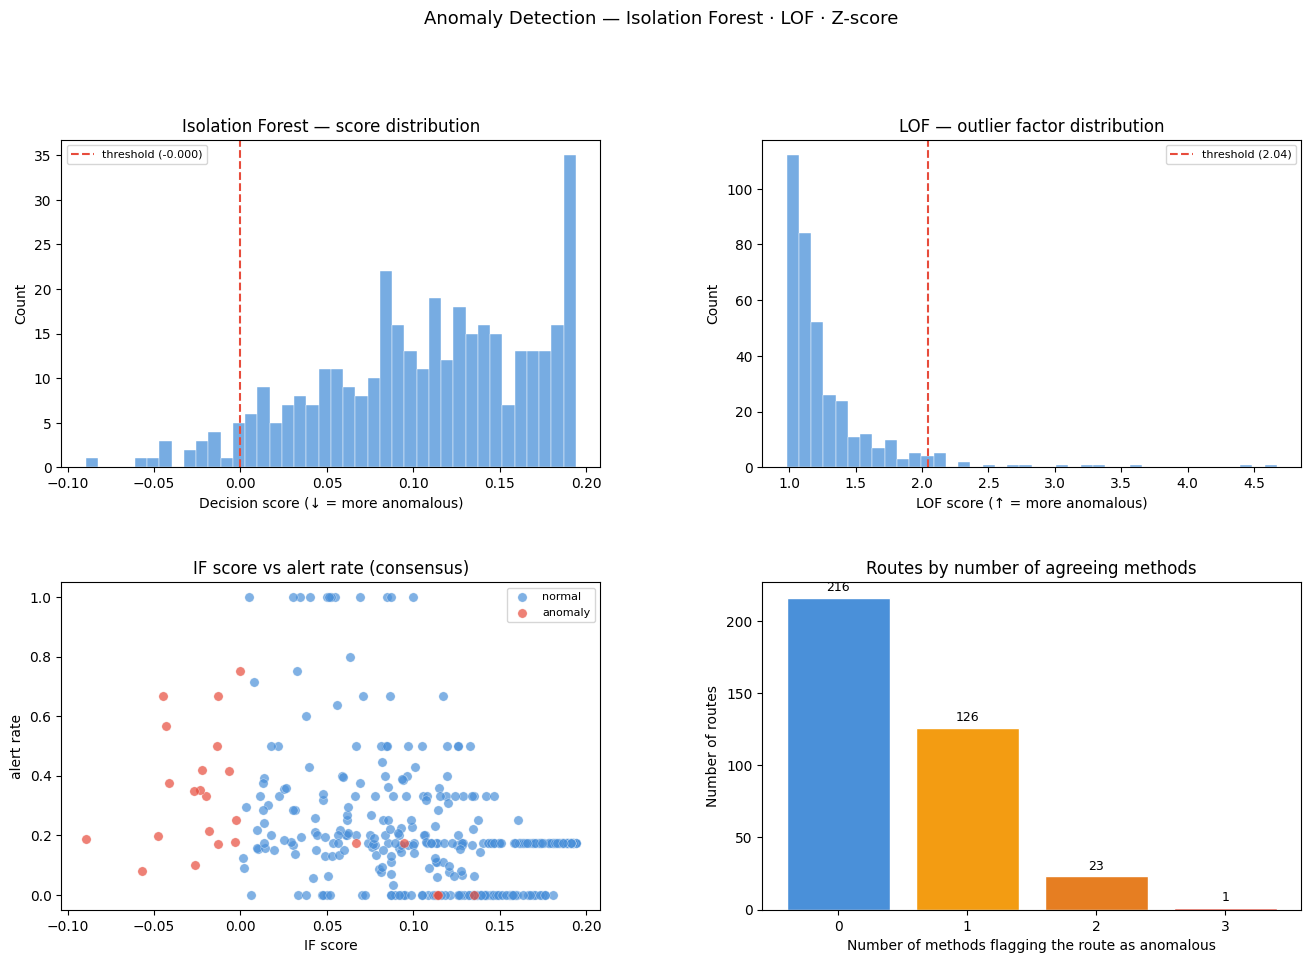

In [105]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

palette = {0: '#4A90D9', 1: '#E74C3C'}

#  A: IF score distribution 
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df_model['if_score'], bins=40, color='#4A90D9', ax=ax1, edgecolor='white', linewidth=0.3)
thresh_if = df_model.loc[df_model['if_anomaly']==1, 'if_score'].max()
ax1.axvline(thresh_if, color='#E74C3C', lw=1.5, ls='--', label=f'threshold ({thresh_if:.3f})')
ax1.set_title('Isolation Forest — score distribution')
ax1.set_xlabel('Decision score (↓ = more anomalous)')
ax1.legend(fontsize=8)

#  B: LOF score distribution 
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df_model['lof_score'], bins=40, color='#4A90D9', ax=ax2, edgecolor='white', linewidth=0.3)
thresh_lof = df_model.loc[df_model['lof_anomaly']==1, 'lof_score'].min()
ax2.axvline(thresh_lof, color='#E74C3C', lw=1.5, ls='--', label=f'threshold ({thresh_lof:.2f})')
ax2.set_title('LOF — outlier factor distribution')
ax2.set_xlabel('LOF score (↑ = more anomalous)')
ax2.legend(fontsize=8)

#  C: alert rate vs if_score, colored by consensus 
ax3 = fig.add_subplot(gs[1, 0])
scatter_kw = dict(alpha=0.7, edgecolors='white', linewidths=0.3, s=45)
for label, grp in df_model.groupby('anomaly_consensus'):
    ax3.scatter(grp['if_score'], grp['tasso_allarme'],
                c=palette[label], label=('anomaly' if label else 'normal'), **scatter_kw)
ax3.set_xlabel('IF score')
ax3.set_ylabel('alert rate')
ax3.set_title('IF score vs alert rate (consensus)')
ax3.legend(fontsize=8)

#  D: Votes per route (bar) 
ax4 = fig.add_subplot(gs[1, 1])
counts = df_model['anomaly_votes'].value_counts().sort_index()
bars = ax4.bar(counts.index.astype(str), counts.values,
               color=['#4A90D9','#F39C12','#E67E22','#E74C3C'][:len(counts)],
               edgecolor='white')
ax4.bar_label(bars, padding=3, fontsize=9)
ax4.set_title('Routes by number of agreeing methods')
ax4.set_xlabel('Number of methods flagging the route as anomalous')
ax4.set_ylabel('Number of routes')
ax4.set_xticks(counts.index.astype(str))

plt.suptitle('Anomaly Detection — Isolation Forest · LOF · Z-score', fontsize=13, y=1.01)
plt.show()

### 6. Abnormal routes — summary table

In [106]:
cols_display = ['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO',
                'tasso_allarme', 'tot_allarmati', 'tot_investigati',
                'if_anomaly', 'lof_anomaly', 'zscore_anomaly',
                'anomaly_votes', 'if_score', 'lof_score', 'zscore_max']

# Filter routes with at least 1 vote and sort by votes desc, then alert rate desc
anomaly_table = (
    df_model[df_model['anomaly_votes'] >= 1][cols_display]
    .sort_values(['anomaly_votes', 'tasso_allarme'], ascending=[False, False])
    .reset_index(drop=True)
)

print(f"Routes with at least 1 flag: {len(anomaly_table)}")
print(f"Routes with consensus (≥ 2 methods): {df_model['anomaly_consensus'].sum()}")
anomaly_table.style.background_gradient(subset=['anomaly_votes'], cmap='YlOrRd')

Routes with at least 1 flag: 150
Routes with consensus (≥ 2 methods): 24


,AREOPORTO_PARTENZA,AREOPORTO_ARRIVO,tasso_allarme,tot_allarmati,tot_investigati,if_anomaly,lof_anomaly,zscore_anomaly,anomaly_votes,if_score,lof_score,zscore_max
0,tun,mxp,0.375000,3.000000,8.000000,1,1,1,3,-0.041578,3.036634,16.694233
1,man,vce,0.750000,3.000000,4.000000,1,0,1,2,-0.000400,1.164717,4.183527
2,cmn,blq,0.666667,2.000000,3.000000,1,0,1,2,-0.044645,1.424951,4.180924
3,ist,nap,0.666667,2.000000,3.000000,1,0,1,2,-0.012946,1.317329,4.183527
4,ist,vce,0.565217,13.000000,23.000000,1,0,1,2,-0.043232,1.217006,4.183527
5,dxb,vce,0.500000,1.000000,2.000000,1,0,1,2,-0.013553,1.434711,3.553404
6,saw,bgy,0.418301,64.000000,153.000000,1,0,1,2,-0.022232,1.154723,3.188914
7,ist,mxp,0.415094,22.000000,53.000000,1,0,1,2,-0.006611,1.155379,3.930503
8,ist,fco,0.352941,12.000000,34.000000,1,0,1,2,-0.023313,1.169961,3.540124
9,saw,fco,0.350000,42.000000,120.000000,1,0,1,2,-0.026964,1.378919,6.284286



The table below lists all **150 routes flagged by at least one method**, sorted by number of votes and alarm rate. Routes with ≥ 2 votes are classified as final anomalies.

**Key observations:**

- **TUN → MXP** is the only route flagged by all 3 methods (votes = 3), with an alarm rate of 37.5% and the highest `zscore_max` (16.69) in the dataset — a clear priority for operational review.

- Routes with **votes = 2** split into two distinct profiles:
  - *High alarm rate, low volume* — e.g. MAN→VCE (75%), CMN→BLQ (67%), IST→NAP (67%): few investigated travellers but a disproportionate number of alarms.
  - *Low alarm rate, high volume* — e.g. TIA→BLQ, TIA→BGY, TIA→PSA: hundreds of thousands of travellers investigated, with alarm rates around 18–20% that stand out statistically even if individually modest.

- Several routes with **votes = 1** show `tasso_allarme = 1.0` (100% alarm rate) but very low absolute counts (1–3 travellers). These are flagged by Z-score only and should be treated with caution — a single alarm on a single traveller is statistically extreme but operationally uninformative.

# POST PROCESSING

## Objective

The post-processing step receives 'df_model' as input, the dataset of 366 routes with anomaly detection results (Isolation Forest, LOF, Z-score) already computed.

The goal is to transform the 24 anomalous signals with consensus (≥ 2/3 methods) into an operational output: a ranked list of suspicious routes with risk level, priority score, and data quality notes.

In [107]:
# Thresholds derived from the cross-sectional baseline
SOGLIA_TASSO      = 0.175 * 3   # 3x the median → 0.525
SOGLIA_VOLUME     = 100         # at least 100 investigated passengers to consider the route significant

# Work only on routes with consensus (≥ 2 out of 3 methods)
df_post = df_model[df_model['anomaly_consensus'] == 1].copy()

print(f"Anomalous routes in input: {len(df_post)}")
print(df_post[['AREOPORTO_PARTENZA','AREOPORTO_ARRIVO','tasso_allarme','tot_investigati','anomaly_votes']].to_string())

Anomalous routes in input: 24
    AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tasso_allarme  tot_investigati  anomaly_votes
4                  ala              mxp       0.000000              1.0              2
62                 cmn              blq       0.666667              3.0              2
77                 doh              fco       0.333333              3.0              2
94                 dxb              vce       0.500000              2.0              2
134                ika              mxp       0.251462            171.0              2
138                ist              bri       0.214286             14.0              2
141                ist              fco       0.352941             34.0              2
142                ist              mxp       0.415094             53.0              2
143                ist              nap       0.666667              3.0              2
146                ist              vce       0.565217             23.0              2
171          

#  CLASSIFICATION RESULTS 

 | Level    | Routes | Description                                          |
 |----------|--------|------------------------------------------------------|
 | CRITICAL |   1    | Flagged by all 3 methods — absolute priority         |
 | HIGH     |  10    | Alert rate above threshold or high volume with elevate rate                                        
 | MEDIUM   |   7    | Very high volume (TIA routes) with statistically significant rate                                     
 | LOW      |   6    | Weak signal — low rate and/or insufficient volume    |

# DATA NOTES 

**3 routes** classified as likely false positives: flagged due to anomalous
   concentration of Afghan nationality (pct_naz_afg z=4.96) but with
   alert rate = 0%
**2 routes** with incomplete data: alert rate present in df1 but no records
   in df2
**5 HIGH routes** with volume <= 3 investigated: observed alert rate is high
   but confidence interval is very wide — handle with operational caution

In [108]:
def classify_risk(row):
    tasso = row['tasso_allarme']
    volume = row['tot_investigati']
    voti = row['anomaly_votes']
    
    # CRITICAL: flagged by all 3 methods
    if voti == 3:
        return 'CRITICAL'
    
    # HIGH: alert rate above 3x baseline threshold (0.525) — regardless of volume
    if tasso >= SOGLIA_TASSO:
        return 'HIGH'
    
    # HIGH: alert rate >= 30% with at least 2 investigated passengers
    if tasso >= 0.30 and volume >= 2:
        return 'HIGH'
    
    # MEDIUM: very high volume with alert rate >= 9% (captures tia→fco at 10%)
    if volume >= SOGLIA_VOLUME and tasso >= 0.09:
        return 'MEDIUM'
    
    # MEDIUM: alert rate >= 20% with decent volume
    if tasso >= 0.20 and volume >= 10:
        return 'MEDIUM'
    
    # LOW: everything else
    return 'LOW'

df_post['risk_level'] = df_post.apply(classify_risk, axis=1)

print(df_post['risk_level'].value_counts())
print()
print(df_post[['AREOPORTO_PARTENZA','AREOPORTO_ARRIVO','tasso_allarme',
               'tot_investigati','anomaly_votes','risk_level']].to_string())

risk_level
HIGH        10
MEDIUM       7
LOW          6
CRITICAL     1
Name: count, dtype: int64

    AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tasso_allarme  tot_investigati  anomaly_votes risk_level
4                  ala              mxp       0.000000              1.0              2        LOW
62                 cmn              blq       0.666667              3.0              2       HIGH
77                 doh              fco       0.333333              3.0              2       HIGH
94                 dxb              vce       0.500000              2.0              2       HIGH
134                ika              mxp       0.251462            171.0              2     MEDIUM
138                ist              bri       0.214286             14.0              2     MEDIUM
141                ist              fco       0.352941             34.0              2       HIGH
142                ist              mxp       0.415094             53.0              2       HIGH
143                i

In [109]:
def assign_quality_note(row):
    tasso = row['tasso_allarme']
    volume = row['tot_investigati']
    
    # Incomplete data: alert rate present but zero investigated passengers from df2
    if volume == 0 and tasso > 0:
        return 'incomplete data — alert rate from df1, no records in df2'
    
    # Likely false positive: zero alert rate, minimal volume
    if tasso == 0 and volume <= 2:
        return 'likely false positive — flagged on features unrelated to alert rate'
    
    # Borderline: high alert rate but volume too low to be reliable
    if tasso >= 0.30 and volume <= 3:
        return 'warning — high alert rate but insufficient volume (≤3 investigated)'
    
    return 'ok'

df_post['quality_note'] = df_post.apply(assign_quality_note, axis=1)

print(df_post[['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'tasso_allarme',
               'tot_investigati', 'risk_level', 'quality_note']].to_string())

    AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tasso_allarme  tot_investigati risk_level                                                         quality_note
4                  ala              mxp       0.000000              1.0        LOW  likely false positive — flagged on features unrelated to alert rate
62                 cmn              blq       0.666667              3.0       HIGH  warning — high alert rate but insufficient volume (≤3 investigated)
77                 doh              fco       0.333333              3.0       HIGH  warning — high alert rate but insufficient volume (≤3 investigated)
94                 dxb              vce       0.500000              2.0       HIGH  warning — high alert rate but insufficient volume (≤3 investigated)
134                ika              mxp       0.251462            171.0     MEDIUM                                                                   ok
138                ist              bri       0.214286             14.0     MEDIUM      

In [110]:
# STEP 1: false positive explanation 
feature_cols = [
    'tot_allarmi_chiusi', 'tot_allarmi_generati', 'tot_allarmi_non_chiusi',
    'tot_allarmi_rilevanti', 'tot_altro', 'tot_esito_negativo',
    'tot_mancato_aggiornamento', 'tot_viaggiatori_con_allarmi',
    'tot_viaggiatori_entrati', 'tot_viaggiatori_investigati',
    'tot_voli_con_allarmi', 'tot_voli_disponibili',
    'tot_voli_investigati', 'tot_voli_solo_visualizzati',
    'tot_entrati', 'tot_investigati', 'tot_allarmati',
    'tasso_allarme', 'alert_rate_alb', 'alert_rate_afg',
    'pct_naz_alb', 'pct_naz_afg', 'alert_rate_visto',
    'alert_rate_passaporto', 'alert_rate_permesso', 'alert_rate_carta',
    'pct_segnalato', 'pct_respinto', 'pct_fermato', 'pct_ok'
]

X_full = df_model[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
X_log_full = np.log1p(X_full.values.astype(float))  # .values.astype(float) forces pure numpy float
Z_full = np.abs(stats.zscore(X_log_full, ddof=1))
Z_df = pd.DataFrame(Z_full, columns=feature_cols, index=df_model.index)

def flag_reason(row):
    if row['quality_note'] != 'likely false positive — flagged on features unrelated to alert rate':
        return ''
    idx = row.name
    top = Z_df.loc[idx].sort_values(ascending=False)
    top = top[top > 3.0]
    if len(top) == 0:
        return 'no feature above z=3 threshold'
    return 'flagged due to: ' + ', '.join([f'{f} (z={v:.2f})' for f, v in top.items()])

df_post['flag_reason'] = df_post.apply(flag_reason, axis=1)

# STEP 2: Wilson confidence interval for low-volume routes 
def wilson_ci(row):
    n = int(row['tot_investigati'])
    tasso = row['tasso_allarme']
    if n == 0:
        return np.nan, np.nan
    allarmi = round(tasso * n)
    z = 1.96
    center  = (allarmi + z**2/2) / (n + z**2)
    margin  = (z * np.sqrt(allarmi*(n-allarmi)/n + z**2/4)) / (n + z**2)
    return round(max(0, center - margin), 3), round(min(1, center + margin), 3)

df_post['ci95_low']  = df_post.apply(lambda r: wilson_ci(r)[0], axis=1)
df_post['ci95_high'] = df_post.apply(lambda r: wilson_ci(r)[1], axis=1)
df_post['ci95_str']  = df_post.apply(
    lambda r: f"[{r['ci95_low']:.1%}, {r['ci95_high']:.1%}]"
              if pd.notna(r['ci95_low']) else 'n/a', axis=1
)

# Verify results
print(df_post[['AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'tasso_allarme',
               'tot_investigati', 'risk_level',
               'quality_note', 'flag_reason', 'ci95_str']].to_string())

    AREOPORTO_PARTENZA AREOPORTO_ARRIVO  tasso_allarme  tot_investigati risk_level                                                         quality_note                           flag_reason        ci95_str
4                  ala              mxp       0.000000              1.0        LOW  likely false positive — flagged on features unrelated to alert rate  flagged due to: pct_naz_afg (z=4.96)   [0.0%, 79.3%]
62                 cmn              blq       0.666667              3.0       HIGH  warning — high alert rate but insufficient volume (≤3 investigated)                                        [20.8%, 93.9%]
77                 doh              fco       0.333333              3.0       HIGH  warning — high alert rate but insufficient volume (≤3 investigated)                                         [6.1%, 79.2%]
94                 dxb              vce       0.500000              2.0       HIGH  warning — high alert rate but insufficient volume (≤3 investigated)                         

# Priority Score
A number between 0 and 1 that summarizes in a single value how operationally
priority a route is. It is built by combining 2 components with different weights:

60% → alert_rate — what % of passengers generate an alarm

40% → absolute_alarms (log) — how many real alarms in absolute numbers

In [111]:
#PRIORITY SCORE — 60% alert rate, 40% absolute alarms log 

#All 24 routes
scaler_pp3 = MinMaxScaler()

df_post['absolute_alarms'] = df_post['tasso_allarme'] * df_post['tot_investigati']
df_post['absolute_alarms_log'] = np.log1p(df_post['absolute_alarms'])

cols_score3 = ['tasso_allarme', 'absolute_alarms_log']
df_post[['rate_norm', 'alarms_norm']] = scaler_pp3.fit_transform(
    df_post[cols_score3]
)

df_post['priority_score'] = (
    0.60 * df_post['rate_norm'] +
    0.40 * df_post['alarms_norm']
).round(4)

df_post = df_post.sort_values(
    ['risk_level', 'priority_score'], ascending=[True, False]
).reset_index(drop=True)
df_post['rank'] = df_post.index + 1

print("=== ALL 24 ROUTES (weights: alert rate 60%, absolute alarms 40%) ===")
print(df_post[['rank', 'AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'PAESE_PART',
               'tasso_allarme', 'absolute_alarms', 'tot_investigati',
               'risk_level', 'priority_score',
               'ci95_str', 'quality_note']].to_string())

=== ALL 24 ROUTES (weights: alert rate 60%, absolute alarms 40%) ===
    rank AREOPORTO_PARTENZA AREOPORTO_ARRIVO           PAESE_PART  tasso_allarme  absolute_alarms  tot_investigati risk_level  priority_score        ci95_str                                                         quality_note
0      1                tun              mxp              tunisia       0.375000              3.0              8.0   CRITICAL          0.3658  [13.7%, 69.4%]                                                                   ok
1      2                man              vce          regno unito       0.750000              3.0              4.0       HIGH          0.6658  [30.1%, 95.4%]                                                                   ok
2      3                cmn              blq              marocco       0.666667              2.0              3.0       HIGH          0.5855  [20.8%, 93.9%]  warning — high alert rate but insufficient volume (≤3 investigated)
3      4               

In [112]:
# Reliable routes only (excluding false positives and incomplete data) 
notes_excluded = [
    'likely false positive — flagged on features unrelated to alert rate',
    'incomplete data — alert rate from df1, no records in df2'
]
df_post_clean = df_post[~df_post['quality_note'].isin(notes_excluded)].copy()

scaler_clean3 = MinMaxScaler()
df_post_clean['absolute_alarms'] = df_post_clean['tasso_allarme'] * df_post_clean['tot_investigati']
df_post_clean['absolute_alarms_log'] = np.log1p(df_post_clean['absolute_alarms'])

cols_score3 = ['tasso_allarme', 'absolute_alarms_log']
df_post_clean[['rate_norm', 'alarms_norm']] = scaler_clean3.fit_transform(
    df_post_clean[cols_score3]
)

df_post_clean['priority_score'] = (
    0.60 * df_post_clean['rate_norm'] +
    0.40 * df_post_clean['alarms_norm']
).round(4)

df_post_clean = df_post_clean.sort_values(
    ['risk_level', 'priority_score'], ascending=[True, False]
).reset_index(drop=True)
df_post_clean['rank'] = df_post_clean.index + 1

print("\n=== 19 RELIABLE ROUTES (weights: alert rate 60%, absolute alarms 40%) ===")
print(df_post_clean[['rank', 'AREOPORTO_PARTENZA', 'AREOPORTO_ARRIVO', 'PAESE_PART',
                      'tasso_allarme', 'absolute_alarms', 'tot_investigati',
                      'risk_level', 'priority_score',
                      'ci95_str', 'quality_note']].to_string())


=== 19 RELIABLE ROUTES (weights: alert rate 60%, absolute alarms 40%) ===
    rank AREOPORTO_PARTENZA AREOPORTO_ARRIVO           PAESE_PART  tasso_allarme  absolute_alarms  tot_investigati risk_level  priority_score        ci95_str                                                         quality_note
0      1                tun              mxp              tunisia       0.375000              3.0              8.0   CRITICAL          0.3005  [13.7%, 69.4%]                                                                   ok
1      2                man              vce          regno unito       0.750000              3.0              4.0       HIGH          0.6358  [30.1%, 95.4%]                                                                   ok
2      3                cmn              blq              marocco       0.666667              2.0              3.0       HIGH          0.5465  [20.8%, 93.9%]  warning — high alert rate but insufficient volume (≤3 investigated)
3      4         

## Priority Score Ranking — 19 Reliable Routes

The chart ranks all 19 reliable routes by priority score (0–1), combining alert rate (60%) and absolute alarms log (40%). MAN→VCE leads among HIGH routes (0.636) despite TUN→MXP being the only CRITICAL; TIA routes dominate the MEDIUM tier with consistently high scores driven by extreme passenger volume rather than rate alone.

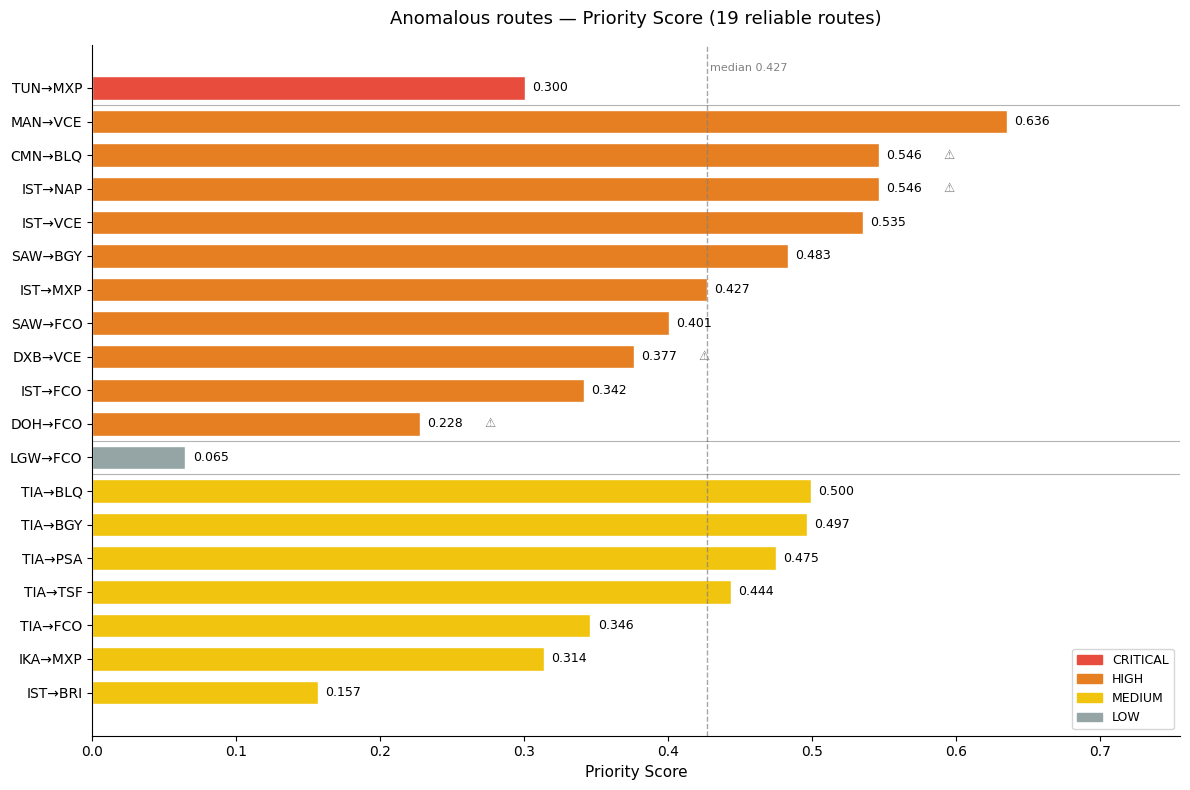

In [113]:
# Colors by risk level
color_map = {
    'CRITICAL': '#E74C3C',
    'HIGH':     '#E67E22',
    'MEDIUM':   '#F1C40F',
    'LOW':      '#95A5A6'
}

fig, ax = plt.subplots(figsize=(12, 8))

# Reversed order to have rank 1 at the top
df_plot = df_post_clean.sort_values('rank', ascending=False)

labels = df_plot['AREOPORTO_PARTENZA'].str.upper() + '→' + df_plot['AREOPORTO_ARRIVO'].str.upper()
scores = df_plot['priority_score']
colors = df_plot['risk_level'].map(color_map)
ranks  = df_plot['rank']

bars = ax.barh(range(len(df_plot)), scores, color=colors, edgecolor='white', height=0.7)

# Labels on bars
for i, (score, note, rank) in enumerate(zip(scores, df_plot['quality_note'], ranks)):
    ax.text(score + 0.005, i, f'{score:.3f}', va='center', fontsize=9)
    if note == 'warning — high alert rate but insufficient volume (≤3 investigated)':
        ax.text(score + 0.045, i, '⚠', va='center', fontsize=9, color='gray')

# Y-axis with route labels
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(labels, fontsize=10)

# Median threshold line
median_score = df_post_clean['priority_score'].median()
ax.axvline(median_score, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.text(median_score + 0.002, len(df_plot) - 0.5,
        f'median {median_score:.3f}', fontsize=8, color='gray')

# Separators between risk levels
levels = df_plot['risk_level'].values
for i in range(1, len(levels)):
    if levels[i] != levels[i-1]:
        ax.axhline(i - 0.5, color='black', linewidth=0.8, alpha=0.3, linestyle='-')

# Legend
patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)

ax.set_xlabel('Priority Score', fontsize=11)
ax.set_title('Anomalous routes — Priority Score (19 reliable routes)', fontsize=13, pad=15)
ax.set_xlim(0, max(scores) + 0.12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Bubble Chart — Alert Rate vs Volume

Each bubble represents an anomalous route: the x-axis shows total investigated passengers (log scale), the y-axis the alert rate, and the bubble size the absolute number of alarms. 

HIGH routes (orange) dominate the upper-left quadrant with high rates but low volume
MEDIUM routes (yellow) cluster bottom-right with massive volume around the 20% mark — TIA→FCO and TIA→BGY being the most operationally impactful due to sheer scale.

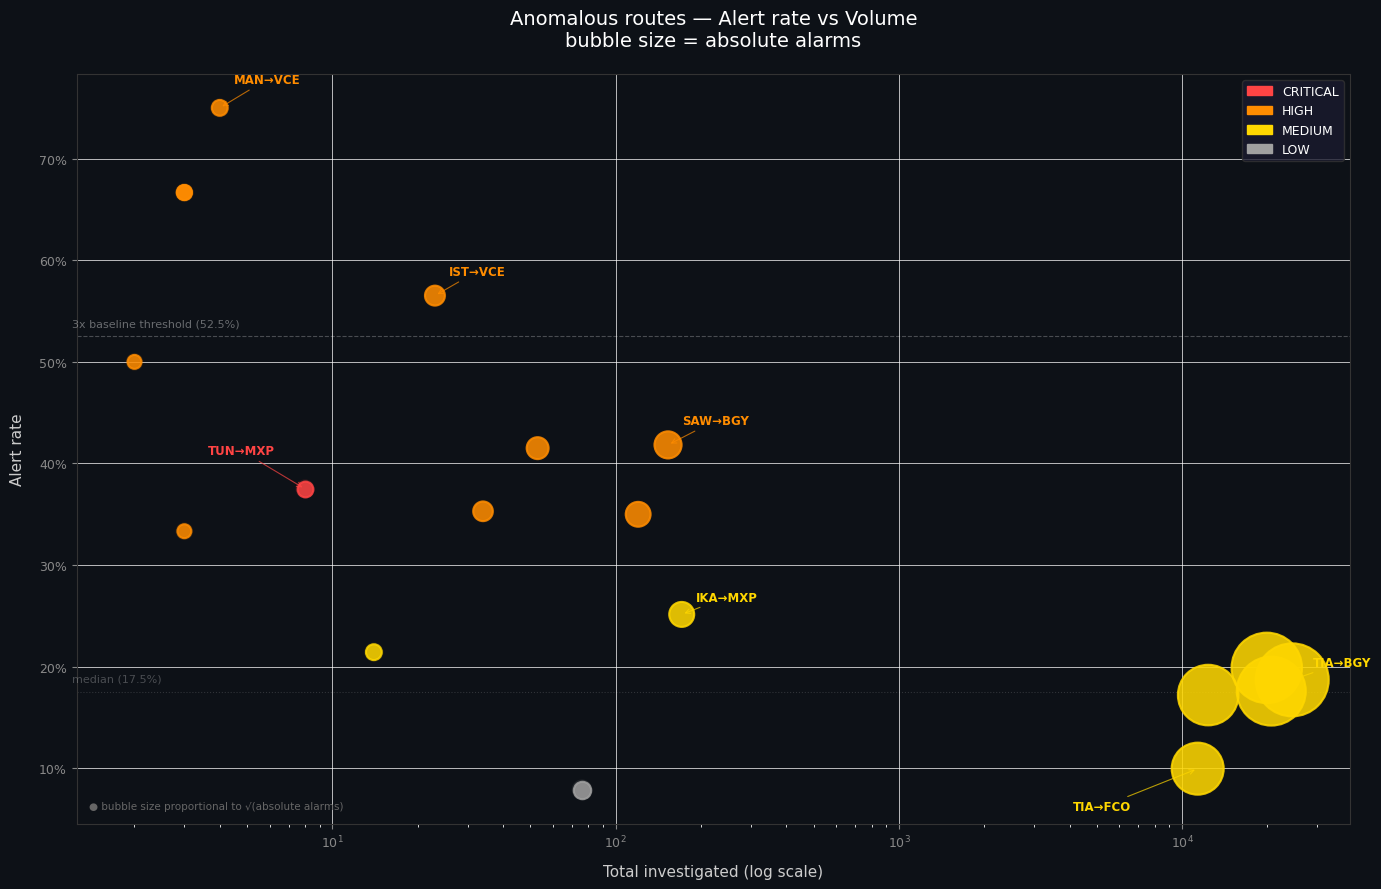

In [114]:
# Dark background
plt.style.use('dark_background')

color_map = {
    'CRITICAL': '#FF4444',
    'HIGH':     '#FF8C00',
    'MEDIUM':   '#FFD700',
    'LOW':      '#A0A0A0'
}

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

# Subtle grid
ax.grid(True, color='#ffffff15', linewidth=0.5, zorder=0)

# Bubbles 
for level in ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']:
    subset = df_post_clean[df_post_clean['risk_level'] == level]

    # Main bubble
    ax.scatter(
        subset['tot_investigati'],
        subset['tasso_allarme'],
        s=np.sqrt(subset['absolute_alarms'].clip(lower=1)) * 40 + 60,
        c=color_map[level],
        alpha=0.85,
        edgecolors=color_map[level],
        linewidths=1.5,
        label=level,
        zorder=3
    )
    # Glow halo
    ax.scatter(
        subset['tot_investigati'],
        subset['tasso_allarme'],
        s=np.sqrt(subset['absolute_alarms'].clip(lower=1)) * 40 + 120,
        c=color_map[level],
        alpha=0.12,
        edgecolors='none',
        zorder=2
    )

# Selective annotations with arrows 
routes_to_annotate = [
    ('tun', 'mxp', (-70, 25)),
    ('man', 'vce', (10, 18)),
    ('ist', 'vce', (10, 15)),
    ('saw', 'bgy', (10, 15)),
    ('tia', 'bgy', (15, 10)),
    ('tia', 'fco', (-90, -30)),
    ('ika', 'mxp', (10, 10)),
]

for origin, dest, offset in routes_to_annotate:
    row = df_post_clean[
        (df_post_clean['AREOPORTO_PARTENZA'] == origin) &
        (df_post_clean['AREOPORTO_ARRIVO'] == dest)
    ]
    if len(row) == 0:
        continue
    row = row.iloc[0]
    level = row['risk_level']
    label = f"{origin.upper()}→{dest.upper()}"

    ax.annotate(
        label,
        xy=(row['tot_investigati'], row['tasso_allarme']),
        xytext=offset,
        textcoords='offset points',
        fontsize=8.5,
        color=color_map[level],
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            color=color_map[level],
            lw=0.8,
            alpha=0.7
        ),
        zorder=5
    )

#  Reference lines 
ax.axhline(0.525, color='#ffffff40', linestyle='--', linewidth=0.8)
ax.text(1.2, 0.535, '3x baseline threshold (52.5%)',
        fontsize=8, color='#ffffff60')

ax.axhline(0.175, color='#ffffff25', linestyle=':', linewidth=0.8)
ax.text(1.2, 0.185, 'median (17.5%)',
        fontsize=8, color='#ffffff40')

#  Axes and title 
ax.set_xlabel('Total investigated (log scale)',
              fontsize=11, color='#cccccc', labelpad=10)
ax.set_ylabel('Alert rate',
              fontsize=11, color='#cccccc', labelpad=10)
ax.set_title('Anomalous routes — Alert rate vs Volume\n'
             'bubble size = absolute alarms',
             fontsize=14, color='white', pad=20)

ax.set_xscale('log')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.tick_params(colors='#888888', labelsize=9)
for spine in ax.spines.values():
    spine.set_color('#333333')

patches = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
legend = ax.legend(
    handles=patches,
    fontsize=9,
    loc='upper right',
    facecolor='#1a1a2e',
    edgecolor='#333333',
    labelcolor='white'
)

# Bubble size note 
ax.text(0.01, 0.02,
        '● bubble size proportional to √(absolute alarms)',
        transform=ax.transAxes,
        fontsize=7.5, color='#666666')

plt.tight_layout()
plt.show()

# OUTPUT

Starting from `df_model` (366 routes with anomaly detection results), we filtered the 24 routes with consensus (≥2/3 methods), assigned a risk level (CRITICAL / HIGH / MEDIUM / LOW) based on alert rate and volume, computed a priority score (alert rate 60% + absolute alarms log 40%)



In [115]:
# FINAL REPORT
risk_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']

for df in [df_post, df_post_clean]:
    df['risk_level_order'] = df['risk_level'].map({v: i for i, v in enumerate(risk_order)})

df_post = df_post.sort_values(['risk_level_order', 'priority_score'], ascending=[True, False]).reset_index(drop=True)
df_post_clean = df_post_clean.sort_values(['risk_level_order', 'priority_score'], ascending=[True, False]).reset_index(drop=True)
df_post['rank'] = df_post.index + 1
df_post_clean['rank'] = df_post_clean.index + 1

print("=" * 70)
print(f"  TRANSIT ANOMALY REPORT — POST PROCESSING  |  {date.today().strftime('%d/%m/%Y')}")
print("=" * 70)
print(f"""
SUMMARY
  Total routes analyzed       : 366
  Anomaly signal (≥1)         : 150
  Consensus (≥2/3)            : 24
  Reliable in report          : 19
  Excluded (data quality)     : 5

  CRITICAL : {len(df_post[df_post['risk_level']=='CRITICAL'])}
  HIGH     : {len(df_post[df_post['risk_level']=='HIGH'])}
  MEDIUM   : {len(df_post[df_post['risk_level']=='MEDIUM'])}
  LOW      : {len(df_post[df_post['risk_level']=='LOW'])}  (of which 5 with data quality issues)

  Median alert_rate : 0.175  |  Threshold 3x : 0.525
  Priority score    : alert_rate 60% + absolute_alarms_log 40%
""")

# Section 1: Reliable routes 
print("=" * 70)
print("SECTION 1 — RELIABLE ROUTES (19)")
print("=" * 70)

for level in risk_order:
    subset = df_post_clean[df_post_clean['risk_level'] == level]
    if len(subset) == 0:
        continue
    print(f"\n  {level} ({len(subset)} routes)")
    print("─" * 70)
    for _, r in subset.iterrows():
        print(f"\n  #{int(r['rank']):02d} {r['AREOPORTO_PARTENZA'].upper()}→{r['AREOPORTO_ARRIVO'].upper()} ({r['PAESE_PART'].title()})")
        print(f"  Alert rate {r['tasso_allarme']:.1%}  CI95 {r['ci95_str']}  |  Investigated {int(r['tot_investigati']):,}  |  Alarms {int(r['absolute_alarms']):,}")
        print(f"  Votes {int(r['anomaly_votes'])}/3 (IF={int(r['if_anomaly'])} LOF={int(r['lof_anomaly'])} Z={int(r['zscore_anomaly'])})  |  Score {r['priority_score']:.4f}")
        if r['quality_note'] != 'ok':
            print(f"  ⚠ {r['quality_note']}")

# Section 2: Excluded routes 
print(f"\n{'=' * 70}")
print("SECTION 2 — EXCLUDED ROUTES (5)")
print("=" * 70)

notes_excluded = [
    'likely false positive — flagged on features unrelated to alert rate',
    'incomplete data — alert rate from df1, no records in df2'
]
for _, r in df_post[df_post['quality_note'].isin(notes_excluded)].iterrows():
    country = r['PAESE_PART'].title() if pd.notna(r['PAESE_PART']) else 'n/a'
    print(f"\n  {r['AREOPORTO_PARTENZA'].upper()}→{r['AREOPORTO_ARRIVO'].upper()} ({country})  [{r['risk_level']}]")
    print(f"  {r['quality_note']}")
    if pd.notna(r['flag_reason']) and r['flag_reason'] != '':
        print(f"  {r['flag_reason']}")

drop_cols = ['votes_norm', 'rate_norm', 'alarms_norm', 'absolute_alarms_log', 'risk_level_order']
df_post       = df_post.drop(columns=drop_cols, errors='ignore')
df_post_clean = df_post_clean.drop(columns=drop_cols, errors='ignore')

  TRANSIT ANOMALY REPORT — POST PROCESSING  |  30/04/2026

SUMMARY
  Total routes analyzed       : 366
  Anomaly signal (≥1)         : 150
  Consensus (≥2/3)            : 24
  Reliable in report          : 19
  Excluded (data quality)     : 5

  CRITICAL : 1
  HIGH     : 10
  MEDIUM   : 7
  LOW      : 6  (of which 5 with data quality issues)

  Median alert_rate : 0.175  |  Threshold 3x : 0.525
  Priority score    : alert_rate 60% + absolute_alarms_log 40%

SECTION 1 — RELIABLE ROUTES (19)

  CRITICAL (1 routes)
──────────────────────────────────────────────────────────────────────

  #01 TUN→MXP (Tunisia)
  Alert rate 37.5%  CI95 [13.7%, 69.4%]  |  Investigated 8  |  Alarms 3
  Votes 3/3 (IF=1 LOF=1 Z=1)  |  Score 0.3005

  HIGH (10 routes)
──────────────────────────────────────────────────────────────────────

  #02 MAN→VCE (Regno Unito)
  Alert rate 75.0%  CI95 [30.1%, 95.4%]  |  Investigated 4  |  Alarms 3
  Votes 2/3 (IF=1 LOF=0 Z=1)  |  Score 0.6358

  #03 CMN→BLQ (Marocco)
  Ale

---

---

---

# Multi-Agent Pipeline

In this section, we introduce the multi-agent pipeline, which became the main focus of our work. Compared to the more traditional approach, this is where we invested the majority of our time and effort, following the recommendation of the teaching assistants.

Designing and implementing this pipeline required significantly more iteration, coordination, and experimentation. It proved to be the most demanding part of the project in terms of both time and energy, but also the most insightful, as it pushed us to explore more advanced and structured solutions.

# Configuration
Here we set up the API connection, define all file paths (input, output, and intermediate files), and initialize basic parameters used across the pipeline.

In [116]:
load_dotenv()

MISTRAL_BASE_URL = "https://api.mistral.ai/v1"
MISTRAL_API_KEY  = os.getenv("MISTRAL_API_KEY", "")
MISTRAL_MODEL    = "mistral-small-latest"

_client = OpenAI(base_url=MISTRAL_BASE_URL, api_key=MISTRAL_API_KEY)

# Paths 
PROJECT_ROOT = os.getcwd()
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
ALLARMI_CSV = os.path.join(RAW_DIR, "ALLARMI.csv")
TIPOLOGIA_CSV = os.path.join(RAW_DIR, "TIPOLOGIA_VIAGGIATORE.csv")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "output")
FINDINGS_JSON = os.path.join(OUTPUT_DIR, "findings.json")
COLUMN_PROFILES_JSON = os.path.join(OUTPUT_DIR, "column_profiles.json")
CLEANING_PLAN_JSON   = os.path.join(OUTPUT_DIR, "cleaning_plan.json")   # NEW: slim JSON for cleaning agent
SCOPE_MANIFEST_JSON = os.path.join(OUTPUT_DIR, "scope_manifest.json")

# Profiling 
DOMINANT_FORMAT_SAMPLE_SIZE = 200 

## Cleaning Helpers

This section defines a set of reusable functions used for dataset cleaning and normalization.

- **`_strip_accents(text)`**  
  Removes accents and diacritics from text (e.g. "à" → "a").

- **`_collapse_spaces(text)`**  
  Normalizes whitespace by collapsing multiple spaces into one.

- **`to_snake_case(name)`**  
  Converts column names to a consistent `snake_case` format.  
  Handles special characters, camelCase, and noisy inputs.

- **`normalize_column_names(df)`**  
  Applies `snake_case` normalization to all column names in a DataFrame.

- **`deduplicate_column_names(df)`**  
  Ensures all column names are unique by adding suffixes (`__1`, `__2`, ...).

- **`remove_duplicate_rows(df)`**  
  Removes exact duplicate rows from the dataset.

- **`standardize_missing_values(df)`**  
  Converts common missing value placeholders (e.g. "n/a", "unknown") into `NaN`.

- **`normalize_text_values(df)`**  
  Cleans textual data by lowercasing and normalizing spaces.

- **`load_cleaning_plan(path, dataset_key)`**  
  Loads a JSON-based cleaning plan for a specific dataset, used to guide transformations.

These helpers provide a generic and reusable foundation for the data cleaning pipeline.

In [117]:
DEFAULT_CLEANING_MISSING_TOKENS = {
    "", " ", "na", "n/a", "null", "none", "nan", "unknown", "undefined",
    "-", "--", "not available", "missing", "n.d.", "nd"
}


def _strip_accents(text: str) -> str:
    text = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in text if not unicodedata.combining(ch))


def _collapse_spaces(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def to_snake_case(name: str) -> str:
    name = "" if name is None else str(name)
    name = _strip_accents(name).strip()

    # Separate camelCase / PascalCase boundaries
    name = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", name)
    name = re.sub(r"([A-Z]+)([A-Z][a-z])", r"\1_\2", name)

    # Replace non-alphanumeric runs with underscore
    name = re.sub(r"[^0-9A-Za-z]+", "_", name)

    # Collapse underscores and trim
    name = re.sub(r"_+", "_", name).strip("_").lower()

    if not name:
        name = "unnamed_column"

    # If the name starts with a digit, prefix it to keep it identifier-like
    if re.match(r"^\d", name):
        name = f"col_{name}"

    return name


def normalize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [to_snake_case(col) for col in out.columns]
    return out


def deduplicate_column_names(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    seen = {}
    new_cols = []

    for col in out.columns:
        if col not in seen:
            seen[col] = 0
            new_cols.append(col)
        else:
            seen[col] += 1
            new_cols.append(f"{col}__{seen[col]}")

    out.columns = new_cols
    return out


def remove_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop_duplicates().copy()


def standardize_missing_values(
    df: pd.DataFrame,
    missing_tokens: Optional[Iterable[str]] = None,
) -> pd.DataFrame:
    out = df.copy()
    tokens = {str(x).strip().lower() for x in (missing_tokens or DEFAULT_CLEANING_MISSING_TOKENS)}

    for col in out.columns:
        out[col] = out[col].apply(
            lambda x: pd.NA
            if isinstance(x, str) and x.strip().lower() in tokens
            else x
        )
    return out


def normalize_text_values(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    def _norm(x):
        if pd.isna(x):
            return x
        if isinstance(x, str):
            return _collapse_spaces(x).lower()
        return x

    for col in out.columns:
        out[col] = out[col].apply(_norm)

    return out


def load_cleaning_plan(plan_json_path: str, dataset_key: str) -> dict:
    with open(plan_json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data.get(dataset_key, {})

## Column Roles & Data Types

This section defines a controlled vocabulary used to classify dataset columns during profiling.

- **Column Roles (`COLUMN_ROLES`)**  
  A predefined set of semantic roles (e.g. `count`, `measure`, `date`, `category`) that the LLM assigns to each column.  
  If no role fits, the model can propose a custom role (`custom:<name>`).

- **Role → Data Type Mapping (`ROLE_TO_EXPECTED_DTYPE`)**  
  Each role is mapped to a specific pandas dtype.  
  This ensures that, after cleaning, all columns are cast to a consistent and appropriate type.

- **`resolve_expected_dtype(role)`**  
  Given a role, returns the corresponding pandas dtype.  
  If the role is custom or unknown, it defaults to `"string"` for safety.

This mechanism allows the cleaning pipeline to remain **data-driven, consistent, and extensible** across different datasets.

In [118]:
COLUMN_ROLES = {

    # numeric
    "identifier_numeric",   # numeric IDs without arithmetic meaning (preserve as string to keep leading zeros)
    "count",                # non-negative integer counts (e.g. number of flights)
    "measure",              # continuous measurements (weight, distance, price)
    "percentage",           # percentage value
    "year",                 # year (e.g. 2024)
    "month_number",         # month as 01-12
    "day_number",           # day as 01-31

    # string / code
    "identifier",           # generic identifier (could be alphanumeric)
    "category",             # categorical variable (e.g. "low", "medium", "high")
    "free_text",            # free text / operator notes
    "flag_binary",          # binary flag (yes/no, 0/1, alto/basso)

    # temporal
    "date",                 # date without time
    "datetime",             # date + time

    # special
    "unknown",              # LLM cannot classify
}


ROLE_TO_EXPECTED_DTYPE = {
    "identifier_numeric": "string",      # keep as string to preserve leading zeros
    "count":              "Int64",       # nullable integer
    "measure":            "Float64",     # nullable float
    "percentage":         "Float64",
    "year":               "Int64",
    "month_number":       "Int64",
    "day_number":         "Int64",

    "identifier":         "string",
    "category":           "string",
    "free_text":          "string",
    "flag_binary":        "string",

    "date":               "datetime64[ns]",
    "datetime":           "datetime64[ns]",

    "unknown":            "string",      # safe default
}


def resolve_expected_dtype(role: str) -> str:
    if role in ROLE_TO_EXPECTED_DTYPE:
        return ROLE_TO_EXPECTED_DTYPE[role]
    if isinstance(role, str) and role.startswith("custom:"):
        return "string"
    return "string"

## JSON Helpers

This section provides utility functions to safely handle JSON serialization and file operations.

- **`_to_native(value)`**  
  Converts pandas and numpy objects into JSON-compatible Python types.  
  Ensures values like timestamps, arrays, and NaN are properly serialized.

- **`_safe_load_json(path)`**  
  Loads a JSON file safely.  
  Returns an empty dictionary if the file is missing, empty, or corrupted.

- **`_safe_write_json(path, data)`**  
  Writes data to a JSON file in a consistent format.  
  Automatically creates directories if needed and ensures proper encoding and formatting.

These helpers ensure robust and error-tolerant JSON handling across the pipeline.

In [119]:
def _to_native(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(k): _to_native(v) for k, v in value.items()}
    if isinstance(value, (np.ndarray, list, tuple)):
        return [_to_native(v) for v in value]
    if isinstance(value, (pd.Timestamp,)):
        return value.isoformat()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if math.isnan(float(value)):
            return None
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except Exception:
        pass
    return value


def _safe_load_json(path: str) -> dict:
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return {}
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return data if isinstance(data, dict) else {}
    except Exception:
        return {}


def _safe_write_json(path: str, data: dict) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(_to_native(data), f, ensure_ascii=False, indent=2)

## DataFrame Helpers

Utility functions for extracting structural information from pandas DataFrames,
such as shape, data types, and missing value statistics.

In [120]:
def get_dataframe_shape(df: pd.DataFrame) -> dict:
    rows, cols = df.shape
    return {"rows": int(rows), "columns": int(cols)}


def get_dataframe_dtypes(df: pd.DataFrame) -> dict:
    return {col: str(dtype) for col, dtype in df.dtypes.items()}


def get_column_missing_stats(df: pd.DataFrame) -> dict:
    result = {}
    for col in df.columns:
        mask = df[col].isna()
        result[col] = {
            "null_count": int(mask.sum()),
            "non_null_count": int((~mask).sum()),
            "missing_percentage": round(float(mask.mean() * 100), 2),
        }
    return result

## Format Detection

This section provides utilities to analyze the **structural format of column values**.

- **`_value_format_label(value)`**  
  Classifies a single value into a coarse format category  
  (e.g. `digit`, `float`, `alpha`, `alphanumeric`, `generic`, `missing`).

- **`detect_dominant_format(series)`**  
  Identifies the most common value format in a column based on a sample.  
  Returns the dominant label and its frequency.

- **`collect_non_conforming_samples(series, dominant_label)`**  
  Finds values that do not match the dominant format.  
  Useful to detect inconsistencies or dirty data.

- **`_try_numeric(series)`**  
  Attempts to convert a column to numeric format, handling common cases  
  like comma decimals or mixed string inputs.

### Design principle
These functions focus only on **syntactic patterns**, not semantics.  
Higher-level interpretation (e.g. understanding if a column is a date or ID)  
is delegated to the LLM during profiling.

In [121]:
def _value_format_label(value: Any) -> str:
    if value is None:
        return "missing"

    s = str(value).strip()

    if s == "":
        return "empty"

    if s.isdigit():
        return "digit"

    try:
        float(s.replace(",", "."))
        return "float"
    except Exception:
        pass

    if s.isalpha():
        return "alpha"

    has_alpha = any(c.isalpha() for c in s)
    has_digit = any(c.isdigit() for c in s)
    if has_alpha and has_digit:
        return "alphanumeric"

    return "generic"


def detect_dominant_format(
    series: pd.Series,
    sample_size: int = DOMINANT_FORMAT_SAMPLE_SIZE,
) -> dict:

    head_sample = series.head(sample_size)
    clean = head_sample.dropna()

    if clean.empty:
        return {
            "label": None,
            "share_pct": 0.0,
            "sample_size": 0,
        }

    labels = clean.map(_value_format_label)
    counts = labels.value_counts(dropna=False)
    total = int(counts.sum())

    return {
        "label": str(counts.index[0]),
        "share_pct": round(float(counts.iloc[0] / total * 100), 2),
        "sample_size": total,
    }


def collect_non_conforming_samples(
    series: pd.Series,
    dominant_label: str,
    sample_size: int = DOMINANT_FORMAT_SAMPLE_SIZE,
    max_samples: int = 100,
) -> dict:

    head_sample = series.head(sample_size)
    clean = head_sample.dropna()

    if clean.empty or dominant_label is None:
        return {"share_pct": 0.0, "samples": []}

    labels = clean.map(_value_format_label)
    non_conforming_mask = labels != dominant_label
    non_conforming_values = clean.loc[non_conforming_mask]

    total = int(len(clean))
    n_non_conforming = int(non_conforming_mask.sum())

    unique_samples = []
    for v in non_conforming_values.tolist():
        native_v = _to_native(v)
        if native_v not in unique_samples:
            unique_samples.append(native_v)
        if len(unique_samples) >= max_samples:
            break

    return {
        "share_pct": round(float(n_non_conforming / total * 100), 2) if total else 0.0,
        "samples": unique_samples,  
    }


def _try_numeric(series: pd.Series) -> pd.Series:

    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")

    s = series.astype("string").str.strip()
    s = s.str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

## LLM-Driven Column Enrichment

This section uses the LLM to enrich each column profile with semantic information and transformation logic.

- **Goal**  
  Extend the deterministic profile of a column with:
  - a semantic **role** (e.g. `count`, `date`, `category`)
  - a **transformation rule** to clean non-conforming values
  - a short **description** for human interpretation

- **Transformation Actions (`TRANSFORMATION_ACTIONS`)**  
  The LLM must choose from a closed set of actions:
  - `none` → no changes needed  
  - `extract` → extract valid patterns (via regex)  
  - `map` → map values to canonical ones  
  - `set_null` → discard invalid values  

- **`_build_enrichment_prompt(profile)`**  
  Builds a structured prompt combining:
  - column statistics
  - dominant format
  - sample values  
  This ensures the LLM makes decisions based on actual data.

- **`_parse_llm_enrichment_response(response)`**  
  Parses the LLM output, handling formatting issues like markdown fences.

- **`_fallback_enrichment(profile, error)`**  
  Provides a safe default when the LLM fails or returns invalid output.

- **`_validate_and_fix_enrichment(enrichment, profile)`**  
  Applies deterministic checks to correct inconsistent LLM outputs  
  (e.g. numeric role assigned to textual data).

- **`enrich_column_profile_with_llm(profile, llm_callable)`**  
  Main function:
  - calls the LLM
  - parses and validates the response
  - returns a consistent, structured enrichment

### Design principle
The LLM handles **semantic interpretation**, while deterministic logic ensures  
**robustness, consistency, and safety** of the final output.

In [122]:
TRANSFORMATION_ACTIONS = {
    "none",        # all values already conform
    "extract",     # extract substring matching a pattern (params: regex)
    "map",         # map non-conforming values to canonical ones (params: mapping, canonical_values)
    "set_null",    # explicitly null out broken placeholders
}


def _build_enrichment_prompt(deterministic_profile: dict) -> str:
    return f"""
You are a data profiling assistant.

Given the deterministic profile of ONE column, enrich it with:
1. a ROLE from the closed vocabulary
2. a declarative TRANSFORMATION_RULE
3. a brief human-readable DESCRIPTION

ROLES:
{sorted(COLUMN_ROLES)}

If none fits, return "custom:<short_snake_case_name>".

ROLE TO EXPECTED DTYPE:
{json.dumps(ROLE_TO_EXPECTED_DTYPE, indent=2)}

TRANSFORMATION ACTIONS:
{sorted(TRANSFORMATION_ACTIONS)}

A transformation_rule MUST have this structure:
{{
  "action": "<one of the actions above>",
  "target_format": "<expected value format>",
  "params": {{...}},
  "description": "<what the rule does>"
}}

Params examples:
- extract: {{"regex": "\\\\d+"}}
- map: {{"mapping": {{"<raw_value>": "<canonical_value>"}}, "canonical_values": ["<canonical_value>"]}}
- set_null: {{}}
- none: {{}}

Infer params from sample values and non-conforming samples.
Do NOT assume a fixed format.

NUMERIC SUMMARY ANALYSIS:
If "numeric_summary" exists, use it.
Non-conforming samples detect format anomalies, not numerically implausible values.

Expected ranges:
- year: 1900-2100
- month_number: 1-12
- day_number: 1-31
- count: >= 0
- percentage: 0-100
- measure: reason from mean and median

If min or max fall outside the expected range:
- use "extract" only if the invalid value appears recoverable
- use "set_null" if it cannot be recovered
- never use "map" for numerically implausible values

COLUMN PROFILE:
{json.dumps(deterministic_profile, ensure_ascii=False, indent=2)}

Return ONLY a JSON object with EXACTLY these keys:
{{
  "role": "<role from vocabulary or custom:...>",
  "transformation_rule": {{...}},
  "description": "<1-2 sentences>"
}}
""".strip()


def _parse_llm_enrichment_response(response_text: str) -> dict:
    text = response_text.strip()
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)
    return json.loads(text)


def _fallback_enrichment(deterministic_profile: dict, error: str) -> dict:
    return {
        "role": "unknown",
        "role_source": "fallback",
        "expected_dtype": "string",
        "transformation_rule": {
            "action": "none",
            "target_format": deterministic_profile.get("dominant_format", {}).get("label"),
            "params": {},
            "description": "Fallback: no transformation applied (LLM enrichment failed).",
        },
        "description": f"LLM enrichment failed: {error}",
    }


def _validate_and_fix_enrichment(
    enrichment: dict,
    deterministic_profile: dict,
) -> dict:
    fixes = []

    role = enrichment.get("role", "unknown")
    expected_dtype = enrichment.get("expected_dtype")
    rule = enrichment.get("transformation_rule") or {}
    action = rule.get("action", "none")
    params = rule.get("params") or {}

    dominant = (deterministic_profile.get("dominant_format") or {}).get("label")
    dominant_share = (deterministic_profile.get("dominant_format") or {}).get("share_pct", 0)

    NUMERIC_ROLES = {
        "identifier_numeric", "count", "measure", "percentage",
        "year", "month_number", "day_number",
    }
    if dominant in {"alpha", "generic"} and dominant_share >= 80 and role in NUMERIC_ROLES:
        n_unique = deterministic_profile.get("n_unique_non_null", 0)
        row_count = deterministic_profile.get("row_count", 1)
        unique_ratio = n_unique / max(row_count, 1)

        new_role = "category" if unique_ratio < 0.05 else "free_text"
        new_dtype = resolve_expected_dtype(new_role)

        fixes.append(
            f"role '{role}' is numeric but dominant_format is '{dominant}' at "
            f"{dominant_share}% (textual evidence overrides). "
            f"Reassigned to '{new_role}', dtype to '{new_dtype}'."
        )
        role = new_role
        expected_dtype = new_dtype
        action = "none"
        params = {}

    fixed_rule = {
        "action": action,
        "target_format": rule.get("target_format", dominant),
        "params": params,
        "description": rule.get("description", ""),
    }

    out = dict(enrichment)
    out["role"] = role
    out["expected_dtype"] = expected_dtype
    out["transformation_rule"] = fixed_rule
    if fixes:
        out["validator_fixes"] = fixes
    return out


def enrich_column_profile_with_llm(
    deterministic_profile: dict,
    llm_callable: Optional[Callable[[str], str]] = None,
) -> dict:
    if llm_callable is None:
        return _fallback_enrichment(deterministic_profile, "no llm_callable provided")

    prompt = _build_enrichment_prompt(deterministic_profile)

    try:
        raw = llm_callable(prompt)
        parsed = _parse_llm_enrichment_response(str(raw))
    except Exception as e:
        return _fallback_enrichment(deterministic_profile, str(e))

    # Validate role
    role = parsed.get("role", "unknown")
    if role in COLUMN_ROLES:
        role_source = "llm"
    elif isinstance(role, str) and role.startswith("custom:"):
        role_source = "custom"
    else:
        role = "unknown"
        role_source = "fallback"

    expected_dtype = resolve_expected_dtype(role)

    rule = parsed.get("transformation_rule") or {}
    if not isinstance(rule, dict) or rule.get("action") not in TRANSFORMATION_ACTIONS:
        rule = {
            "action": "none",
            "target_format": deterministic_profile.get("dominant_format", {}).get("label"),
            "params": {},
            "description": "LLM returned an invalid transformation_rule; defaulted to 'none'.",
        }
    rule.setdefault("params", {})
    rule.setdefault("target_format", deterministic_profile.get("dominant_format", {}).get("label"))
    rule.setdefault("description", "")

    enrichment = {
        "role": role,
        "role_source": role_source,
        "expected_dtype": expected_dtype,
        "transformation_rule": rule,
        "description": str(parsed.get("description", "")).strip(),
    }

    enrichment = _validate_and_fix_enrichment(enrichment, deterministic_profile)
    return enrichment

## Column Profiling & Cleaning Plan

This section builds the metadata that drives the cleaning pipeline.

- **`profile_single_column(df, column_name, llm_callable)`**  
  Creates a rich profile for one column by combining deterministic statistics with LLM-based enrichment.  
  It captures missing values, unique values, sample values, dominant format, non-conforming samples, numeric summary, semantic role, expected dtype, and transformation rule.

- **`profile_all_columns(df, llm_callable)`**  
  Applies `profile_single_column` to every column in the dataset.

- **`build_cleaning_plan(rich_profile_per_column)`**  
  Converts the full column profile into a slim cleaning plan.  
  This keeps only the information needed by the cleaning agent: expected dtype, dominant format, and transformation rule.

- **`build_dataset_column_profiles(...)`**  
  Main orchestration function.  
  It writes both:
  - the rich column profile JSON
  - the slim cleaning plan JSON

This step separates **profiling and decision-making** from the actual cleaning execution.

In [123]:
def profile_single_column(
    df: pd.DataFrame,
    column_name: str,
    llm_callable: Optional[Callable[[str], str]] = None,
    sample_size: int = DOMINANT_FORMAT_SAMPLE_SIZE,
) -> dict:
    series = df[column_name]
    non_missing = series.dropna()

    sample_values = [_to_native(v) for v in non_missing.head(5).tolist()]

    dominant = detect_dominant_format(series, sample_size=sample_size)
    non_conforming = collect_non_conforming_samples(
        series,
        dominant_label=dominant["label"],
        sample_size=sample_size,
        max_samples=100,
    )

    missing_stats = get_column_missing_stats(df[[column_name]])[column_name]

    deterministic_profile = {
        "column_name": column_name,
        "dtype": str(series.dtype),
        "row_count": int(len(series)),
        "null_count": missing_stats["null_count"],
        "non_null_count": missing_stats["non_null_count"],
        "missing_percentage": missing_stats["missing_percentage"],
        "n_unique_non_null": int(non_missing.nunique(dropna=True)),
        "unique_ratio_non_null": round(
            float(non_missing.nunique(dropna=True) / max(len(non_missing), 1)), 4
        ),
        "sample_values": sample_values,
        "dominant_format": dominant,
        "non_conforming": non_conforming,
    }

    numeric = _try_numeric(non_missing)
    if len(non_missing) > 0 and numeric.notna().mean() >= 0.9:
        numeric = numeric.dropna()
        if not numeric.empty:
            deterministic_profile["numeric_summary"] = {
                "min": _to_native(numeric.min()),
                "max": _to_native(numeric.max()),
                "mean": _to_native(round(float(numeric.mean()), 4)),
                "median": _to_native(round(float(numeric.median()), 4)),
                "std": _to_native(round(float(numeric.std(ddof=1)), 4)) if len(numeric) > 1 else None,
            }

    enrichment = enrich_column_profile_with_llm(
        deterministic_profile=deterministic_profile,
        llm_callable=llm_callable,
    )

    full_profile = {**deterministic_profile, **enrichment}
    return _to_native(full_profile)


def profile_all_columns(
    df: pd.DataFrame,
    llm_callable: Optional[Callable[[str], str]] = None,
    sample_size: int = DOMINANT_FORMAT_SAMPLE_SIZE,
) -> dict:
    return {
        col: profile_single_column(df, col, llm_callable=llm_callable, sample_size=sample_size)
        for col in df.columns
    }


def build_cleaning_plan(rich_profile_per_column: dict) -> dict:

    plan = {}
    for col_name, profile in rich_profile_per_column.items():
        dominant = profile.get("dominant_format", {}) or {}
        plan[col_name] = {
            "column_name": col_name,
            "expected_dtype": profile.get("expected_dtype", "string"),
            "dominant_format": dominant.get("label"),
            "transformation_rule": profile.get("transformation_rule", {
                "action": "none",
                "target_format": dominant.get("label"),
                "params": {},
                "description": "",
            }),
        }
    return plan


def build_dataset_column_profiles(
    df: pd.DataFrame,
    dataset_name: str,
    rich_json_path: str,
    slim_json_path: str,
    llm_callable: Optional[Callable[[str], str]] = None,
    sample_size: int = DOMINANT_FORMAT_SAMPLE_SIZE,
    findings_root_key: str = "column_profiles",
) -> dict:

    findings = _safe_load_json(rich_json_path)

    dataset_summary = {
        "dataset_name": dataset_name,
        "shape": get_dataframe_shape(df),
        "dtypes": get_dataframe_dtypes(df),
    }

    columns_payload = profile_all_columns(
        df,
        llm_callable=llm_callable,
        sample_size=sample_size,
    )

    findings.setdefault(findings_root_key, {})
    findings[findings_root_key][dataset_name] = {
        "dataset_summary": dataset_summary,
        "columns": columns_payload,
    }
    _safe_write_json(rich_json_path, findings)

    slim_all = _safe_load_json(slim_json_path)
    slim_all[dataset_name] = build_cleaning_plan(columns_payload)
    _safe_write_json(slim_json_path, slim_all)

    return findings[findings_root_key][dataset_name]

def build_slim_profiles_for_data_agent(
    column_profiles_path: str = COLUMN_PROFILES_JSON,
) -> dict:

    with open(column_profiles_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    profiles_root = raw.get("column_profiles", raw)

    slim = {}
    for dataset_name, dataset_block in profiles_root.items():
        if not isinstance(dataset_block, dict):
            continue

        columns_block = dataset_block.get("columns", {})
        if not columns_block:
            continue

        slim_cols = {}
        for col_name, col_profile in columns_block.items():
            slim_cols[col_name] = {
                "role": col_profile.get("role", "unknown"),
                "description": col_profile.get("description", ""),
                "sample_values": col_profile.get("sample_values", [])[:5],
            }
        slim[dataset_name] = slim_cols

    return slim

def format_column_profiles_for_prompt(
    profiles_json_path: str = COLUMN_PROFILES_JSON,
    dataset_names: Optional[list[str]] = None,
    max_sample_values: int = 5,
) -> str:
    
    if not os.path.exists(profiles_json_path):
        return f"[column_profiles.json not found at {profiles_json_path}]"

    try:
        with open(profiles_json_path, "r", encoding="utf-8") as f:
            raw = json.load(f)
    except Exception as e:
        return f"[failed to read column_profiles.json: {e}]"

    profiles_root = raw.get("column_profiles", raw)
    if not isinstance(profiles_root, dict) or not profiles_root:
        return "[column_profiles.json is empty or malformed]"

    if dataset_names is not None:
        selected = {k: v for k, v in profiles_root.items() if k in dataset_names}
    else:
        selected = profiles_root

    if not selected:
        return "[no matching datasets in column_profiles.json]"

    lines = []
    for ds_name, ds_block in selected.items():
        if not isinstance(ds_block, dict):
            continue
        columns = ds_block.get("columns", {})
        if not columns:
            continue

        lines.append(f"=== DATASET: {ds_name} ===")
        for col_name, col_profile in columns.items():
            role = col_profile.get("role", "unknown")
            desc = col_profile.get("description", "") or "(no description)"
            samples = col_profile.get("sample_values", [])[:max_sample_values]
            samples_str = ", ".join(str(s) for s in samples) if samples else "(no samples)"
            lines.append(
                f"- {col_name} | role={role} | desc={desc} | samples=[{samples_str}]"
            )
        lines.append("")  # blank line between datasets

    return "\n".join(lines).strip()

## Cleaning Rule Application

This section applies the cleaning rules generated during profiling to each dataset.

- **Action masks**  
  Each transformation action defines its own target rows:
  - `map` applies only to values found in the mapping dictionary
  - `extract` applies to values that do not already match the expected regex
  - `set_null` targets values that do not match the dominant format
  - `none` leaves the column unchanged

- **Action implementations**  
  The dispatcher applies the correct transformation rule to each column based on the cleaning plan.

- **`enforce_expected_dtype(series, expected_dtype)`**  
  Converts each cleaned column to its expected pandas dtype, such as nullable integers, floats, strings, or datetimes.

- **`clean_dataset(...)`**  
  Main cleaning function. It:
  1. loads the raw CSV
  2. normalizes column names and text values
  3. standardizes missing values
  4. applies profile-driven transformation rules
  5. enforces expected data types
  6. removes duplicate rows
  7. writes the cleaned dataset
  8. returns a structured cleaning summary

This is the execution layer of the cleaning pipeline: the LLM defines the rules, while deterministic code applies them safely.

In [124]:
def _is_missing(v) -> bool:
    return v is None or (isinstance(v, float) and pd.isna(v)) or v is pd.NA


def _smart_recover(value, dominant_label: Optional[str]):

    if _is_missing(value):
        return value

    s = str(value).strip()
    if s == "":
        return pd.NA

    if dominant_label == "digit":
        if "-" in s:
            return pd.NA
        m = re.search(r"\d+", s)
        return m.group(0) if m else pd.NA

    if dominant_label == "float":
        m = re.search(r"-?\d+[.,]?\d*", s)
        if not m:
            return pd.NA
        return m.group(0).replace(",", ".")

    if dominant_label == "alpha":
        m = re.search(r"[A-Za-z]+", s)
        return m.group(0) if m else pd.NA

    if dominant_label == "alphanumeric":
        m = re.search(r"[A-Za-z0-9]+", s)
        return m.group(0) if m else pd.NA

    return pd.NA


def _mask_for_map(series: pd.Series, params: dict) -> pd.Series:
    mapping = params.get("mapping", {}) or {}
    if not mapping:
        return pd.Series(False, index=series.index)
    keys = {str(k).strip().lower() for k in mapping.keys()}

    def _hit(v):
        if _is_missing(v):
            return False
        return str(v).strip().lower() in keys

    return series.map(_hit).astype(bool)


def _mask_for_extract(series: pd.Series, params: dict) -> pd.Series:
    pattern = params.get("regex", r"\d+")
    full = re.compile(f"^(?:{pattern})$")

    def _needs_extract(v):
        if _is_missing(v):
            return False
        return full.match(str(v).strip()) is None

    return series.map(_needs_extract).astype(bool)


def _mask_for_set_null(series: pd.Series, dominant_label: Optional[str]) -> pd.Series:
    if dominant_label is None:
        return series.notna()  

    def _non_conforming(v):
        if _is_missing(v):
            return False
        return _value_format_label(v) != dominant_label

    return series.map(_non_conforming).astype(bool)


def _action_none(series: pd.Series, params: dict) -> pd.Series:
    return series


def _action_extract(series: pd.Series, params: dict) -> pd.Series:
    pattern = params.get("regex", r"\d+")

    def _extract_one(v):
        if _is_missing(v):
            return v

        m = re.search(pattern, str(v).strip())
        if not m:
            return pd.NA

        if m.groups():
            return next((g for g in m.groups() if g is not None), pd.NA)

        return m.group(0)

    return series.map(_extract_one)


def _action_map(series: pd.Series, params: dict) -> pd.Series:
    mapping = params.get("mapping", {}) or {}
    if not mapping:
        return series
    norm = {str(k).strip().lower(): (pd.NA if v is None else str(v))
            for k, v in mapping.items()}

    def _map_one(v):
        if _is_missing(v):
            return v
        return norm.get(str(v).strip().lower(), v)

    return series.map(_map_one)


def _action_set_null(series: pd.Series, params: dict, dominant_label: Optional[str]) -> pd.Series:
    return series.map(lambda v: _smart_recover(v, dominant_label))


ACTION_DISPATCHER = {
    "none":     _action_none,
    "extract":  _action_extract,
    "map":      _action_map,
    "set_null": _action_set_null,
}


def apply_transformation_rule(
    series: pd.Series,
    transformation_rule: dict,
    dominant_label: Optional[str],
) -> pd.Series:
    action = (transformation_rule or {}).get("action", "none")
    params = (transformation_rule or {}).get("params", {}) or {}

    if action == "none" or action not in ACTION_DISPATCHER:
        return series

    if action == "map":
        target_mask = _mask_for_map(series, params)
    elif action == "extract":
        target_mask = _mask_for_extract(series, params)
    elif action == "set_null":
        target_mask = _mask_for_set_null(series, dominant_label)
    else:
        target_mask = pd.Series(False, index=series.index)

    if not target_mask.any():
        return series

    out = series.astype("object").copy()
    sub = out.loc[target_mask]

    if action == "set_null":
        out.loc[target_mask] = _action_set_null(sub, params, dominant_label)
    else:
        out.loc[target_mask] = ACTION_DISPATCHER[action](sub, params)

    return out


def enforce_expected_dtype(series: pd.Series, expected_dtype: str) -> pd.Series:
    if expected_dtype is None or str(series.dtype) == expected_dtype:
        return series

    try:
        if expected_dtype.startswith("datetime"):
            return pd.to_datetime(series, errors="coerce")
        if expected_dtype in {"Int64", "Int32"}:
            return pd.to_numeric(series, errors="coerce").astype(expected_dtype)
        if expected_dtype in {"Float64", "Float32", "float64", "float32"}:
            return pd.to_numeric(series, errors="coerce").astype(expected_dtype)
        return series.astype(expected_dtype)
    except Exception:
        return series


def clean_dataset(
    input_csv_path: str,
    output_csv_path: str,
    cleaning_plan_path: str,
    dataset_key: str,
    read_csv_kwargs: Optional[dict] = None,
) -> dict:
    read_csv_kwargs = read_csv_kwargs or {}

    df = pd.read_csv(input_csv_path, **read_csv_kwargs)
    shape_before = df.shape

    df = normalize_column_names(df)
    df = deduplicate_column_names(df)
    df = standardize_missing_values(df)
    df = normalize_text_values(df)

    plan = load_cleaning_plan(cleaning_plan_path, dataset_key)

    per_column_actions = {}
    dtype_changes = {}

    for col in df.columns:
        col_plan = plan.get(col)
        if not col_plan:
            per_column_actions[col] = {"action": "skipped (no plan)"}
            continue

        rule = col_plan.get("transformation_rule", {}) or {}
        dominant_label = col_plan.get("dominant_format")
        expected_dtype = col_plan.get("expected_dtype")

        original = df[col]
        df[col] = apply_transformation_rule(
            series=df[col],
            transformation_rule=rule,
            dominant_label=dominant_label,
        )

        dtype_before = str(df[col].dtype)
        df[col] = enforce_expected_dtype(df[col], expected_dtype)
        dtype_after = str(df[col].dtype)

        n_changed = int((original.astype("string") != df[col].astype("string")).sum())
        per_column_actions[col] = {
            "action": rule.get("action", "none"),
            "rows_changed": n_changed,
            "dtype_before": dtype_before,
            "dtype_after": dtype_after,
            "expected_dtype": expected_dtype,
            "dtype_match": (dtype_after == expected_dtype) if expected_dtype else None,
        }
        if dtype_before != dtype_after:
            dtype_changes[col] = {"before": dtype_before, "after": dtype_after}

    df = remove_duplicate_rows(df)

    print(f"DTYPE DIAGNOSTIC for {dataset_key}  (pre-to_csv)")
    print(f"{'column':<30} {'expected':<20} {'actual':<20} OK?")
    for col, info in per_column_actions.items():
        if info.get('action') == 'skipped (no plan)':
            continue
        exp = info.get('expected_dtype') or '(none)'
        act = info.get('dtype_after') or '?'
        ok = 'OK' if (info.get('expected_dtype') is None or info.get('dtype_match')) else 'NO'
        print(f"{col:<30} {exp:<20} {act:<20} {ok}")

    shape_after = df.shape
    os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)
    df.to_csv(output_csv_path, index=False)

    return {
        "dataset_key": dataset_key,
        "input_path": input_csv_path,
        "output_path": output_csv_path,
        "shape_before": list(shape_before),
        "shape_after": list(shape_after),
        "duplicate_rows_removed": int(shape_before[0] - shape_after[0]),
        "per_column_actions": per_column_actions,
        "dtype_changes": dtype_changes,
    }

## LLM Interface & Pre-Pipeline Profiling

This section connects the LLM to the pipeline and runs column profiling on all input datasets.

- **`llm_callable(prompt)`**  
  Wrapper around the LLM API.  
  Sends the prompt and enforces a strict JSON-only response format to ensure consistency and easy parsing.

- **`run_pre_pipeline_column_profiling(datasets)`**  
  Executes the profiling phase for multiple datasets. It:
  1. loads each dataset
  2. applies basic normalization (column names, missing values, text)
  3. runs column profiling (deterministic + LLM enrichment)
  4. saves both rich profiles and cleaning plans

This step prepares all datasets for the cleaning phase by generating the metadata required to drive transformations.

In [125]:
def llm_callable(prompt: str) -> str:
    response = _client.chat.completions.create(
        model=MISTRAL_MODEL,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a data profiling assistant. "
                    "When asked, you return ONLY a valid JSON object — "
                    "no preamble, no markdown fences, no explanations outside the JSON. "
                    "Do not invent facts not supported by the provided profile."
                ),
            },
            {"role": "user", "content": prompt},
        ],
        temperature=0.0,
        max_tokens=1024,
        response_format={"type": "json_object"},
    )
    return response.choices[0].message.content.strip()

def run_pre_pipeline_column_profiling(
    datasets: list[tuple[str, str]],
) -> dict:
    profiles = {}

    for dataset_name, csv_path in datasets:
        if not os.path.exists(csv_path):
            print(f"  [profiling] File not found, skipped: {csv_path}")
            continue

        try:
            original_cols = list(pd.read_csv(csv_path, nrows=0).columns)
            print(f"  [profiling] Running column profiling for {dataset_name} "
                  f"({len(original_cols)} columns: {', '.join(original_cols[:5])}"
                  f"{'...' if len(original_cols) > 5 else ''})")
        except Exception:
            print(f"  [profiling] Running column profiling for {dataset_name}...")

        df = pd.read_csv(csv_path)
        df = normalize_column_names(df)
        df = deduplicate_column_names(df)
        df = standardize_missing_values(df)
        df = normalize_text_values(df)

        profiles[dataset_name] = build_dataset_column_profiles(
            df=df,
            dataset_name=dataset_name,
            rich_json_path=COLUMN_PROFILES_JSON,
            slim_json_path=CLEANING_PLAN_JSON,
            llm_callable=llm_callable,
            sample_size=DOMINANT_FORMAT_SAMPLE_SIZE,
        )
        print(f"  [profiling] Saved profile for {dataset_name}")

    return profiles


## Run: Column Profiling

This cell executes the column profiling step.

- If profiling results already exist (cached JSON files), it skips execution.
- Otherwise, it runs profiling on all input datasets and generates:
  - the rich column profiles
  - the slim cleaning plans

At the end, it confirms whether the output files were successfully created.

In [126]:
print("  PRE-PIPELINE COLUMN PROFILING")

if os.path.exists(COLUMN_PROFILES_JSON) and os.path.exists(CLEANING_PLAN_JSON):
    print(f"  [cache] Profiles already exist, skipping profiling.")
    print(f"   {COLUMN_PROFILES_JSON} ({os.path.getsize(COLUMN_PROFILES_JSON):,} bytes)")
    print(f"   {CLEANING_PLAN_JSON} ({os.path.getsize(CLEANING_PLAN_JSON):,} bytes)")
else:
    profiles = run_pre_pipeline_column_profiling(
        datasets=[
            ("allarmi_raw",    ALLARMI_CSV),
            ("tipologia_raw",  TIPOLOGIA_CSV),
        ]
    )

    print()
    print("Files written:")
    if os.path.exists(COLUMN_PROFILES_JSON):
        print(f"   {COLUMN_PROFILES_JSON} ({os.path.getsize(COLUMN_PROFILES_JSON):,} bytes)")
    else:
        print(f"   {COLUMN_PROFILES_JSON} (NOT created)")

    if os.path.exists(CLEANING_PLAN_JSON):
        print(f"   {CLEANING_PLAN_JSON} ({os.path.getsize(CLEANING_PLAN_JSON):,} bytes)")
    else:
        print(f"   {CLEANING_PLAN_JSON} (NOT created)")

  PRE-PIPELINE COLUMN PROFILING
  [profiling] Running column profiling for allarmi_raw (24 columns: OCCORRENZE, AREOPORTO_ARRIVO, AREOPORTO_PARTENZA, ANNO_PARTENZA, MESE_PARTENZA...)
  [profiling] Saved profile for allarmi_raw
  [profiling] Running column profiling for tipologia_raw (33 columns: NAZIONALITA, AREOPORTO_ARRIVO, AREOPORTO_PARTENZA, ANNO_PARTENZA, MESE_PARTENZA...)
  [profiling] Saved profile for tipologia_raw

Files written:
   /Users/stefanolosurdo/Desktop/STUDIO/LUISS/MACHINELEARNING/FBI Agents/FBI-Agents-817541/output/column_profiles.json (84,782 bytes)
   /Users/stefanolosurdo/Desktop/STUDIO/LUISS/MACHINELEARNING/FBI Agents/FBI-Agents-817541/output/cleaning_plan.json (26,335 bytes)


# Cleaning Agent

This cell executes the data cleaning step for all datasets.

- It loops over each dataset and checks:
  - if the input file exists
  - if a cleaned version is already available (cache)

- For each dataset, it:
  1. applies the cleaning plan generated during profiling
  2. transforms values according to LLM-defined rules
  3. enforces expected data types
  4. removes duplicate rows
  5. saves the cleaned dataset

- After processing, it prints a summary including:
  - shape before and after cleaning
  - number of duplicates removed
  - dtype changes

This is the execution phase where all transformations are applied to produce the final cleaned datasets.

In [127]:
print("CLEANING AGENT")

datasets_to_clean = [
    ("allarmi_raw",   ALLARMI_CSV,   os.path.join(OUTPUT_DIR, "allarmi_clean.csv")),
    ("tipologia_raw", TIPOLOGIA_CSV, os.path.join(OUTPUT_DIR, "tipologia_clean.csv")),
]

for dataset_key, input_path, output_path in datasets_to_clean:
    if not os.path.exists(input_path):
        print(f"  [cleaning] File not found, skipped: {input_path}")
        continue

    if os.path.exists(output_path) and os.path.getsize(output_path) > 0:
        print(f"  [cache] '{dataset_key}' already cleaned  {os.path.basename(output_path)} ({os.path.getsize(output_path):,} bytes), skipping.")
        continue

    print(f"  [cleaning] Processing '{dataset_key}'...")
    report = clean_dataset(
        input_csv_path=input_path,
        output_csv_path=output_path,
        cleaning_plan_path=CLEANING_PLAN_JSON,
        dataset_key=dataset_key,
    )

    print(f"  [cleaning] Shape: {report['shape_before']}  {report['shape_after']}")
    print(f"  [cleaning] Duplicate rows removed: {report['duplicate_rows_removed']}")
    print(f"  [cleaning] Dtype changes: {report['dtype_changes']}")
    print(f"   Saved: {output_path}")
    print()

CLEANING AGENT
  [cleaning] Processing 'allarmi_raw'...
DTYPE DIAGNOSTIC for allarmi_raw  (pre-to_csv)
column                         expected             actual               OK?
occorrenze                     string               string               OK
areoporto_arrivo               string               string               OK
areoporto_partenza             string               string               OK
anno_partenza                  Int64                Int64                OK
mese_partenza                  Int64                Int64                OK
data_partenza                  datetime64[ns]       datetime64[us]       NO
descr_aereoporto_arr           string               string               OK
descr_aereoporto_part          string               string               OK
citta_arr                      string               string               OK
citta_partenza                 string               string               OK
codice_paese_arr               string               string  

## Findings Helper

This helper generates prompt instructions for agents to read and update a shared findings JSON file.

- **`_findings_guidance(task_key, extra_notes)`**  
  Returns a standardized instruction string that tells each agent how to:
  1. safely load the shared findings file (handling missing or corrupted cases)
  2. write its results under a specific task key
  3. preserve information written by other agents
  4. store only JSON-serializable data (no pandas/numpy objects)

This ensures consistent communication and state sharing across all agents in the pipeline.

In [128]:
def _findings_guidance(task_key: str, extra_notes: str = "") -> str:
    base = (
        f"Maintain a shared findings JSON at '{FINDINGS_JSON}'. "
        f"At the start, attempt to load it; if missing, empty, invalid, or corrupted, "
        f"initialize an empty dict instead of failing. "
        f"Store new information under the key '{task_key}' while preserving existing keys "
        f"for other tasks. "
        f"Use concise, machine-readable fields with only native Python JSON-serializable types "
        f"such as dict, list, str, int, float, bool, or null. "
        f"Convert pandas and numpy values to native Python types before saving. "
        f"Convert tuples to lists before saving. "
        f"After completing the task, update the entry for '{task_key}' and write the full JSON "
        f"back by overwriting the file. "
    )
    if extra_notes:
        base += extra_notes
    return base

# Helper functions for the agents

This block defines a set of helper functions used to prepare the data for the multi-agent pipeline. The goal is to create consistent grouping keys, remove invalid groups, apply optional filters, and compute baseline statistics for each group.

The `build_group_key` function creates a deterministic key by concatenating selected columns. Before building the key, values are standardized by handling missing values, trimming spaces, and normalizing numeric fields, so that equivalent values are represented consistently.

The `drop_empty_keys` function removes rows whose group key contains missing or empty components. This ensures that only complete and reliable groups are kept for the following aggregation steps.

The `apply_scope_filters` function applies user-defined filters to the dataset. It supports both numeric and textual columns, normalizing values where needed, and returns a boolean mask indicating which rows satisfy the selected scope.

Finally, the `aggregate_baseline` function computes baseline statistics for each group. It aggregates the selected volume column, or counts records if no volume column is provided, and returns metrics such as total volume, number of records, mean, standard deviation, and rate.

In [129]:
def build_group_key(
    df: pd.DataFrame,
    key_columns: list[str],
    separator: str = "|",
) -> pd.Series:

    if not key_columns:
        raise ValueError("key_columns must not be empty")

    missing = [c for c in key_columns if c not in df.columns]
    if missing:
        raise KeyError(f"group_key columns not in dataframe: {missing}")

    parts = []
    for col in key_columns:
        s = df[col]
        # Normalize integral floats: 1.0 -> "1", but 1.5 -> "1.5"
        if pd.api.types.is_float_dtype(s):
            integral_mask = s.notna() & (s == s.astype("Int64", errors="ignore").astype(float, errors="ignore"))
            # Simpler and safer: convert via Int64 if all non-null are integral
            try:
                if s.dropna().apply(float.is_integer).all():
                    s = s.astype("Int64")  # nullable integer
            except Exception:
                pass

        s = s.astype(str).fillna("").str.strip()
        # Replace the literal strings 'nan' / 'NaT' / '<NA>' coming from astype(str) on NaN
        s = s.replace({"nan": "", "NaT": "", "<NA>": "", "None": ""})
        parts.append(s)

    key = parts[0]
    for p in parts[1:]:
        key = key.str.cat(p, sep=separator)
    return key


def drop_empty_keys(
    df: pd.DataFrame,
    group_key: pd.Series,
    separator: str = "|",
) -> tuple[pd.DataFrame, pd.Series]:

    key_str = group_key.astype(str)
    has_empty = (
        key_str.eq("")
        | key_str.str.startswith(separator)
        | key_str.str.endswith(separator)
        | key_str.str.contains(rf"\{separator}\{separator}", regex=True)
    )
    keep = ~has_empty
    return df.loc[keep].copy(), group_key.loc[keep].copy()


def apply_scope_filters(
    df: pd.DataFrame,
    filters: dict[str, list],
) -> pd.Series:

    if not filters:
        return pd.Series(True, index=df.index)

    mask = pd.Series(True, index=df.index)
    for col, accepted_values in filters.items():
        if col not in df.columns:
            raise KeyError(f"filter column '{col}' not in dataframe")
        if not isinstance(accepted_values, list):
            raise TypeError(f"filter '{col}' must be a list, got {type(accepted_values).__name__}")

        col_series = df[col]
        if pd.api.types.is_numeric_dtype(col_series):
            # Cast filter values to numeric; ignore unparseable ones
            numeric_accepted = []
            for v in accepted_values:
                try:
                    numeric_accepted.append(float(v))
                except (TypeError, ValueError):
                    pass
            mask &= col_series.isin(numeric_accepted)
        else:
            normalized_col = col_series.astype(str).str.strip().str.lower()
            normalized_accepted = [str(v).strip().lower() for v in accepted_values]
            mask &= normalized_col.isin(normalized_accepted)

    return mask


def aggregate_baseline(
    df: pd.DataFrame,
    group_key: pd.Series,
    volume_column: Optional[str],
    dataset_name: str,
) -> pd.DataFrame:

    work = df.copy()
    work["__group_key__"] = group_key.values

    if volume_column is not None and volume_column in work.columns:
        v = pd.to_numeric(work[volume_column], errors="coerce")
    else:
        v = pd.Series(1.0, index=work.index)
    work["__volume__"] = v

    grouped = work.groupby("__group_key__", dropna=False)["__volume__"]
    agg = pd.DataFrame({
        "group_volume":  grouped.sum(min_count=1),
        "n_records":     grouped.size(),
        "baseline_mean": grouped.mean(),
        "baseline_std":  grouped.std(ddof=1),
    }).reset_index().rename(columns={"__group_key__": "group_key"})

    agg["rate"] = np.where(
        agg["n_records"] > 0,
        agg["group_volume"] / agg["n_records"],
        np.nan,
    )
    agg["dataset"] = dataset_name

    # Replace +/-inf with NaN
    for c in ["group_volume", "n_records", "rate", "baseline_mean", "baseline_std"]:
        agg[c] = pd.to_numeric(agg[c], errors="coerce")
        agg[c] = agg[c].replace([np.inf, -np.inf], np.nan)

    # Final column order, fixed by contract
    return agg[[
        "dataset", "group_key", "group_volume",
        "n_records", "rate", "baseline_mean", "baseline_std",
    ]]

# Helpers function for outlier agent

This set of functions is used to evaluate group-level metrics, detect anomalies, and restrict the analysis to relevant subsets.

The `compute_zscore_per_dataset` function standardizes a given metric within each dataset by computing its z-score. This allows values to be compared relative to their dataset-specific distribution. When the standard deviation is zero or not defined, the score defaults to 0 to ensure numerical stability.

The `compute_ratio_to_baseline` function measures how much a group deviates from its expected baseline by computing the ratio between observed volume and baseline mean. Invalid or zero baselines are handled safely to avoid misleading infinite values.

The `flag_outliers_hybrid` function identifies anomalous groups using a hybrid approach. It selects the top fraction of records based on a score (e.g., highest deviations) and combines this with a minimum confidence threshold. Optionally, this process can be applied independently within each dataset.

Finally, the `filter_by_scope_keys` function restricts the dataset to a predefined set of relevant groups. It keeps only rows whose `(dataset, group_key)` pairs are included in an externally defined scope, ensuring that downstream analysis focuses only on selected segments.

In [130]:
def compute_zscore_per_dataset(
    df: pd.DataFrame,
    value_column: str,
    dataset_column: str = "dataset",
) -> pd.Series:

    if value_column not in df.columns:
        raise KeyError(f"value_column '{value_column}' not in dataframe")
    if dataset_column not in df.columns:
        raise KeyError(f"dataset_column '{dataset_column}' not in dataframe")

    z = pd.Series(0.0, index=df.index)
    for ds_name, sub in df.groupby(dataset_column, dropna=False):
        v = pd.to_numeric(sub[value_column], errors="coerce")
        mean = v.mean()
        std  = v.std(ddof=0)
        if not np.isfinite(std) or std == 0:
            z.loc[sub.index] = 0.0
        else:
            z.loc[sub.index] = (v - mean) / std

    z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return z


def compute_ratio_to_baseline(
    group_volume: pd.Series,
    baseline_mean: pd.Series,
) -> pd.Series:

    bm = pd.to_numeric(baseline_mean, errors="coerce")
    gv = pd.to_numeric(group_volume,  errors="coerce")

    # Avoid division warnings: replace 0 / non-finite baseline with NaN
    safe_bm = bm.where((bm != 0) & np.isfinite(bm), np.nan)
    ratio = gv / safe_bm
    return ratio.replace([np.inf, -np.inf], np.nan)


def flag_outliers_hybrid(
    df: pd.DataFrame,
    score_column: str,
    confidence_column: str,
    top_k_fraction: float = 0.05,
    min_confidence_abs: float = 1.5,
    per_dataset: bool = True,
    dataset_column: str = "dataset",
) -> pd.Series:

    if score_column not in df.columns:
        raise KeyError(f"score_column '{score_column}' not in dataframe")
    if confidence_column not in df.columns:
        raise KeyError(f"confidence_column '{confidence_column}' not in dataframe")

    is_outlier = pd.Series(False, index=df.index)

    confidence_ok = df[confidence_column].abs() >= min_confidence_abs

    if per_dataset:
        if dataset_column not in df.columns:
            raise KeyError(f"dataset_column '{dataset_column}' not in dataframe")
        groups = df.groupby(dataset_column, dropna=False)
    else:
        groups = [(None, df)]

    for _, sub in groups:
        n = len(sub)
        if n == 0:
            continue
        k = max(1, int(np.ceil(top_k_fraction * n)))
        top_idx = sub[score_column].sort_values(ascending=False).head(k).index
        is_outlier.loc[top_idx] = True

    return is_outlier & confidence_ok


def filter_by_scope_keys(
    df: pd.DataFrame,
    scope_keys: dict[str, list[str]],
    dataset_column: str = "dataset",
    key_column: str = "group_key",
) -> pd.DataFrame:

    if dataset_column not in df.columns:
        raise KeyError(f"dataset_column '{dataset_column}' not in dataframe")
    if key_column not in df.columns:
        raise KeyError(f"key_column '{key_column}' not in dataframe")

    parts = []
    for ds_name, keys in scope_keys.items():
        if not keys:
            continue
        keyset = set(str(k) for k in keys)
        sub = df[(df[dataset_column] == ds_name) & (df[key_column].astype(str).isin(keyset))]
        parts.append(sub)

    if not parts:
        return df.iloc[0:0].copy()
    return pd.concat(parts, ignore_index=False)

### Synthetic Test for Scoring and Filtering

This example demonstrates how the scoring, outlier detection, and scope filtering functions behave on a small synthetic dataset.

A toy dataset is created with two datasets (`A` and `B`), each containing a few groups and their corresponding volumes. An artificial outlier is introduced in dataset `A` (`group_key = "w"` with a much higher volume).

The pipeline then proceeds as follows:

- A **z-score** is computed per dataset to measure how extreme each group's volume is relative to its distribution.
- A **ratio to baseline** is calculated to compare observed values against expected baseline means.
- A combined **score** is built by summing the absolute z-score and the ratio, capturing both statistical deviation and relative magnitude.
- The `flag_outliers_hybrid` function identifies outliers by selecting the top fraction of highest scores, while enforcing a minimum confidence threshold based on the z-score.

Finally, the `filter_by_scope_keys` function is applied to keep only selected groups:
- For dataset `A`, only groups `"w"` and `"x"` are retained.
- Dataset `B` is excluded entirely since its scope list is empty.

This example validates that:
- Strong anomalies (like `"w"` in dataset `A`) are correctly identified.
- The hybrid scoring mechanism balances distribution-based and baseline-based signals.
- Scope filtering correctly restricts the output to relevant subsets.

In [131]:
test_df = pd.DataFrame({
    "dataset":       ["A", "A", "A", "A", "B", "B", "B"],
    "group_key":     ["x", "y", "z", "w", "p", "q", "r"],
    "group_volume":  [1, 2, 3, 100, 5, 5, 5],     # outlier in A: w=100
    "baseline_mean": [1, 1, 1, 1,    5, 5, 5],
})
test_df["z_score"] = compute_zscore_per_dataset(test_df, "group_volume")
test_df["ratio"]   = compute_ratio_to_baseline(test_df["group_volume"], test_df["baseline_mean"])
test_df["score"]   = test_df["z_score"].abs() + test_df["ratio"].fillna(0)
test_df["is_out"]  = flag_outliers_hybrid(test_df, "score", "z_score",
                                          top_k_fraction=0.5, min_confidence_abs=1.0)
print(test_df)

# scope filter
in_scope = filter_by_scope_keys(test_df, {"A": ["w", "x"], "B": []})
print("\nin_scope:")
print(in_scope)

  dataset group_key  group_volume  baseline_mean   z_score  ratio       score  \
0       A         x             1              1 -0.600832    1.0    1.600832   
1       A         y             2              1 -0.577270    2.0    2.577270   
2       A         z             3              1 -0.553708    3.0    3.553708   
3       A         w           100              1  1.731810  100.0  101.731810   
4       B         p             5              5  0.000000    1.0    1.000000   
5       B         q             5              5  0.000000    1.0    1.000000   
6       B         r             5              5  0.000000    1.0    1.000000   

   is_out  
0   False  
1   False  
2   False  
3    True  
4   False  
5   False  
6   False  

in_scope:
  dataset group_key  group_volume  baseline_mean   z_score  ratio       score  \
0       A         x             1              1 -0.600832    1.0    1.600832   
3       A         w           100              1  1.731810  100.0  101.731810   



## Code Executor

This component handles the execution of code generated by the LLM.

- **System Prompt**  
  Defines strict rules for the code-generation agent:
  - output must be pure Python code
  - no explanations or markdown
  - only safe, local libraries allowed
  - must print progress and a final success message

- **`_extract_code_from_response(raw)`**  
  Cleans the LLM response by removing markdown fences or handling truncated outputs, ensuring valid executable code is extracted.

- **`code_executor_run(prompt, ...)`**  
  Core execution loop:
  1. sends a prompt to the LLM
  2. extracts the generated Python code
  3. executes it in a controlled environment
  4. captures stdout and stderr
  5. returns execution results (code, logs, success flag)

This module acts as the runtime engine of the agentic system, turning LLM-generated instructions into actual data processing steps.

In [132]:
CODE_EXECUTOR_SYSTEM_PROMPT = (
    "You are a code-generation agent. "
    "When given a task, you respond ONLY with executable Python code — "
    "no preamble, no explanations, no markdown fences. "
    "Use only standard libraries plus pandas, numpy, json, os, re, math. "
    "Do not import subprocess, requests, or any networking module. "
    "All inputs and outputs are file paths on the local filesystem. "
    "Always print short progress messages so the orchestrator can see what happened. "
    "Always end with a clear print line confirming success or raising an explicit error."
)


def _extract_code_from_response(raw: str) -> str:
    s = raw.strip()

    m = re.search(r"```(?:python)?\s*(.*?)```", s, re.DOTALL)
    if m:
        return m.group(1).strip()

    m = re.search(r"```(?:python)?\s*\n(.*)", s, re.DOTALL)
    if m:
        return m.group(1).strip()

    return s


AGENT_GLOBALS = {
    "__name__": "__agent__",

    "os":   os,
    "json": json,
    "np":   np,
    "pd":   pd,

    "build_group_key":      build_group_key,
    "drop_empty_keys":      drop_empty_keys,
    "apply_scope_filters":  apply_scope_filters,
    "aggregate_baseline":   aggregate_baseline,

    "compute_zscore_per_dataset":  compute_zscore_per_dataset,
    "compute_ratio_to_baseline":   compute_ratio_to_baseline,
    "flag_outliers_hybrid":        flag_outliers_hybrid,
    "filter_by_scope_keys":        filter_by_scope_keys,

    "OUTPUT_DIR":           OUTPUT_DIR,
    "SCOPE_MANIFEST_JSON":  SCOPE_MANIFEST_JSON,
    "COLUMN_PROFILES_JSON": COLUMN_PROFILES_JSON,
}


def code_executor_run(
    prompt: str,
    temperature: float = 0.0,
    max_tokens: int = 4096,
) -> dict:

    response = _client.chat.completions.create(
        model=MISTRAL_MODEL,
        messages=[
            {"role": "system", "content": CODE_EXECUTOR_SYSTEM_PROMPT},
            {"role": "user",   "content": prompt},
        ],
        temperature=temperature,
        max_tokens=max_tokens,
    )
    raw = response.choices[0].message.content
    code = _extract_code_from_response(raw)

    captured_stdout = io.StringIO()
    captured_stderr = io.StringIO()
    success = True

    old_stdout, old_stderr = sys.stdout, sys.stderr
    sys.stdout, sys.stderr = captured_stdout, captured_stderr

    try:

        exec(code, AGENT_GLOBALS.copy())
    except Exception:
        success = False
        captured_stderr.write(traceback.format_exc())
    finally:
        sys.stdout, sys.stderr = old_stdout, old_stderr

    return {
        "code":    code,
        "stdout":  captured_stdout.getvalue(),
        "stderr":  captured_stderr.getvalue(),
        "success": success,
    }

## Validators

This section defines deterministic validators for each artifact produced by the agents.

Each validator checks that the expected output file exists, can be loaded, contains the required columns or sections, and satisfies basic consistency rules.

- **`validate_baseline_output`**  
  Validates `baseline_data.csv`.

- **`validate_outlier_output`**  
  Validates `outliers.csv`.

- **`validate_risk_output`**  
  Validates `risk_report.csv`.

- **`validate_report_output`**  
  Validates the final markdown report.

- **`print_validation_report`**  
  Prints validator results in a readable format.

These checks are deterministic and do not use the LLM, ensuring that each pipeline step produces a valid artifact before moving to the next agent.

In [133]:
# baseline validator
def validate_baseline_output(output_path: str) -> dict:
    """
    Validate the baseline CSV produced by the Baseline Agent, plus the
    sibling scope_keys.json.

    Checks (short-circuit on file-level failures):
      1. baseline CSV file exists and is loadable
      2. exact schema: dataset, group_key, group_volume, n_records, rate,
                       baseline_mean, baseline_std
      3. non-empty
      4. numeric columns are numeric and contain no +/-inf
      5. group_key column has no missing/empty values
      6. dataset column matches the dataset names declared in the manifest
      7. scope_keys.json exists, parses, and has one entry per manifest dataset
      8. every group_key listed in scope_keys actually exists in the baseline
         for that dataset
    """
    checks = []

    # 1. file exists + loadable
    file_exists = os.path.exists(output_path)
    checks.append({
        "name": "file_exists",
        "ok": file_exists,
        "detail": output_path,
    })
    if not file_exists:
        return {"passed": False, "checks": checks}

    try:
        df = pd.read_csv(output_path)
    except Exception as e:
        checks.append({"name": "loadable", "ok": False, "detail": str(e)})
        return {"passed": False, "checks": checks}
    checks.append({"name": "loadable", "ok": True, "detail": f"shape={df.shape}"})

    # 2. exact schema
    required_columns = [
        "dataset", "group_key", "group_volume",
        "n_records", "rate", "baseline_mean", "baseline_std",
    ]
    actual_columns = list(df.columns)
    schema_ok = actual_columns == required_columns
    checks.append({
        "name": "exact_schema",
        "ok": schema_ok,
        "detail": (
            "schema matches" if schema_ok
            else f"expected={required_columns}, got={actual_columns}"
        ),
    })
    if not schema_ok:
        return {"passed": False, "checks": checks}

    # 3. non-empty
    checks.append({
        "name": "non_empty",
        "ok": len(df) > 0,
        "detail": f"rows={len(df)}",
    })
    if len(df) == 0:
        return {"passed": False, "checks": checks}

    # 4. numeric dtypes + no inf
    numeric_cols = ["group_volume", "n_records", "rate", "baseline_mean", "baseline_std"]
    non_numeric = [
        c for c in numeric_cols
        if not pd.api.types.is_numeric_dtype(df[c])
    ]
    checks.append({
        "name": "numeric_dtypes",
        "ok": not non_numeric,
        "detail": f"non_numeric={non_numeric}" if non_numeric else "all numeric",
    })

    has_inf = False
    for c in numeric_cols:
        if pd.api.types.is_numeric_dtype(df[c]) and np.isinf(df[c]).any():
            has_inf = True
            break
    checks.append({
        "name": "no_infinity",
        "ok": not has_inf,
        "detail": "no inf" if not has_inf else "found +/-inf in numeric columns",
    })

    # 5. group_key populated
    gk_missing = df["group_key"].isna().sum() + (df["group_key"].astype(str).str.strip() == "").sum()
    checks.append({
        "name": "group_key_populated",
        "ok": gk_missing == 0,
        "detail": f"missing_or_empty={gk_missing}",
    })

    # 6 + 7 + 8. cross-check against manifest and scope_keys.json
    manifest_path = SCOPE_MANIFEST_JSON
    if not os.path.exists(manifest_path):
        checks.append({
            "name": "manifest_available",
            "ok": False,
            "detail": f"manifest not found at {manifest_path}",
        })
        return {"passed": all(c["ok"] for c in checks), "checks": checks}

    try:
        with open(manifest_path, "r", encoding="utf-8") as f:
            manifest = json.load(f)
    except Exception as e:
        checks.append({"name": "manifest_loadable", "ok": False, "detail": str(e)})
        return {"passed": all(c["ok"] for c in checks), "checks": checks}

    manifest_dataset_names = [d.get("name") for d in manifest.get("datasets", [])]
    baseline_dataset_names = set(df["dataset"].dropna().unique().tolist())

    # 6. dataset column values
    unknown_datasets = baseline_dataset_names - set(manifest_dataset_names)
    checks.append({
        "name": "dataset_column_matches_manifest",
        "ok": not unknown_datasets,
        "detail": (
            f"baseline has unknown datasets: {sorted(unknown_datasets)}"
            if unknown_datasets
            else f"datasets present={sorted(baseline_dataset_names)}"
        ),
    })

    # 7. scope_keys.json
    scope_keys_path = os.path.join(OUTPUT_DIR, "scope_keys.json")
    scope_exists = os.path.exists(scope_keys_path)
    checks.append({
        "name": "scope_keys_file_exists",
        "ok": scope_exists,
        "detail": scope_keys_path,
    })
    if not scope_exists:
        return {"passed": all(c["ok"] for c in checks), "checks": checks}

    try:
        with open(scope_keys_path, "r", encoding="utf-8") as f:
            scope_keys = json.load(f)
    except Exception as e:
        checks.append({"name": "scope_keys_loadable", "ok": False, "detail": str(e)})
        return {"passed": all(c["ok"] for c in checks), "checks": checks}

    if not isinstance(scope_keys, dict):
        checks.append({
            "name": "scope_keys_structure",
            "ok": False,
            "detail": f"expected dict, got {type(scope_keys).__name__}",
        })
        return {"passed": all(c["ok"] for c in checks), "checks": checks}

    missing_in_scope_keys = [n for n in manifest_dataset_names if n not in scope_keys]
    checks.append({
        "name": "scope_keys_covers_manifest",
        "ok": not missing_in_scope_keys,
        "detail": (
            f"missing entries for: {missing_in_scope_keys}"
            if missing_in_scope_keys
            else f"all {len(manifest_dataset_names)} manifest datasets present"
        ),
    })

    # 8. every group_key in scope_keys exists in the baseline for that dataset
    orphan_keys = []
    for ds_name, keys in scope_keys.items():
        if not isinstance(keys, list):
            orphan_keys.append(f"{ds_name}: not a list")
            continue
        baseline_keys_for_ds = set(
            df.loc[df["dataset"] == ds_name, "group_key"].astype(str).tolist()
        )
        for k in keys:
            if str(k) not in baseline_keys_for_ds:
                orphan_keys.append(f"{ds_name}:{k}")
    checks.append({
        "name": "scope_keys_in_baseline",
        "ok": not orphan_keys,
        "detail": (
            f"{len(orphan_keys)} orphan keys (first 5: {orphan_keys[:5]})"
            if orphan_keys
            else "all scope keys exist in baseline"
        ),
    })

    return {
        "passed": all(c["ok"] for c in checks),
        "checks": checks,
    }

# Outlier Detection Validator

def validate_outlier_output(output_path: str) -> dict:
    """
    Validate the outliers CSV produced by the Outlier Agent.

    Checks (short-circuit on file-level failures):
      1. file exists and is loadable
      2. exact schema (column names + order)
      3. dataset and group_key columns are non-null on every row
      4. numeric columns are numeric and contain no +/-inf
      5. is_outlier column is boolean-coercible AND True for every row
         (because the file should contain only flagged rows after scope filter)
      6. dataset values are a subset of those declared in the manifest
      7. every (dataset, group_key) row in the file is also present in
         baseline_data.csv with the same dataset/group_key
      8. zero rows is ALLOWED (honest "no outlier" outcome) — but the file must
         still exist and have the correct schema
    """
    checks = []

    # 1. file + loadable
    file_exists = os.path.exists(output_path)
    checks.append({
        "name": "file_exists",
        "ok": file_exists,
        "detail": output_path,
    })
    if not file_exists:
        return {"passed": False, "checks": checks}

    try:
        df = pd.read_csv(output_path)
    except Exception as e:
        checks.append({"name": "loadable", "ok": False, "detail": str(e)})
        return {"passed": False, "checks": checks}
    checks.append({"name": "loadable", "ok": True, "detail": f"shape={df.shape}"})

    # 2. exact schema
    required_columns = [
        "dataset", "group_key", "group_volume", "n_records", "rate",
        "baseline_mean", "baseline_std",
        "z_score", "ratio_to_baseline", "anomaly_score", "is_outlier",
    ]
    actual_columns = list(df.columns)
    schema_ok = actual_columns == required_columns
    checks.append({
        "name": "exact_schema",
        "ok": schema_ok,
        "detail": (
            "schema matches" if schema_ok
            else f"expected={required_columns}, got={actual_columns}"
        ),
    })
    if not schema_ok:
        return {"passed": False, "checks": checks}

    # 8 (early). Empty file with correct schema is valid.
    if len(df) == 0:
        checks.append({
            "name": "empty_outlier_file_is_valid",
            "ok": True,
            "detail": "no in-scope outliers found (valid honest result)",
        })
        return {"passed": True, "checks": checks}

    # 3. dataset + group_key populated
    ds_missing = df["dataset"].isna().sum() + (df["dataset"].astype(str).str.strip() == "").sum()
    gk_missing = df["group_key"].isna().sum() + (df["group_key"].astype(str).str.strip() == "").sum()
    checks.append({
        "name": "identity_columns_populated",
        "ok": (ds_missing == 0 and gk_missing == 0),
        "detail": f"missing_dataset={ds_missing}, missing_group_key={gk_missing}",
    })

    # 4. numeric dtypes + no inf
    numeric_cols = [
        "group_volume", "n_records", "rate", "baseline_mean", "baseline_std",
        "z_score", "ratio_to_baseline", "anomaly_score",
    ]
    non_numeric = [
        c for c in numeric_cols
        if not pd.api.types.is_numeric_dtype(df[c])
    ]
    checks.append({
        "name": "numeric_dtypes",
        "ok": not non_numeric,
        "detail": f"non_numeric={non_numeric}" if non_numeric else "all numeric",
    })

    has_inf = False
    for c in numeric_cols:
        if pd.api.types.is_numeric_dtype(df[c]) and np.isinf(df[c]).any():
            has_inf = True
            break
    checks.append({
        "name": "no_infinity",
        "ok": not has_inf,
        "detail": "no inf" if not has_inf else "found +/-inf in numeric columns",
    })

    # 5. is_outlier should be True everywhere (file contains only flagged rows)
    try:
        is_out = df["is_outlier"].astype(bool)
        all_true = is_out.all()
    except Exception as e:
        checks.append({
            "name": "is_outlier_boolean",
            "ok": False,
            "detail": f"is_outlier not boolean-coercible: {e}",
        })
        return {"passed": False, "checks": checks}
    checks.append({
        "name": "is_outlier_all_true",
        "ok": bool(all_true),
        "detail": (
            "all rows flagged as outlier" if all_true
            else f"{(~is_out).sum()} rows have is_outlier=False (should be filtered out)"
        ),
    })

    # 6. dataset values consistent with manifest
    try:
        with open(SCOPE_MANIFEST_JSON, "r", encoding="utf-8") as f:
            manifest = json.load(f)
        manifest_datasets = {d.get("name") for d in manifest.get("datasets", [])}
    except Exception as e:
        checks.append({
            "name": "manifest_loadable",
            "ok": False,
            "detail": str(e),
        })
        return {"passed": all(c["ok"] for c in checks), "checks": checks}

    unknown = set(df["dataset"].dropna().unique()) - manifest_datasets
    checks.append({
        "name": "dataset_values_in_manifest",
        "ok": not unknown,
        "detail": (
            f"unknown datasets in outliers: {sorted(unknown)}"
            if unknown else "all dataset values from manifest"
        ),
    })

    # 7. cross-check (dataset, group_key) against baseline_data.csv
    baseline_path = os.path.join(OUTPUT_DIR, "baseline_data.csv")
    if not os.path.exists(baseline_path):
        checks.append({
            "name": "baseline_available",
            "ok": False,
            "detail": f"baseline_data.csv not found at {baseline_path}",
        })
        return {"passed": all(c["ok"] for c in checks), "checks": checks}

    try:
        baseline_df = pd.read_csv(baseline_path)
        baseline_pairs = set(
            zip(baseline_df["dataset"].astype(str), baseline_df["group_key"].astype(str))
        )
    except Exception as e:
        checks.append({
            "name": "baseline_loadable",
            "ok": False,
            "detail": str(e),
        })
        return {"passed": all(c["ok"] for c in checks), "checks": checks}

    outlier_pairs = list(zip(df["dataset"].astype(str), df["group_key"].astype(str)))
    orphan_pairs = [p for p in outlier_pairs if p not in baseline_pairs]
    checks.append({
        "name": "outliers_exist_in_baseline",
        "ok": not orphan_pairs,
        "detail": (
            f"{len(orphan_pairs)} orphan rows (first 5: {orphan_pairs[:5]})"
            if orphan_pairs else "all outliers traceable to baseline"
        ),
    })

    return {
        "passed": all(c["ok"] for c in checks),
        "checks": checks,
    }

# Risk Profiling Validator

def validate_risk_output(output_path: str) -> dict:
    """
    Validate the risk report CSV produced by the Risk Profiling Agent.

    Checks:
      1. file exists and is loadable
      2. exact schema (11 outlier columns + 3 risk columns, in order)
      3. empty file with correct schema is valid (short-circuit OK)
      4. risk_level values are exactly {HIGH, MEDIUM, LOW}
      5. risk_score is numeric and in [0, 100]
      6. risk_reason is non-empty string for every row
      7. the original 11 outlier columns are unchanged (spot-check: dataset
         and group_key values exist in outliers.csv)
    """
    checks = []

    # 1. file + loadable
    file_exists = os.path.exists(output_path)
    checks.append({
        "name": "file_exists",
        "ok": file_exists,
        "detail": output_path,
    })
    if not file_exists:
        return {"passed": False, "checks": checks}

    try:
        df = pd.read_csv(output_path)
    except Exception as e:
        checks.append({"name": "loadable", "ok": False, "detail": str(e)})
        return {"passed": False, "checks": checks}
    checks.append({"name": "loadable", "ok": True, "detail": f"shape={df.shape}"})

    # 2. exact schema
    required_columns = [
        "dataset", "group_key", "group_volume", "n_records", "rate",
        "baseline_mean", "baseline_std",
        "z_score", "ratio_to_baseline", "anomaly_score", "is_outlier",
        "risk_score", "risk_level", "risk_reason",
    ]
    actual_columns = list(df.columns)
    schema_ok = actual_columns == required_columns
    checks.append({
        "name": "exact_schema",
        "ok": schema_ok,
        "detail": (
            "schema matches" if schema_ok
            else f"expected={required_columns}, got={actual_columns}"
        ),
    })
    if not schema_ok:
        return {"passed": False, "checks": checks}

    # 3. empty file is valid
    if len(df) == 0:
        checks.append({
            "name": "empty_risk_report_valid",
            "ok": True,
            "detail": "no outliers to profile (valid)",
        })
        return {"passed": True, "checks": checks}

    # 4. risk_level values
    valid_levels = {"HIGH", "MEDIUM", "LOW"}
    actual_levels = set(df["risk_level"].dropna().unique())
    levels_ok = actual_levels.issubset(valid_levels)
    checks.append({
        "name": "valid_risk_levels",
        "ok": levels_ok,
        "detail": (
            f"valid: {sorted(actual_levels)}" if levels_ok
            else f"invalid levels found: {sorted(actual_levels - valid_levels)}"
        ),
    })

    # 5. risk_score numeric and in [0, 100]
    if pd.api.types.is_numeric_dtype(df["risk_score"]):
        rs = df["risk_score"].dropna()
        in_range = (rs >= 0).all() and (rs <= 100).all()
        checks.append({
            "name": "risk_score_range",
            "ok": bool(in_range),
            "detail": (
                f"range=[{rs.min():.1f}, {rs.max():.1f}]" if in_range
                else f"out of range: min={rs.min():.1f}, max={rs.max():.1f}"
            ),
        })
    else:
        checks.append({
            "name": "risk_score_range",
            "ok": False,
            "detail": "risk_score is not numeric",
        })

    # 6. risk_reason non-empty
    reason_missing = (
        df["risk_reason"].isna().sum()
        + (df["risk_reason"].astype(str).str.strip() == "").sum()
    )
    checks.append({
        "name": "risk_reason_populated",
        "ok": reason_missing == 0,
        "detail": (
            "all rows have reasons" if reason_missing == 0
            else f"{reason_missing} rows missing risk_reason"
        ),
    })

    # 7. cross-check with outliers.csv
    outlier_path = os.path.join(OUTPUT_DIR, "outliers.csv")
    if os.path.exists(outlier_path):
        try:
            outlier_df = pd.read_csv(outlier_path)
            outlier_count = len(outlier_df)
            risk_count = len(df)
            count_match = outlier_count == risk_count
            checks.append({
                "name": "row_count_matches_outliers",
                "ok": count_match,
                "detail": (
                    f"both have {outlier_count} rows" if count_match
                    else f"outliers={outlier_count}, risk_report={risk_count}"
                ),
            })
        except Exception:
            pass  # not critical

    return {
        "passed": all(c["ok"] for c in checks),
        "checks": checks,
    }


# Report Validator

def validate_report_output(output_path: str) -> dict:
    """
    Validate the markdown report produced by the Report Agent.

    Checks:
      1. file exists
      2. file is non-trivially long (> 200 chars)
      3. required sections are present
      4. no raw group_key patterns (pipe-separated codes) leak into the report
    """
    checks = []

    # 1. file exists
    file_exists = os.path.exists(output_path)
    checks.append({
        "name": "file_exists",
        "ok": file_exists,
        "detail": output_path,
    })
    if not file_exists:
        return {"passed": False, "checks": checks}

    with open(output_path, "r", encoding="utf-8") as f:
        text = f.read()

    # 2. non-trivial length
    is_long = len(text.strip()) > 200
    checks.append({
        "name": "non_empty",
        "ok": is_long,
        "detail": f"chars={len(text)}",
    })

    # 3. required sections
    required_sections = [
        "Executive Summary",
        "Risk Distribution",
        "Detailed Findings",
        "Methodology",
        "Recommended Actions",
    ]
    missing = [s for s in required_sections if s not in text]
    checks.append({
        "name": "required_sections",
        "ok": len(missing) == 0,
        "detail": f"missing={missing}" if missing else "all present",
    })

    # 4. no raw group_keys leaked (pattern: word|word|word)
    import re
    raw_key_pattern = re.compile(r'\b[a-z]{2,5}\|[a-z]{2,5}\|\d{1,2}\b')
    raw_leaks = raw_key_pattern.findall(text)
    checks.append({
        "name": "no_raw_group_keys",
        "ok": len(raw_leaks) == 0,
        "detail": (
            "all group keys expanded" if not raw_leaks
            else f"raw keys found in report: {raw_leaks[:5]}"
        ),
    })

    return {
        "passed": all(c["ok"] for c in checks),
        "checks": checks,
    }


def print_validation_report(verdict: dict, label: str = ""):
    print(f"\n  ┌─ Validation report {label} ─")
    for c in verdict["checks"]:
        icon = "✓" if c["ok"] else "✗"
        print(f"  │ {icon}  {c['name']:<22} {c['detail']}")
    print(f"  └─ Overall: {'PASSED' if verdict['passed'] else 'FAILED'}\n")

## Supervisor

This section defines the deterministic supervisor that runs each agent.

- It sends the agent prompt to the Code Executor.
- It captures the generated code output.
- It validates the produced artifact using the correct validator.
- If execution or validation fails, it retries with a higher temperature.
- It returns a structured summary of the run, including success status, attempts, logs, generated code, and validation result.

The supervisor is the orchestration layer that makes each agent execution reliable and inspectable.

In [134]:
def run_agent_with_supervisor(
    task_name: str,
    prompt: str,
    validator_fn,             
    output_path: str,
    max_retries: int = 3,
    retry_temperatures: tuple = (0.0, 0.3, 0.6, 0.9),
) -> dict:

    print(f"  AGENT: {task_name}")

    last_exec = None
    last_verdict = None

    for attempt_idx in range(max_retries + 1):
        temp = retry_temperatures[min(attempt_idx, len(retry_temperatures) - 1)]
        print(f"\n  [attempt {attempt_idx + 1}/{max_retries + 1}] temperature={temp}")

        last_exec = code_executor_run(prompt, temperature=temp)

        if last_exec["stdout"]:
            print("  ── stdout ──")
            for line in last_exec["stdout"].rstrip().splitlines():
                print(f"  │ {line}")

        if not last_exec["success"]:
            print("  Execution Failed")
            tail = last_exec["stderr"].rstrip().splitlines()[-8:]
            for line in tail:
                print(f"  ! {line}")
            continue

        last_verdict = validator_fn(output_path)
        print_validation_report(last_verdict, label=f"attempt {attempt_idx + 1}")

        if last_verdict["passed"]:
            print(f"   {task_name} SUCCEEDED on attempt {attempt_idx + 1}")
            return {
                "task":       task_name,
                "succeeded":  True,
                "attempts":   attempt_idx + 1,
                "last_code":  last_exec["code"],
                "last_stdout": last_exec["stdout"],
                "last_stderr": last_exec["stderr"],
                "last_validation": last_verdict,
            }

    print(f"\n   {task_name} FAILED after {max_retries + 1} attempts")
    return {
        "task":       task_name,
        "succeeded":  False,
        "attempts":   max_retries + 1,
        "last_code":  last_exec["code"] if last_exec else "",
        "last_stdout": last_exec["stdout"] if last_exec else "",
        "last_stderr": last_exec["stderr"] if last_exec else "",
        "last_validation": last_verdict,
    }

## Data Agent

This agent filters the cleaned transit datasets based on a natural language query.

- It loads the cleaned datasets (`allarmi_clean.csv`, `tipologia_clean.csv`)
- Parses the user query to extract filters such as:
  - departure and arrival locations (country, city, airport)
  - nationality
  - time (year, month)
  - focus on anomalies/alarms
- Applies linguistic rules to correctly interpret Italian expressions (e.g. *"dalla Tunisia" → departure*)
- Distinguishes between departure filters and nationality filters
- Selects the appropriate dataset:
  - `tipologia_clean.csv` if nationality is present
  - `allarmi_clean.csv` if focusing on anomalies
- Dynamically identifies available columns to ensure robustness
- Applies filters using:
  - OR logic within the same filter type
  - AND logic across different filter types
- Validates results:
  - raises an error if filters cannot be applied
  - raises an error if filtering returns zero rows
  - returns full dataset only if no filters are detected
- Outputs row-level filtered data without aggregation
- Writes the result to `scoped_transit_data.csv`

This step defines the scoped dataset used as input for baseline computation and anomaly detection.

In [135]:
USER_QUERY = "show me anomaly routes"

In [136]:
def _build_data_agent_prompt():
    dataset_paths = {
        "allarmi_raw":   f"{OUTPUT_DIR}/allarmi_clean.csv",
        "tipologia_raw": f"{OUTPUT_DIR}/tipologia_clean.csv",
    }

    column_profiles_block = format_column_profiles_for_prompt(
        profiles_json_path=COLUMN_PROFILES_JSON,
        dataset_names=list(dataset_paths.keys()),
    )

    paths_block = "\n".join(
        f"- {ds_name} -> {ds_path}" for ds_name, ds_path in dataset_paths.items()
    )

    return (
        "You are the Data Agent of an anomaly detection pipeline for transit/event data. "
        "You do NOT filter or save any tabular data. Your single deliverable is a JSON file "
        "called the 'scope manifest', which describes how the rest of the pipeline should "
        "interpret the user's query. "

        f"User query: '{USER_QUERY}'. "
        f"Output file (JSON): '{SCOPE_MANIFEST_JSON}'. "

        "Generate Python code that reads no CSV, performs no filtering, and writes only the "
        "manifest JSON. The code MUST start with: "
        "import os, json "

        "AVAILABLE CLEANED DATASETS (paths on disk): "
        f"{paths_block} "

        "COLUMN PROFILES (role / description / sample values for every column of every dataset): "
        f"{column_profiles_block} "

        "Reason about the user query and decide: "
        "(1) which dataset(s) are relevant — this is multi-dataset capable, so include every "
        "dataset whose columns can contribute to answering the query. Use the column "
        "descriptions and sample_values to judge relevance, NOT the dataset name. "
        "(2) for each relevant dataset, the filters that translate the query into concrete "
        "column-level constraints. Express filters as a dict {column_name: [accepted_values]}. "
        "Use the actual value format stored in the dataset (e.g. IATA codes, ISO country codes, "
        "lowercase strings) — infer the right format from sample_values. "
        "(3) for each relevant dataset, a 'group_key_hint': the list of columns that the "
        "Baseline Agent should aggregate by, given the analytical granularity implied by the "
        "query. "

        "RULES FOR group_key_hint: "
        "  - Choose columns that produce groups with multiple records each. The baseline must "
        "    compute mean and standard deviation per group, so groups of size 1 are useless. "
        "  - NEVER include high-cardinality columns where almost every value is unique, such as "
        "    raw timestamps, exact datetimes, full ISO date-times, transaction IDs, or record IDs. "
        "    These produce one-row groups and break the baseline. "
        "  - TEMPORAL DIMENSION RULE (strict): "
        "    Do NOT include any time-related column (month, year, quarter, week, day, "
        "    day-of-week, date, etc.) in group_key_hint UNLESS the user query EXPLICITLY "
        "    asks for a time-based analysis. Explicit temporal signals are words like: "
        "    'monthly', 'per month', 'by month', 'over time', 'trend', 'seasonal', "
        "    'by year', 'yearly', 'weekly', 'evolution'. If none of these (or equivalents) "
        "    appears in the query, you MUST omit time columns from group_key_hint, even if "
        "    a coarse time column exists in the dataset. "
        "  - DEFAULT GRANULARITY (when query is generic about granularity): "
        "    If the user query mentions a location/origin/destination (a country, airport, "
        "    or city) without any other granularity hint, default to route-level grouping: "
        "    [departure_airport_column, arrival_airport_column]. This produces meaningful "
        "    groups (multiple flights per route) and leverages both endpoints of the journey. "
        "  - Allowed shapes, ordered by preference: "
        "    1. [departure_airport, arrival_airport]  -> route-level (DEFAULT for location queries) "
        "    2. [departure_airport]                   -> origin-airport-level "
        "    3. [country]                             -> country-level (only if many countries in scope) "
        "    4. [airport, month] / [route, month]     -> ONLY when query is explicitly temporal "

        "(4) for each relevant dataset, a 'volume_column_hint': the single numeric column "
        "representing THE METRIC WE WANT TO MONITOR FOR ANOMALIES — the quantity that, when "
        "unusually high or low for a group, signals an anomaly. "
        "RULES FOR volume_column_hint: "
        "  - This is the NUMERATOR of the anomaly story, not the denominator. If the dataset "
        "    contains both a count of events of interest (e.g. number of alarms, number of "
        "    flagged travelers) and a total population (e.g. total flights, total travelers), "
        "    pick the count of events of interest, NOT the total population. "
        "  - Use column descriptions and roles to identify the metric: prefer columns described "
        "    as 'alarms', 'alerts', 'flagged', 'incidents', 'anomalies', 'events of interest' "
        "    over columns described as 'total', 'volume', 'population', 'all flights', 'all "
        "    travelers'. "
        "  - If multiple candidates exist, pick the one most semantically aligned with the user "
        "    query. "
        "  - If the dataset truly has no metric column (only categorical info and totals), set "
        "    this to null and the baseline will fall back to record counts. "
        "(5) a short 'user_intent_summary' (one sentence) and, for each dataset, a short "
        "'rationale' explaining why it is included AND why you picked that group_key_hint and "
        "volume_column_hint. "

        "Produce a JSON object with EXACTLY this structure: "
        "{ "
        "  'user_query': <the original user query as a string>, "
        "  'user_intent_summary': <one-sentence summary>, "
        "  'datasets': [ "
        "    { "
        "      'name': <dataset name as it appears in the column profiles, e.g. allarmi_raw>, "
        "      'path': <full path to the cleaned CSV from the AVAILABLE CLEANED DATASETS block>, "
        "      'filters': { <column_name>: [<value>, ...], ... }, "
        "      'group_key_hint': [<column_name>, ...], "
        "      'volume_column_hint': <column_name or null>, "
        "      'rationale': <short string> "
        "    }, "
        "    ... "
        "  ] "
        "} "
        "Use double quotes in the JSON output. Do NOT include any other top-level keys. "

        "Hard constraints: "
        "- Every column referenced in 'filters', 'group_key_hint', or 'volume_column_hint' "
        "  MUST exist in the column profiles of the corresponding dataset. "
        "- The 'datasets' array must contain at least one dataset. If no dataset is relevant, "
        "  raise a ValueError with a clear message instead of writing the file. "
        "- All filter values must be lists, even single-value filters. "
        "- All filter values must use the lowercase / coded form found in sample_values. "
        "- Do NOT load, read, or save any CSV. Do NOT filter any data."
    )

In [137]:
def validate_data_agent_output(output_path: str) -> dict:

    checks = []

    # 1. file exists
    file_exists = os.path.exists(output_path)
    checks.append({
        "name": "file_exists",
        "ok": file_exists,
        "detail": output_path,
    })
    if not file_exists:
        return {"passed": False, "checks": checks}

    # 2. parseable JSON
    try:
        with open(output_path, "r", encoding="utf-8") as f:
            manifest = json.load(f)
    except Exception as e:
        checks.append({"name": "parseable_json", "ok": False, "detail": str(e)})
        return {"passed": False, "checks": checks}
    checks.append({"name": "parseable_json", "ok": True, "detail": "ok"})

    # 3. top-level keys
    required_top = ["user_query", "user_intent_summary", "datasets"]
    missing_top = [k for k in required_top if k not in manifest]
    checks.append({
        "name": "top_level_keys",
        "ok": not missing_top,
        "detail": f"missing={missing_top}" if missing_top else "all present",
    })
    if missing_top:
        return {"passed": False, "checks": checks}

    # 4. datasets is non-empty list
    datasets = manifest.get("datasets")
    is_list = isinstance(datasets, list)
    is_non_empty = is_list and len(datasets) > 0
    checks.append({
        "name": "datasets_non_empty_list",
        "ok": is_non_empty,
        "detail": f"type={type(datasets).__name__}, len={len(datasets) if is_list else 'n/a'}",
    })
    if not is_non_empty:
        return {"passed": False, "checks": checks}

    # 5. per-dataset structural checks
    required_ds_fields = {
        "name": str,
        "path": str,
        "filters": dict,
        "group_key_hint": list,
        "rationale": str,
    }
    structural_errors = []
    for i, ds in enumerate(datasets):
        if not isinstance(ds, dict):
            structural_errors.append(f"datasets[{i}] is not a dict")
            continue
        for field, expected_type in required_ds_fields.items():
            if field not in ds:
                structural_errors.append(f"datasets[{i}] missing '{field}'")
            elif not isinstance(ds[field], expected_type):
                structural_errors.append(
                    f"datasets[{i}].{field} has type {type(ds[field]).__name__}, "
                    f"expected {expected_type.__name__}"
                )
        # volume_column_hint may be str or None
        if "volume_column_hint" not in ds:
            structural_errors.append(f"datasets[{i}] missing 'volume_column_hint'")
        elif ds["volume_column_hint"] is not None and not isinstance(ds["volume_column_hint"], str):
            structural_errors.append(
                f"datasets[{i}].volume_column_hint must be str or null"
            )
    checks.append({
        "name": "datasets_structure",
        "ok": not structural_errors,
        "detail": "; ".join(structural_errors) if structural_errors else "all valid",
    })
    if structural_errors:
        return {"passed": False, "checks": checks}

    # 6 + 7. cross-check column references against column_profiles.json
    try:
        with open(COLUMN_PROFILES_JSON, "r", encoding="utf-8") as f:
            raw_profiles = json.load(f)
        profiles_root = raw_profiles.get("column_profiles", raw_profiles)
    except Exception as e:
        checks.append({
            "name": "column_profiles_loadable",
            "ok": False,
            "detail": str(e),
        })
        return {"passed": False, "checks": checks}

    column_errors = []
    for i, ds in enumerate(datasets):
        ds_name = ds["name"]
        ds_block = profiles_root.get(ds_name)
        if not isinstance(ds_block, dict) or "columns" not in ds_block:
            column_errors.append(f"datasets[{i}].name='{ds_name}' not found in column_profiles")
            continue
        known_cols = set(ds_block["columns"].keys())

        # filters
        for col, values in ds["filters"].items():
            if col not in known_cols:
                column_errors.append(
                    f"datasets[{i}] filter column '{col}' not in profiles for '{ds_name}'"
                )
            if not isinstance(values, list):
                column_errors.append(
                    f"datasets[{i}].filters['{col}'] must be a list, got {type(values).__name__}"
                )

        # group_key_hint
        for col in ds["group_key_hint"]:
            if col not in known_cols:
                column_errors.append(
                    f"datasets[{i}] group_key_hint column '{col}' not in profiles for '{ds_name}'"
                )

        # volume_column_hint (if not null)
        vol = ds.get("volume_column_hint")
        if vol is not None and vol not in known_cols:
            column_errors.append(
                f"datasets[{i}] volume_column_hint '{vol}' not in profiles for '{ds_name}'"
            )

    checks.append({
        "name": "column_references_valid",
        "ok": not column_errors,
        "detail": "; ".join(column_errors) if column_errors else "all references valid",
    })

    return {
        "passed": all(c["ok"] for c in checks),
        "checks": checks,
    }

In [138]:
result_data_agent = run_agent_with_supervisor(
    task_name="data_agent",
    prompt=_build_data_agent_prompt(),
    validator_fn=validate_data_agent_output,
    output_path=SCOPE_MANIFEST_JSON,
    max_retries=3,
)

if result_data_agent["succeeded"]:
    with open(SCOPE_MANIFEST_JSON, "r", encoding="utf-8") as f:
        manifest = json.load(f)

    print(f"\nscope_manifest.json saved at: {SCOPE_MANIFEST_JSON}")
    print(f"User query: {manifest.get('user_query')}")
    print(f"Intent summary: {manifest.get('user_intent_summary')}")
    print(f"Number of datasets in scope: {len(manifest.get('datasets', []))}")

    for i, ds in enumerate(manifest.get("datasets", []), start=1):
        print(f"\n--- Dataset {i}: {ds.get('name')} ---")
        print(f"  path:               {ds.get('path')}")
        print(f"  filters:            {ds.get('filters')}")
        print(f"  group_key_hint:     {ds.get('group_key_hint')}")
        print(f"  volume_column_hint: {ds.get('volume_column_hint')}")
        print(f"  rationale:          {ds.get('rationale')}")

  AGENT: data_agent

  [attempt 1/4] temperature=0.0
  ── stdout ──
  │ Wrote scope manifest to /Users/stefanolosurdo/Desktop/STUDIO/LUISS/MACHINELEARNING/FBI Agents/FBI-Agents-817541/output/scope_manifest.json

  ┌─ Validation report attempt 1 ─
  │ ✓  file_exists            /Users/stefanolosurdo/Desktop/STUDIO/LUISS/MACHINELEARNING/FBI Agents/FBI-Agents-817541/output/scope_manifest.json
  │ ✓  parseable_json         ok
  │ ✓  top_level_keys         all present
  │ ✓  datasets_non_empty_list type=list, len=2
  │ ✓  datasets_structure     all valid
  │ ✓  column_references_valid all references valid
  └─ Overall: PASSED

   data_agent SUCCEEDED on attempt 1

scope_manifest.json saved at: /Users/stefanolosurdo/Desktop/STUDIO/LUISS/MACHINELEARNING/FBI Agents/FBI-Agents-817541/output/scope_manifest.json
User query: show me anomaly routes
Intent summary: Identify routes with unusually high or low anomaly-related metrics for anomaly detection.
Number of datasets in scope: 2

--- Dataset 1: 

## Baseline Agent

This agent builds the route-level baseline dataset used for anomaly detection.

- It loads the cleaned datasets (`allarmi_clean.csv`, `tipologia_clean.csv`)
- Selects the dataset containing a meaningful alarm-related numeric column
- Identifies departure and arrival columns
- Constructs a `route` feature (`departure→arrival`)
- Aggregates data per route to compute:
  - total alarms
  - number of records
  - alert rate
- Computes baseline statistics (`rolling_mean_alarms`, `rolling_std_alarms`)
- Ensures correct data types and handles invalid values
- Writes the final `baseline_data.csv`

This step creates the foundational dataset on which outlier detection is performed.

In [139]:
df_real = pd.read_csv(f"{OUTPUT_DIR}/allarmi_clean.csv")
print("shape:", df_real.shape)
print("dtypes mese_partenza:", df_real["mese_partenza"].dtype)
print("NaN in mese_partenza:", df_real["mese_partenza"].isna().sum())
print()

key = build_group_key(
    df_real,
    ["areoporto_partenza", "areoporto_arrivo", "mese_partenza"],
)
print("key length:", len(key))
print("key index matches df:", key.index.equals(df_real.index))
print("first 5 keys:", key.head(5).tolist())
print("any empty keys:", (key == "").sum())
print()

df_clean, key_clean = drop_empty_keys(df_real, key)
print("after drop_empty_keys:")
print("  df_clean shape:", df_clean.shape)
print("  key_clean length:", len(key_clean))

shape: (5028, 24)
dtypes mese_partenza: float64
NaN in mese_partenza: 63

key length: 5028
key index matches df: True
first 5 keys: ['ist|fco|1', 'stn|cia|2', 'lhr|fco|1', 'lhr|mxp|2', 'brs|psa|2']
any empty keys: 0

after drop_empty_keys:
  df_clean shape: (4965, 24)
  key_clean length: 4965


In [140]:
def _build_baseline_prompt():
    return (
        "You are the Baseline Agent of an anomaly detection pipeline. "
        "Your job is to build a population-level statistical baseline by aggregating each "
        "cleaned dataset listed in the scope manifest, then mark which groups fall inside the "
        "user's scope. You do NOT detect anomalies — that is the next agent's job. "

        f"Input manifest (JSON): '{SCOPE_MANIFEST_JSON}'. "
        f"Output baseline CSV: '{OUTPUT_DIR}/baseline_data.csv'. "
        f"Output scope keys JSON: '{OUTPUT_DIR}/scope_keys.json'. "

        "Generate Python code. The code MUST start with these imports and NOTHING ELSE: "
        "  import os, json "
        "  import pandas as pd "
        "  import numpy as np "

        "CRITICAL — HELPER FUNCTIONS ARE PRE-LOADED IN THE GLOBAL NAMESPACE. "
        "Do NOT write any of these statements: "
        "  - 'import build_group_key' "
        "  - 'from helpers import ...' "
        "  - 'from build_group_key import ...' "
        "  - any other import that references the helper names below. "
        "These functions are already callable as plain names. They are NOT modules. "
        "They are NOT in any package. Just call them directly, like you call len() or print(). "

        "Available helpers and their signatures: "
        "  build_group_key(df, key_columns, separator='|') -> pd.Series "
        "      Robust string concatenation of the columns into a group_key Series. "
        "      Already handles float-as-int normalization and NaN. Do not pre-cast columns. "

        "  drop_empty_keys(df, group_key, separator='|') -> (pd.DataFrame, pd.Series) "
        "      Returns a tuple. Always unpack into TWO variables. The function never returns "
        "      None. Use the returned df and key for everything downstream. "

        "  apply_scope_filters(df, filters) -> pd.Series[bool] "
        "      Boolean mask, AND across columns, OR within a column, case-insensitive on "
        "      strings. Pass the cleaned df (after drop_empty_keys), not the raw one. "

        "  aggregate_baseline(df, group_key, volume_column, dataset_name) -> pd.DataFrame "
        "      Returns a dataframe with the canonical baseline schema, ALREADY in the right "
        "      column order: dataset, group_key, group_volume, n_records, rate, baseline_mean, "
        "      baseline_std. Do NOT post-process the columns of this dataframe. "

        "INPUT CONTRACT — the manifest JSON has this structure: "
        "{ "
        "  'user_query': str, 'user_intent_summary': str, "
        "  'datasets': [ "
        "    { 'name': str, 'path': str, 'filters': {col: [values]}, "
        "      'group_key_hint': [col, ...], 'volume_column_hint': col or null, "
        "      'rationale': str } "
        "  ] "
        "} "
        "Each path points to a cleaned CSV with the FULL population. The baseline must be "
        "computed on the full population so that the downstream Outlier Agent has "
        "statistically meaningful means and standard deviations. "

        "REFERENCE SKELETON — adapt this canonical structure. The skeleton is correct as "
        "written; only modify variable values, not the call shape. "

        "  with open(MANIFEST_PATH, 'r', encoding='utf-8') as f: "
        "      manifest = json.load(f) "
        ""
        "  baseline_frames = [] "
        "  scope_keys = {} "
        ""
        "  for ds in manifest['datasets']: "
        "      ds_name   = ds['name'] "
        "      ds_path   = ds['path'] "
        "      gk_cols   = ds['group_key_hint'] "
        "      vol_col   = ds['volume_column_hint'] "
        "      filters   = ds['filters'] "
        ""
        "      df = pd.read_csv(ds_path) "
        "      print(f'{ds_name}: shape={df.shape}') "
        ""
        "      raw_key = build_group_key(df, gk_cols) "
        "      df_clean, key_clean = drop_empty_keys(df, raw_key) "
        ""
        "      if len(df_clean) == 0: "
        "          scope_keys[ds_name] = [] "
        "          print(f'{ds_name}: empty after drop_empty_keys, skipping') "
        "          continue "
        ""
        "      agg = aggregate_baseline(df_clean, key_clean, vol_col, ds_name) "
        "      baseline_frames.append(agg) "
        ""
        "      mask = apply_scope_filters(df_clean, filters) "
        "      in_scope_keys = key_clean[mask].unique().tolist() "
        "      scope_keys[ds_name] = in_scope_keys "
        ""
        "  baseline_df = pd.concat(baseline_frames, ignore_index=True) "
        "  baseline_df.to_csv(BASELINE_CSV, index=False) "
        ""
        "  with open(SCOPE_KEYS_JSON, 'w', encoding='utf-8') as f: "
        "      json.dump(scope_keys, f, indent=2, ensure_ascii=False) "

        "Replace MANIFEST_PATH, BASELINE_CSV, SCOPE_KEYS_JSON with the literal paths from "
        "this prompt. "

        "Hard constraints: "
        "- Do NOT import the helpers. Call them as bare names. "
        "- Do NOT reimplement group_key concatenation, scope filtering, or baseline aggregation. "
        "- Do NOT post-process the schema returned by aggregate_baseline. "
        "- Always unpack drop_empty_keys into TWO variables: 'df_clean, key_clean = drop_empty_keys(...)'. "
        "- Use df_clean and key_clean (not the raw df or raw_key) for aggregation and scope filtering. "
        "- The code must run top-to-bottom without user input. "

        "At the end, print: number of datasets processed, total baseline rows, in-scope group "
        "counts per dataset (one line per dataset), and baseline_df.head(10). "
    )

## Run: Baseline Agent

This cell executes the Baseline Agent through the supervisor.

- The supervisor:
  - generates code via the LLM
  - executes it
  - validates the output
  - retries if needed

- If successful, it:
  - loads the generated `baseline_data.csv`
  - prints its shape
  - shows a preview of the dataset

This step produces the baseline dataset used by the Outlier Detection Agent.

In [141]:
baseline_output_csv = os.path.join(OUTPUT_DIR, "baseline_data.csv")

result_baseline = run_agent_with_supervisor(
    task_name="baseline",
    prompt=_build_baseline_prompt(),
    validator_fn=validate_baseline_output,
    output_path=baseline_output_csv,
    max_retries=3,
)

if result_baseline["succeeded"]:
    df_baseline = pd.read_csv(baseline_output_csv)
    print(f"\nbaseline_data.csv: shape={df_baseline.shape}")
    print(f"datasets present: {df_baseline['dataset'].value_counts().to_dict()}")
    print("\nBaseline preview:")
    print(df_baseline.head(10))

    scope_keys_path = os.path.join(OUTPUT_DIR, "scope_keys.json")
    with open(scope_keys_path, "r", encoding="utf-8") as f:
        scope_keys = json.load(f)
    print(f"\nscope_keys.json:")
    for ds_name, keys in scope_keys.items():
        print(f"  {ds_name}: {len(keys)} in-scope groups")
        for k in keys[:5]:
            print(f"    - {k}")
        if len(keys) > 5:
            print(f"    ... and {len(keys) - 5} more")

  AGENT: baseline

  [attempt 1/4] temperature=0.0
  ── stdout ──
  │ allarmi_raw: shape=(5028, 24)
  │ allarmi_raw: in-scope groups=245
  │ tipologia_raw: shape=(5034, 33)
  │ tipologia_raw: in-scope groups=231
  │ Datasets processed: 2
  │ Total baseline rows: 835
  │ allarmi_raw: in-scope groups=245
  │ tipologia_raw: in-scope groups=231
  │ baseline_df.head(10):
  │        dataset group_key  group_volume  n_records        rate  baseline_mean  \
  │ 0  allarmi_raw   adb|mxp         291.0          6   48.500000      48.500000   
  │ 1  allarmi_raw   add|fco        3138.0         29  108.206897     112.071429   
  │ 2  allarmi_raw   add|mxp        1822.0         17  107.176471     107.176471   
  │ 3  allarmi_raw   aga|bgy         342.0          4   85.500000      85.500000   
  │ 4  allarmi_raw   ala|mxp           1.0          1    1.000000       1.000000   
  │ 5  allarmi_raw   alg|fco         356.0         19   18.736842      18.736842   
  │ 6  allarmi_raw   alg|mxp         178.0 

## Outlier Detection Agent

This agent identifies anomalous routes using the baseline dataset.

- It loads `baseline_data.csv`
- Computes key anomaly signals:
  - **z_score** on total alarms
  - **ratio_to_baseline** comparing route alarms to baseline mean
- Builds a combined **anomaly_score**
- Selects the top 5% most anomalous routes
- Flags them as outliers (`is_outlier = True`)
- Writes the result to `outliers.csv`

This step isolates the most abnormal routes for further risk analysis.

In [142]:
def _build_outlier_prompt():
    return (
        "You are the Outlier Detection Agent of an anomaly detection pipeline. "
        "Your job is to score every group in the population baseline, flag anomalies using a "
        "robust hybrid rule, and finally narrow the output to the groups inside the user's "
        "scope. The scoring is GLOBAL (full population), the output is LOCAL (scope only). "
        "You do NOT classify risk levels — that is the next agent's job. "

        f"Input baseline CSV: '{OUTPUT_DIR}/baseline_data.csv'. "
        f"Input scope keys JSON: '{OUTPUT_DIR}/scope_keys.json'. "
        f"Output outliers CSV: '{OUTPUT_DIR}/outliers.csv'. "

        "Generate Python code. The code MUST start with these imports and NOTHING ELSE: "
        "  import os, json "
        "  import pandas as pd "
        "  import numpy as np "

        "CRITICAL — HELPER FUNCTIONS ARE PRE-LOADED IN THE GLOBAL NAMESPACE. "
        "Do NOT write any of these statements: "
        "  - 'import compute_zscore_per_dataset' "
        "  - 'from helpers import ...' "
        "  - any other import that references the helper names below. "
        "These functions are already callable as plain names. They are NOT modules. "
        "They are NOT in any package. Just call them directly, like you call len() or print(). "

        "Available helpers and their signatures: "
        "  compute_zscore_per_dataset(df, value_column, dataset_column='dataset') -> pd.Series "
        "      Returns z-score of value_column computed PER DATASET separately. Already "
        "      handles std=0, NaN, inf. Output is aligned with df.index. "

        "  compute_ratio_to_baseline(group_volume, baseline_mean) -> pd.Series "
        "      Element-wise ratio. Returns NaN where baseline_mean is 0 or non-finite. "
        "      Pass two pd.Series, not column names. "

        "  flag_outliers_hybrid(df, score_column, confidence_column, "
        "                       top_k_fraction=0.05, min_confidence_abs=1.5, "
        "                       per_dataset=True, dataset_column='dataset') -> pd.Series[bool] "
        "      Returns boolean mask: True iff row is in top-K (per dataset) AND "
        "      |confidence_column| >= min_confidence_abs. Never raises if no row qualifies; "
        "      simply returns all False. "

        "  filter_by_scope_keys(df, scope_keys, dataset_column='dataset', "
        "                        key_column='group_key') -> pd.DataFrame "
        "      Keeps only rows whose (dataset, group_key) is listed in scope_keys. "
        "      Datasets not present in the dict, or with empty lists, are excluded entirely. "

        "INPUT CONTRACT — baseline_data.csv has exactly these columns, in this order: "
        "  dataset, group_key, group_volume, n_records, rate, baseline_mean, baseline_std "
        "Multiple datasets may coexist in the same file (the 'dataset' column distinguishes "
        "them). Numeric columns may contain NaN; do not assume completeness. "

        "scope_keys.json has structure { dataset_name: [group_key, ...], ... }. "
        "It defines which groups are in the user's scope. Datasets with empty lists are valid "
        "and mean 'no group in scope from this dataset'. "

        "SCORING DESIGN — compute the following per-row signals on the FULL baseline (do not "
        "filter by scope before scoring): "
        "  - z_score:           compute_zscore_per_dataset on group_volume "
        "  - ratio_to_baseline: compute_ratio_to_baseline on group_volume and baseline_mean "
        "  - anomaly_score:     a single non-negative aggregate combining the magnitude of "
        "    z_score and the magnitude of (ratio_to_baseline - 1). Compute it as: "
        "        anomaly_score = z_score.abs() + (ratio_to_baseline - 1).abs().fillna(0) "
        "    This treats both 'much more than expected' and 'much less than expected' as "
        "    anomalous, and is invariant to the absolute scale of group_volume because both "
        "    components are normalized. "

        "FLAGGING — use flag_outliers_hybrid with score_column='anomaly_score', "
        "confidence_column='z_score', top_k_fraction=0.05, min_confidence_abs=1.5, "
        "per_dataset=True. This selects per-dataset top 5% AND requires |z|>=1.5. "
        "If no row qualifies, the result is an empty mask — that is valid and expected on "
        "well-behaved datasets. Do NOT artificially force at least one outlier. "

        "SCOPE FILTERING — after flagging, narrow the output with filter_by_scope_keys. "
        "Apply the scope filter ONLY at the end, never before scoring. "

        "REFERENCE SKELETON — adapt this canonical structure. The skeleton is correct as "
        "written; only modify literal values, not the call shape. "

        "  baseline_df = pd.read_csv(BASELINE_CSV) "
        ""
        "  with open(SCOPE_KEYS_JSON, 'r', encoding='utf-8') as f: "
        "      scope_keys = json.load(f) "
        ""
        "  # Scoring on the FULL population "
        "  baseline_df['z_score'] = compute_zscore_per_dataset(baseline_df, 'group_volume') "
        "  baseline_df['ratio_to_baseline'] = compute_ratio_to_baseline( "
        "      baseline_df['group_volume'], baseline_df['baseline_mean'] "
        "  ) "
        "  baseline_df['anomaly_score'] = ( "
        "      baseline_df['z_score'].abs() "
        "      + (baseline_df['ratio_to_baseline'] - 1).abs().fillna(0) "
        "  ) "
        ""
        "  # Hybrid flagging on the FULL population "
        "  baseline_df['is_outlier'] = flag_outliers_hybrid( "
        "      baseline_df, "
        "      score_column='anomaly_score', "
        "      confidence_column='z_score', "
        "      top_k_fraction=0.05, "
        "      min_confidence_abs=1.5, "
        "      per_dataset=True, "
        "  ) "
        ""
        "  # Scope filter ONLY at the end "
        "  flagged = baseline_df[baseline_df['is_outlier']].copy() "
        "  in_scope_outliers = filter_by_scope_keys(flagged, scope_keys) "
        ""
        "  # Sort by anomaly_score descending so the most anomalous rows come first "
        "  in_scope_outliers = in_scope_outliers.sort_values( "
        "      'anomaly_score', ascending=False "
        "  ).reset_index(drop=True) "
        ""
        "  in_scope_outliers.to_csv(OUTLIERS_CSV, index=False) "

        "Replace BASELINE_CSV, SCOPE_KEYS_JSON, OUTLIERS_CSV with the literal paths from this "
        "prompt. "

        "OUTPUT SCHEMA — outliers.csv must have EXACTLY these columns, in this order: "
        "  dataset, group_key, group_volume, n_records, rate, baseline_mean, baseline_std, "
        "  z_score, ratio_to_baseline, anomaly_score, is_outlier "
        "All numeric columns must be numeric. Replace +/-inf with NaN. The file may be empty "
        "(zero rows) if no in-scope group qualifies as outlier; that is a valid result. "

        "Hard constraints: "
        "- Do NOT import the helpers. Call them as bare names. "
        "- Do NOT reimplement z-score, ratio-to-baseline, hybrid flagging, or scope filtering. "
        "- Do NOT filter by scope before scoring. The scoring needs the full population. "
        "- Do NOT force at least one outlier. An empty result is valid and honest. "
        "- Do NOT change the column order in the output. "
        "- The code must run top-to-bottom without user input. "

        "At the end, print: total baseline rows, number of rows flagged on full population, "
        "number of rows in scope (regardless of flag), final number of in-scope outliers, "
        "and in_scope_outliers.head(10). "
    )

## Run: Outlier Detection Agent

This cell runs the Outlier Detection Agent through the supervisor.

- The supervisor:
  - generates and executes code from the LLM
  - validates the output (`outliers.csv`)
  - retries if necessary

- If successful, it:
  - loads the detected outliers
  - prints dataset shape
  - displays the top anomalous routes

This step produces the subset of routes flagged as anomalies for risk profiling.

In [143]:
outlier_output_csv = os.path.join(OUTPUT_DIR, "outliers.csv")
   
result_outlier = run_agent_with_supervisor(
       task_name="outlier_detection",
       prompt=_build_outlier_prompt(),
       validator_fn=validate_outlier_output,
       output_path=outlier_output_csv,
       max_retries=3,
   )
   
if result_outlier["succeeded"]:
    df_outliers = pd.read_csv(outlier_output_csv)
    print(f"\noutliers.csv: shape={df_outliers.shape}")
    if len(df_outliers) == 0:
      print("No in-scope outliers found (honest empty result).")
    else:
      print(f"Datasets present: {df_outliers['dataset'].value_counts().to_dict()}")
      print("\nTop in-scope outliers (already sorted by anomaly_score):")
      print(df_outliers.head(10))

  AGENT: outlier_detection

  [attempt 1/4] temperature=0.0
  ── stdout ──
  │ Loading baseline data...
  │ Loading scope keys...
  │ Computing z-scores...
  │ Computing ratio to baseline...
  │ Computing anomaly scores...
  │ Flagging outliers on full population...
  │ Filtering by scope...
  │ Post-processing output...
  │ Writing outliers CSV...
  │ Replacing +/-inf with NaN...
  │ Total baseline rows: 835
  │ Rows flagged on full population: 16
  │ Rows in scope (regardless of flag): 476
  │ Final number of in-scope outliers: 11
  │ Top 10 in-scope outliers:
  │          dataset group_key  group_volume  n_records         rate  \
  │ 0  tipologia_raw   tia|bgy       25936.0        297    87.326599   
  │ 1  tipologia_raw   tia|blq       30750.0        231   133.116883   
  │ 2  tipologia_raw   tia|fco       14655.0        227    64.559471   
  │ 3  tipologia_raw   tia|tsf       12993.0        176    73.823864   
  │ 4  tipologia_raw   tia|cta        4577.0        133    34.413534   

## Risk Profiling Agent

This agent assigns a risk level to each anomalous route.

- It loads `outliers.csv`
- Validates required anomaly-related columns
- Normalizes the anomaly score into a **risk_score (0–100)**
- Assigns a **risk level**:
  - HIGH
  - MEDIUM
  - LOW
- Generates a human-readable **risk_reason** based on key signals
- Sorts routes by risk severity
- Writes the final `risk_report.csv`

This step translates anomalies into actionable risk categories for decision-making.

In [144]:
def _build_risk_prompt():
    return (
        "You are the Risk Profiling Agent of an anomaly detection pipeline. "
        "Your job is to translate raw anomaly scores into actionable risk levels with "
        "human-readable explanations. You work ONLY on the outlier rows produced by the "
        "previous agent — you do NOT re-detect anomalies. "

        f"Input outliers CSV: '{OUTPUT_DIR}/outliers.csv'. "
        f"Output risk report CSV: '{OUTPUT_DIR}/risk_report.csv'. "

        "Generate Python code. The code MUST start with these imports and NOTHING ELSE: "
        "  import os "
        "  import pandas as pd "
        "  import numpy as np "

        "INPUT CONTRACT — outliers.csv has exactly these columns, in this order: "
        "  dataset, group_key, group_volume, n_records, rate, baseline_mean, baseline_std, "
        "  z_score, ratio_to_baseline, anomaly_score, is_outlier "
        "The file may have ZERO rows (no in-scope outliers). This is a valid input. "
        "If the file is empty (0 rows), write a risk_report.csv with correct columns but "
        "zero rows, print a message saying no outliers to profile, and exit normally. "

        "If the file has rows, do the following: "

        "1. RISK SCORE — normalize anomaly_score to a 0-100 scale: "
        "     min_s = df['anomaly_score'].min() "
        "     max_s = df['anomaly_score'].max() "
        "     df['risk_score'] = 100 * (df['anomaly_score'] - min_s) / (max_s - min_s + 1e-9) "
        "   If only one row exists, set risk_score to 100 for that row. "

        "2. RISK LEVEL — assign a categorical risk level based on risk_score: "
        "     risk_score >= 70   → 'HIGH' "
        "     risk_score >= 30   → 'MEDIUM' "
        "     otherwise          → 'LOW' "
        "   Do NOT use ratio_to_baseline or z_score directly for the level assignment — they "
        "   can be inflated on sparse data. The normalized risk_score is the only driver of "
        "   the level. "

        "3. RISK REASON — generate a short, human-readable explanation for each row by "
        "   examining the available signals. Use the actual column values to build the "
        "   sentence. Example patterns (adapt based on the row data): "
        "   - HIGH + large z_score: 'This group shows a z-score of {z:.1f}, indicating "
        "     volume {x} times above the population average for dataset {dataset}.' "
        "   - HIGH + large ratio: 'This group has {ratio:.1f}x the expected baseline "
        "     volume, with {n_records} records observed.' "
        "   - MEDIUM: 'Moderate deviation detected: z-score={z:.1f}, ratio={r:.1f}x baseline.' "
        "   - LOW: 'Minor deviation from baseline; monitor for trend changes.' "
        "   These are examples, not templates. Write reasons that are informative and specific "
        "   to each row's actual numbers. Do NOT hardcode domain-specific words like 'alarm', "
        "   'flight', 'route' — use the generic terms 'group', 'volume', 'baseline'. "
        "   CRITICAL: NEVER include the raw group_key value (e.g. 'tia|bgy|1', 'ist|fco|2') "
        "   inside risk_reason. The group_key is shown separately in its own column. "
        "   The risk_reason must be self-contained narrative text that does NOT reference "
        "   the group by its coded key — use 'this group' or 'the group' instead. "

        "4. Sort by risk_score descending. "

        "OUTPUT SCHEMA — risk_report.csv must have EXACTLY these columns, in this order: "
        "  dataset, group_key, group_volume, n_records, rate, baseline_mean, baseline_std, "
        "  z_score, ratio_to_baseline, anomaly_score, is_outlier, "
        "  risk_score, risk_level, risk_reason "
        "That is: ALL 11 columns from outliers.csv (unchanged) + 3 new columns appended. "
        "Do NOT drop, rename, or reorder the original 11 columns. "

        "Hard constraints: "
        "- Do NOT re-detect or re-flag outliers. Every input row remains in the output. "
        "- Do NOT drop rows (even if risk_level is LOW). "
        "- Do NOT use domain-specific terms (alarm, flight, route, transit) in risk_reason; "
        "  keep it generic so it works across any dataset. "
        "- risk_level must be one of exactly three values: 'HIGH', 'MEDIUM', 'LOW'. "
        "- Empty input → empty output (with correct schema). This is valid. "
        "- The code must run top-to-bottom without user input. "

        "At the end, print: total rows, count per risk_level (HIGH, MEDIUM, LOW), "
        "and df.head(10). "
    )

## Run: Risk Profiling Agent

This cell executes the Risk Profiling Agent through the supervisor.

- The supervisor:
  - generates and runs the LLM-produced code
  - validates the resulting `risk_report.csv`
  - retries if needed

- If successful, it:
  - loads the risk report
  - prints dataset shape
  - shows the top routes ranked by risk

This step produces the final risk assessment for all detected anomalous routes.

In [145]:
risk_output_csv = os.path.join(OUTPUT_DIR, "risk_report.csv")

result_risk = run_agent_with_supervisor(
    task_name="risk_profiling",
    prompt=_build_risk_prompt(),
    validator_fn=validate_risk_output,
    output_path=risk_output_csv,
    max_retries=3,
)

if result_risk["succeeded"]:
    df_risk = pd.read_csv(risk_output_csv)
    print(f"\nrisk_report.csv: shape={df_risk.shape}")
    if len(df_risk) == 0:
        print("No outliers to profile (empty input).")
    else:
        print(f"Risk distribution: {df_risk['risk_level'].value_counts().to_dict()}")
        print("\nTop risks:")
        print(df_risk.head(10))

  AGENT: risk_profiling

  [attempt 1/4] temperature=0.0
  ── stdout ──
  │ Loading outliers.csv...
  │ Processing 11 outlier rows...
  │ Processed 11 rows.
  │ Risk levels: HIGH=2, MEDIUM=2, LOW=7
  │ 
  │ Top 10 rows by risk_score:
  │       dataset group_key  group_volume  n_records        rate  baseline_mean  baseline_std   z_score  ratio_to_baseline  anomaly_score  is_outlier  risk_score risk_level                                                                                                                 risk_reason
  │ tipologia_raw   tia|bgy       25936.0        297   87.326599      88.217687     28.386416  9.508911              294.0     302.508911        True  100.000000       HIGH  This group shows a z-score of 9.5, indicating volume 25936.0 times above the population average for dataset tipologia_raw.
  │ tipologia_raw   tia|blq       30750.0        231  133.116883     134.868421    657.088492 11.305656              228.0     238.305656        True   71.793890       HIGH

## Report Agent

This agent generates the final narrative Transit Anomaly Report.

- It loads `risk_report.csv`
- Safely analyzes only the columns available in the dataset
- Derives departure and arrival airports from the `route` field when possible
- Summarizes:
  - total flagged routes
  - HIGH, MEDIUM, and LOW risk distribution
  - top risky routes
  - main anomaly drivers
- Produces a discursive markdown report written in business/security language
- Saves the final output as `transit_anomaly_report.md`

This step transforms structured risk results into a human-readable operational report.

In [146]:
def _build_report_prompt():
    try:
        with open(SCOPE_MANIFEST_JSON, "r", encoding="utf-8") as f:
            manifest = json.load(f)
        manifest_block = json.dumps(manifest, indent=2, ensure_ascii=False)
    except Exception:
        manifest_block = "[scope_manifest.json not available]"

    column_profiles_block = format_column_profiles_for_prompt(
        profiles_json_path=COLUMN_PROFILES_JSON,
    )

    return (
        "You are a senior intelligence analyst writing an Anomaly Report for a transit/event "
        "monitoring system. Your task is to produce a detailed, descriptive, narrative report "
        "from risk_report.csv, enriched with human-readable interpretations of every data point. "

        f"Input risk report: '{OUTPUT_DIR}/risk_report.csv'. "
        f"Output report: '{OUTPUT_DIR}/anomaly_report.md'. "

        "Generate Python code. The code MUST start with these imports and NOTHING ELSE: "
        "  import os, json "
        "  import pandas as pd "
        "  import numpy as np "

        "INPUT CONTRACT — risk_report.csv has exactly these columns: "
        "  dataset, group_key, group_volume, n_records, rate, baseline_mean, baseline_std, "
        "  z_score, ratio_to_baseline, anomaly_score, is_outlier, "
        "  risk_score, risk_level, risk_reason "
        "The file may have zero rows. In that case, produce a short report stating that no "
        "anomalies were detected in the user's scope, and exit normally. "

        "SCOPE MANIFEST — this describes the user's original query, the datasets involved, "
        "the filters applied, and critically the GROUP KEY STRUCTURE. Use it to understand "
        "what each component of the group_key represents: "
        f"{manifest_block} "

        "GROUP KEY INTERPRETATION — the group_key column contains values like 'ist|fco|1'. "
        "Each segment separated by '|' maps to a column from the group_key_hint in the manifest. "
        "For example, if group_key_hint is ['areoporto_partenza', 'areoporto_arrivo', 'mese_partenza'], "
        "then 'ist|fco|1' means: departure airport = IST, arrival airport = FCO, month = 1. "
        "When writing the report, you MUST decode each group_key into a rich, human-readable "
        "description. Use your world knowledge to expand coded values: "
        "  - IATA airport codes → full airport name + city (e.g. IST → Istanbul Airport, "
        "    FCO → Roma Fiumicino Leonardo da Vinci) "
        "  - Month numbers → month name (e.g. 1 → January, 2 → February) "
        "  - Country codes → full country name (e.g. TR → Turkey, IT → Italy) "
        "  - Any other coded value → expand if known, keep as-is if not "
        "Format expanded groups as: 'Istanbul Airport (IST) → Roma Fiumicino (FCO), January'. "
        "This makes the report immediately understandable without reference to raw data. "

        "COLUMN PROFILES (for additional context on what columns mean): "
        f"{column_profiles_block} "

        "The report MUST include exactly these sections, in this order: "

        "# Anomaly Report "
        "## Executive Summary "
        "A concise overview: what did the user ask for (from the manifest's user_intent_summary), "
        "how many groups were analyzed, how many were flagged as anomalous, and the overall "
        "risk distribution. Mention the datasets involved by name and the scope filters applied. "
        "Set the tone: this is an analytical assessment, not an alarm. "

        "## Risk Distribution "
        "Report the exact HIGH, MEDIUM, LOW counts from risk_level. Do not invent counts. "
        "Present as narrative prose, not a raw table. Example: 'Of the N flagged groups, "
        "X present high risk, Y moderate risk, and Z lower-priority deviations.' "

        "## Detailed Findings "
        "For each row in the risk report (start with HIGH, then MEDIUM, then LOW): "
        "  - Use the EXPANDED group_key as the subsection title (not the raw coded key). "
        "  - Report all quantitative signals: group_volume, baseline_mean, z_score, "
        "    ratio_to_baseline, anomaly_score, risk_score. "
        "  - Include the risk_reason from the Risk Agent. "
        "  - Add your own analytical commentary: what does this deviation plausibly mean? "
        "    Is it a volume spike, a rate anomaly, a seasonal effect? Use the available numbers "
        "    to reason. Be specific but avoid speculation beyond what the data shows. "
        "  - Compare against the baseline: 'This group recorded X events against a population "
        "    average of Y, representing a Z-fold deviation.' "
        "If there are more than 15 rows, focus in detail on the top 10 by risk_score and "
        "summarize the rest in a compact table. "

        "## Methodology "
        "Briefly explain how anomalies were detected: population-level baseline by group, "
        "z-score per dataset, hybrid flagging (top-K + confidence floor), scope filtering. "
        "This section helps the reader understand the confidence level of the findings. "
        "Keep it to 3-5 sentences. "

        "## Recommended Actions "
        "Write operational recommendations proportional to the actual risk distribution: "
        "  - If HIGH risks exist → recommend immediate review with specific group references. "
        "  - If only MEDIUM → recommend enhanced monitoring and trend analysis. "
        "  - If only LOW → recommend routine monitoring, no escalation needed. "
        "  - If no outliers → state that the scope shows no significant deviations. "
        "Recommendations must reference specific groups by their expanded names. "

        "STYLE REQUIREMENTS: "
        "- Write in narrative, professional English. "
        "- Be descriptive and detailed — this report should stand on its own without access "
        "  to the underlying data. A reader who has never seen the CSV should understand "
        "  exactly what was found. "
        "- Use the expanded group_key descriptions everywhere; NEVER show raw coded keys "
        "  like 'ist|fco|1' in the final report. "
        "- Present numbers with appropriate precision (integers for counts, 1-2 decimals for "
        "  scores and ratios). "
        "- Avoid excessive tables; prefer prose with inline numbers. A summary table is "
        "  acceptable for the Risk Distribution section. "
        "- Do NOT use domain-specific terms that assume the dataset is about flights. Use "
        "  'groups', 'entities', 'records', 'events' as generic terms. The expanded group_key "
        "  already tells the reader what the entities are. "
        "- Do not invent data or fabricate numbers. Every number in the report must come from "
        "  risk_report.csv. "

        "Hard constraints: "
        "- Do NOT load any CSV other than risk_report.csv. All context comes from the manifest "
        "  and column profiles embedded in this prompt, plus your world knowledge for decoding "
        "  coded values. "
        "- Do NOT crash if risk_report.csv is empty. Write a short 'no anomalies' report. "
        "- The code must run top-to-bottom without user input. "

        f"Write the final markdown to '{OUTPUT_DIR}/anomaly_report.md' using utf-8 encoding. "
        "Print the full report to stdout as well, so it appears in the supervisor logs. "
    )

## Run: Report Agent

This cell executes the Report Agent through the supervisor.

- The supervisor:
  - generates and executes the report-generation code
  - validates the final markdown report
  - retries if necessary

- If successful, it:
  - loads the generated `anomaly_report.md`
  - prints a preview of the report content

This step produces the final narrative report summarizing the anomaly and risk analysis.

In [147]:
report_output_md = os.path.join(OUTPUT_DIR, "anomaly_report.md")

result_report = run_agent_with_supervisor(
    task_name="report",
    prompt=_build_report_prompt(),
    validator_fn=validate_report_output,
    output_path=report_output_md,
    max_retries=3,
)

if result_report["succeeded"]:
    with open(report_output_md, "r", encoding="utf-8") as f:
        report_text = f.read()

    print("\nanomaly_report.md")
    print(report_text[:2000])

  AGENT: report

  [attempt 1/4] temperature=0.0
  ── stdout ──
  │ Loading risk report...
  │ Processing risk report...
  │ # Anomaly Report
  │ 
  │ ## Executive Summary
  │ The user requested to identify routes with unusually high or low anomaly-related metrics for anomaly detection.. Across the monitored datasets and applied filters, 11 route-level groups were flagged as anomalous.
  │ Of these, 2 present **high risk**, 2 **medium risk**, and 7 **low-priority deviations**.
  │ 
  │ The analysis covered the following datasets and scope:
  │ - **allarmi_raw**: filtered for 'voli con allarmi' and 'viaggiatori con allarmi'; grouped by departure and arrival airports using the 'tot' volume metric.
  │ - **tipologia_raw**: filtered for 'allarmati'=1; grouped by departure and arrival airports using the 'entrati' traveler count metric.
  │ 
  │ Anomalies were detected using a population-level baseline per group, z-score normalization, and hybrid flagging combining top-K ranking with a confi